# A Comparative Evaluation of Transformer-Based Text-Only and Multimodal Approaches for Sentiment Analysis

### **Author:** Zin Yaw Linn  
### **Supervisor:** Dr Parma Nand

This notebook presents the implementation of the dissertation project on sentiment analysis using the CMU-MOSEI dataset. The project compares text-only and multimodal transformer-based models using text, audio, and visual features. It includes data preparation, dataset analysis, model development, training and evaluation, main model comparison, hybrid ablation experiments, and complexity–performance analysis. The main aim is to evaluate whether multimodal approaches can improve sentiment classification compared with text-only models.

### 1. Imports, Reproducibility, and Device Setup

This cell imports all required libraries, sets the random seed for reproducibility, suppresses non-essential warnings, and selects the available device (GPU or CPU) for training and evaluation.

In [7]:
# ============================================================
# 1. Imports, Reproducibility, and Device Setup
# ============================================================

# -----------------------------
# Standard libraries
# -----------------------------
import os
import time
import math
import random
import pickle
import copy
import warnings

# -----------------------------
# Data handling and display
# -----------------------------
import numpy as np
import pandas as pd
from IPython.display import display

# -----------------------------
# Plotting
# -----------------------------
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import PercentFormatter

# -----------------------------
# PyTorch
# -----------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Scikit-learn metrics and utilities
# -----------------------------
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

from sklearn.utils.class_weight import compute_class_weight
# -----------------------------
# Warning cleanup
# -----------------------------
warnings.filterwarnings(
    "ignore",
    message="enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True",
)

# -----------------------------
# Reproducibility
# -----------------------------
RUN_SEED = 42

def set_seed(seed: int = 42) -> None:
    """Set random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RUN_SEED)

# -----------------------------
# Device setup
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Random seed: {RUN_SEED}")
print(f"Device: {device}")

Random seed: 42
Device: cpu


### 2. Utility Functions for Normalization and Label Processing

This cell defines helper functions for feature normalization and sentiment label conversion for 2-class, 3-class, and 7-class classification settings.

In [10]:

# ============================================================

def zscore(Xtr, Xva, Xte, axis=(0, 1), eps=1e-8):
    """
    Apply z-score normalization using training statistics.
    """

    def _masked_mean_std(X, axis):
        """Compute mean and std while ignoring NaN/Inf."""
        X = X.astype(np.float32, copy=False)
        mask = np.isfinite(X)

        masked_sum = np.where(mask, X, 0.0).sum(axis=axis, keepdims=True)
        count = mask.sum(axis=axis, keepdims=True).clip(min=1)

        mean = masked_sum / count

        diff2 = np.where(mask, (X - mean) ** 2, 0.0).sum(axis=axis, keepdims=True)
        var = diff2 / count
        std = np.sqrt(var + eps)

        return mean, std

    mu, sig = _masked_mean_std(Xtr, axis=axis)

    def _apply(X):
        """Replace invalid values and normalize."""
        X = X.astype(np.float32, copy=False)
        X = np.where(np.isfinite(X), X, mu)  # replace NaN/Inf with training mean
        return (X - mu) / sig

    return _apply(Xtr), _apply(Xva), _apply(Xte)


def derive_labels(y_continuous, scheme: int):
    """
    Convert continuous sentiment scores into class labels.
    """
    y = np.asarray(y_continuous, dtype=float).reshape(-1)

    if scheme == 7:
        return np.clip(np.rint(y), -3, 3).astype(int)   # -3 to +3

    if scheme == 3:
        return np.sign(y).astype(int)                   # -1, 0, +1

    if scheme == 2:
        return (y >= 0).astype(int)                    # 0 = negative, 1 = non-negative

    raise ValueError("scheme must be 2, 3, or 7")


def remap_labels_for_ce(y, scheme: int):
    """
    Remap labels for CrossEntropyLoss.
    """
    y = np.asarray(y).reshape(-1)

    if scheme == 2:
        return y.astype(int)           # already {0, 1}

    if scheme == 3:
        return (y + 1).astype(int)     # {-1, 0, 1} -> {0, 1, 2}

    if scheme == 7:
        return (y + 3).astype(int)     # {-3, ..., 3} -> {0, ..., 6}

    raise ValueError("scheme must be 2, 3, or 7")

### 3. Load and Prepare CMU-MOSEI Features and Labels

This cell loads the pre-extracted CMU-MOSEI features, applies z-score normalization using training statistics only, and prepares class labels for the selected 2-class, 3-class, or 7-class setting.

In [13]:

# -----------------------------
# Data file path
# -----------------------------
DATA_PATH = "mosei_senti_data.pkl"  # Update if needed

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Cannot find '{DATA_PATH}'. Place it next to the notebook or update DATA_PATH."
    )

with open(DATA_PATH, "rb") as f:
    DATA = pickle.load(f)

print("Top-level keys:", DATA.keys())
print("Train split keys:", DATA["train"].keys())


# -----------------------------
# Feature normalisation
# -----------------------------
# Each modality is normalised using training-set statistics.
TEXT_TR, TEXT_VA, TEXT_TE = zscore(
    DATA["train"]["text"],
    DATA["valid"]["text"],
    DATA["test"]["text"],
)

AUDIO_TR, AUDIO_VA, AUDIO_TE = zscore(
    DATA["train"]["audio"],
    DATA["valid"]["audio"],
    DATA["test"]["audio"],
)

VISION_TR, VISION_VA, VISION_TE = zscore(
    DATA["train"]["vision"],
    DATA["valid"]["vision"],
    DATA["test"]["vision"],
)

print(
    "Training feature shapes:",
    "TEXT =", TEXT_TR.shape,
    "| AUDIO =", AUDIO_TR.shape,
    "| VISION =", VISION_TR.shape,
)


# -----------------------------
# Feature dimensions
# -----------------------------
dim_t = TEXT_TR.shape[-1]
dim_a = AUDIO_TR.shape[-1]
dim_v = VISION_TR.shape[-1]

print(
    "Feature dimensions:",
    "dim_t =", dim_t,
    "| dim_a =", dim_a,
    "| dim_v =", dim_v,
)


# -----------------------------
# Label preparation
# -----------------------------
# Convert continuous sentiment scores to discrete labels.
LABEL_SCHEME = 2  # 2, 3, or 7

y_tr_cont = np.asarray(DATA["train"]["labels"]).reshape(-1)
y_va_cont = np.asarray(DATA["valid"]["labels"]).reshape(-1)
y_te_cont = np.asarray(DATA["test"]["labels"]).reshape(-1)

# Raw labels
y_tr_raw = derive_labels(y_tr_cont, LABEL_SCHEME)
y_va_raw = derive_labels(y_va_cont, LABEL_SCHEME)
y_te_raw = derive_labels(y_te_cont, LABEL_SCHEME)

# Remapped labels for CrossEntropyLoss
y_tr = remap_labels_for_ce(y_tr_raw, LABEL_SCHEME)
y_va = remap_labels_for_ce(y_va_raw, LABEL_SCHEME)
y_te = remap_labels_for_ce(y_te_raw, LABEL_SCHEME)

# Number of classes
num_classes = {2: 2, 3: 3, 7: 7}.get(LABEL_SCHEME)
if num_classes is None:
    raise ValueError("LABEL_SCHEME must be 2, 3, or 7")

print("Label scheme:", LABEL_SCHEME)
print("Number of classes:", num_classes)
print("Training label counts:", np.bincount(y_tr, minlength=num_classes))

Top-level keys: dict_keys(['train', 'test', 'valid'])
Train split keys: dict_keys(['vision', 'audio', 'text', 'labels', 'id'])
Training feature shapes: TEXT = (16265, 50, 300) | AUDIO = (16265, 50, 74) | VISION = (16265, 50, 35)
Feature dimensions: dim_t = 300 | dim_a = 74 | dim_v = 35
Label scheme: 2
Number of classes: 2
Training label counts: [ 4721 11544]


### 4. Dataset Definition and DataLoaders

This cell defines the CMU-MOSEI dataset class, constructs training, validation, and test DataLoaders, and checks the batch shapes used for model training and evaluation.

In [16]:
# ============================================================

class MoseiDataset(Dataset):
    """
    PyTorch dataset for CMU-MOSEI features and labels.
    """
    def __init__(self, text, audio, vision, labels):
        self.text = torch.tensor(text, dtype=torch.float32)
        self.audio = torch.tensor(audio, dtype=torch.float32)
        self.vision = torch.tensor(vision, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.text[idx],
            self.audio[idx],
            self.vision[idx],
            self.labels[idx],
        )


def collate_fn(batch):
    """
    Collate function for fixed-length multimodal batches.
    """
    text, audio, vision, y = zip(*batch)

    text = torch.stack(text, dim=0)
    audio = torch.stack(audio, dim=0)
    vision = torch.stack(vision, dim=0)
    y = torch.stack(y, dim=0)

    return text, audio, vision, y


# -----------------------------
# DataLoader settings
# -----------------------------
BATCH_SIZE = 64


# -----------------------------
# Dataset objects
# -----------------------------
train_ds = MoseiDataset(TEXT_TR, AUDIO_TR, VISION_TR, y_tr)
valid_ds = MoseiDataset(TEXT_VA, AUDIO_VA, VISION_VA, y_va)
test_ds = MoseiDataset(TEXT_TE, AUDIO_TE, VISION_TE, y_te)


# -----------------------------
# DataLoaders
# -----------------------------
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    collate_fn=collate_fn,
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)


# -----------------------------
# Batch check
# -----------------------------
xb = next(iter(train_loader))
print("Batch shapes:")
print("Text:   ", xb[0].shape)
print("Audio:  ", xb[1].shape)
print("Vision: ", xb[2].shape)
print("Labels: ", xb[3].shape)

Batch shapes:
Text:    torch.Size([64, 50, 300])
Audio:   torch.Size([64, 50, 74])
Vision:  torch.Size([64, 50, 35])
Labels:  torch.Size([64])


## 5. Dataset Analysis
### 5.1 Split summary and feature overview

In [19]:
# ============================================================
# 5.1 Dataset Split Summary and Feature Overview
# This cell summarises the dataset splits, feature shapes,
# dimensions, and sequence lengths.
# ============================================================

split_summary = pd.DataFrame({
    "split": ["train", "valid", "test"],
    "num_samples": [len(y_tr), len(y_va), len(y_te)],
    "text_shape": [TEXT_TR.shape, TEXT_VA.shape, TEXT_TE.shape],
    "audio_shape": [AUDIO_TR.shape, AUDIO_VA.shape, AUDIO_TE.shape],
    "vision_shape": [VISION_TR.shape, VISION_VA.shape, VISION_TE.shape],
    "max_seq_len": [TEXT_TR.shape[1], TEXT_VA.shape[1], TEXT_TE.shape[1]],
    "text_dim": [TEXT_TR.shape[2], TEXT_VA.shape[2], TEXT_TE.shape[2]],
    "audio_dim": [AUDIO_TR.shape[2], AUDIO_VA.shape[2], AUDIO_TE.shape[2]],
    "vision_dim": [VISION_TR.shape[2], VISION_VA.shape[2], VISION_TE.shape[2]],
})

print("=== Dataset Split Summary ===")
display(split_summary)

=== Dataset Split Summary ===


,split,num_samples,text_shape,audio_shape,vision_shape,max_seq_len,text_dim,audio_dim,vision_dim
0,train,16265,"(16265, 50, 300)","(16265, 50, 74)","(16265, 50, 35)",50,300,74,35
1,valid,1869,"(1869, 50, 300)","(1869, 50, 74)","(1869, 50, 35)",50,300,74,35
2,test,4643,"(4643, 50, 300)","(4643, 50, 74)","(4643, 50, 35)",50,300,74,35


### 5.2 Helper Function for Label Distribution Tables

In [25]:
# ============================================================
# This cell defines a helper function to summarise class counts
# and percentages for each dataset split.
# ============================================================

def make_label_distribution(y, split_name, scheme):
    """
    Create a label distribution table for one split.
    """
    counts = pd.Series(y).value_counts().sort_index()
    total = counts.sum()

    df = pd.DataFrame({
        "split": split_name,
        "class_id": counts.index,
        "count": counts.values,
        "percentage": (counts.values / total * 100).round(2),
    })

    if scheme == 2:
        label_map = {0: "negative", 1: "non-negative"}
    elif scheme == 3:
        label_map = {0: "negative", 1: "neutral", 2: "positive"}
    elif scheme == 7:
        label_map = {
            0: "-3",
            1: "-2",
            2: "-1",
            3: "0",
            4: "+1",
            5: "+2",
            6: "+3",
        }
    else:
        label_map = {}

    df["label_name"] = df["class_id"].map(label_map)
    return df[["split", "class_id", "label_name", "count", "percentage"]]

### 5.3 Label Distributions for the Current Label Scheme

In [28]:
# ============================================================
# This cell shows class counts and percentages for the current
# label setting used in the experiment.
# ============================================================

df_label_dist = pd.concat([
    make_label_distribution(y_tr, "train", LABEL_SCHEME),
    make_label_distribution(y_va, "valid", LABEL_SCHEME),
    make_label_distribution(y_te, "test", LABEL_SCHEME),
], ignore_index=True)

print(f"=== Label Distribution ({LABEL_SCHEME}-class) ===")
display(df_label_dist)

=== Label Distribution (2-class) ===


,split,class_id,label_name,count,percentage
0,train,0,negative,4721,29.03
1,train,1,non-negative,11544,70.97
2,valid,0,negative,505,27.02
3,valid,1,non-negative,1364,72.98
4,test,0,negative,1345,28.97
5,test,1,non-negative,3298,71.03


### 5.4 Label Distribution Tables for 2-Class, 3-Class, and 7-Class Settings

In [31]:
# ============================================================
# This cell shows class counts and percentages across dataset
# splits for the 2-class, 3-class, and 7-class settings.
# ============================================================

def build_distribution_table(y_tr_cont, y_va_cont, y_te_cont, scheme):
    """
    Build a label distribution table for one label scheme.
    """
    return pd.concat([
        make_label_distribution(remap_labels_for_ce(derive_labels(y_tr_cont, scheme), scheme), "train", scheme),
        make_label_distribution(remap_labels_for_ce(derive_labels(y_va_cont, scheme), scheme), "valid", scheme),
        make_label_distribution(remap_labels_for_ce(derive_labels(y_te_cont, scheme), scheme), "test", scheme),
    ], ignore_index=True)

df_2class_table = build_distribution_table(y_tr_cont, y_va_cont, y_te_cont, 2)
df_3class_table = build_distribution_table(y_tr_cont, y_va_cont, y_te_cont, 3)
df_7class_table = build_distribution_table(y_tr_cont, y_va_cont, y_te_cont, 7)

print("=== Label Distribution (2-class) ===")
display(df_2class_table)

print("=== Label Distribution (3-class) ===")
display(df_3class_table)

print("=== Label Distribution (7-class) ===")
display(df_7class_table)

=== Label Distribution (2-class) ===


,split,class_id,label_name,count,percentage
0,train,0,negative,4721,29.03
1,train,1,non-negative,11544,70.97
2,valid,0,negative,505,27.02
3,valid,1,non-negative,1364,72.98
4,test,0,negative,1345,28.97
5,test,1,non-negative,3298,71.03


=== Label Distribution (3-class) ===


,split,class_id,label_name,count,percentage
0,train,0,negative,4721,29.03
1,train,1,neutral,3530,21.70
2,train,2,positive,8014,49.27
3,valid,0,negative,505,27.02
4,valid,1,neutral,433,23.17
5,valid,2,positive,931,49.81
6,test,0,negative,1345,28.97
7,test,1,neutral,1023,22.03
8,test,2,positive,2275,49.00


=== Label Distribution (7-class) ===


,split,class_id,label_name,count,percentage
0,train,0,-3,311,1.91
1,train,1,-2,1301,8.00
2,train,2,-1,2032,12.49
3,train,3,0,6769,41.62
4,train,4,+1,4104,25.23
5,train,5,+2,1542,9.48
6,train,6,+3,206,1.27
7,valid,0,-3,24,1.28
8,valid,1,-2,110,5.89
9,valid,2,-1,243,13.00


### 5.5 Label Distribution Plots for 2-Class, 3-Class, and 7-Class Settings

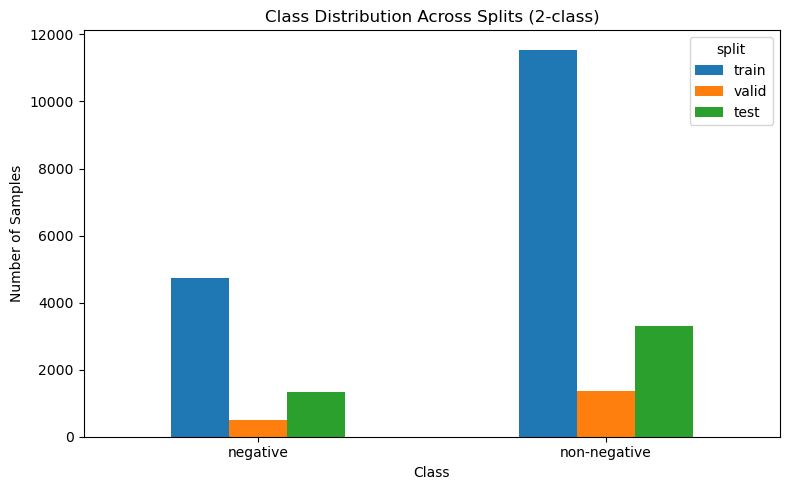

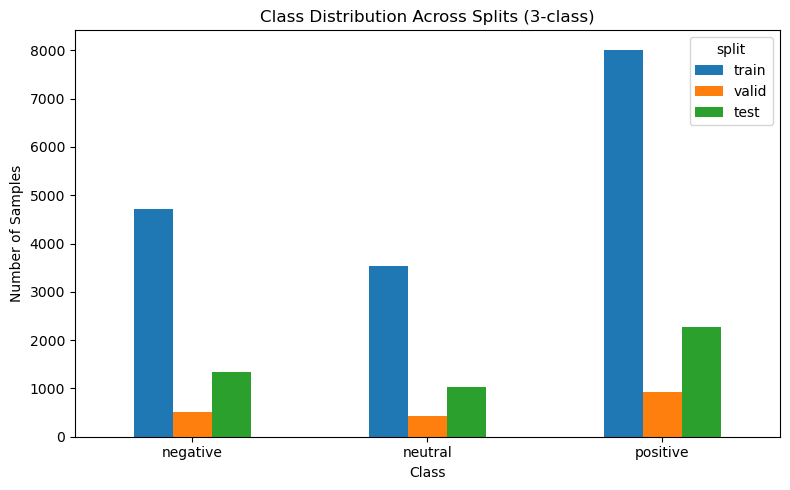

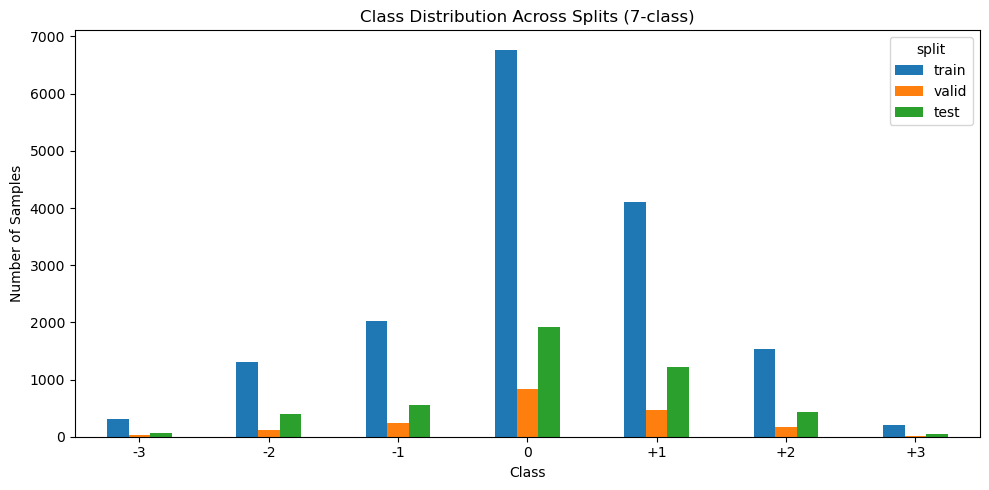

In [22]:
# ============================================================
# This cell plots class distributions across train, valid, and
# test splits for the 2-class, 3-class, and 7-class settings.
# ============================================================

def plot_label_distribution(df, class_order, title, figsize=(8, 5)):
    """
    Plot class distribution across dataset splits.
    """
    pivot_df = df.pivot(index="label_name", columns="split", values="count")
    pivot_df = pivot_df[["train", "valid", "test"]]
    pivot_df = pivot_df.loc[class_order]

    pivot_df.plot(kind="bar", figsize=figsize)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Number of Samples")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


plot_label_distribution(
    df_2class_table,
    ["negative", "non-negative"],
    "Class Distribution Across Splits (2-class)",
    figsize=(8, 5),
)

plot_label_distribution(
    df_3class_table,
    ["negative", "neutral", "positive"],
    "Class Distribution Across Splits (3-class)",
    figsize=(8, 5),
)

plot_label_distribution(
    df_7class_table,
    ["-3", "-2", "-1", "0", "+1", "+2", "+3"],
    "Class Distribution Across Splits (7-class)",
    figsize=(10, 5),
)

### 5.6 Sequence Length Summary

In [24]:
# ============================================================
# This cell summarises the fixed sequence length used for all
# modalities across the dataset splits.
# ============================================================

seq_len = TEXT_TR.shape[1]

df_length_summary = pd.DataFrame([
    {"split": "train", "modality": "text",   "sequence_length": TEXT_TR.shape[1]},
    {"split": "train", "modality": "audio",  "sequence_length": AUDIO_TR.shape[1]},
    {"split": "train", "modality": "vision", "sequence_length": VISION_TR.shape[1]},
    {"split": "valid", "modality": "text",   "sequence_length": TEXT_VA.shape[1]},
    {"split": "valid", "modality": "audio",  "sequence_length": AUDIO_VA.shape[1]},
    {"split": "valid", "modality": "vision", "sequence_length": VISION_VA.shape[1]},
    {"split": "test",  "modality": "text",   "sequence_length": TEXT_TE.shape[1]},
    {"split": "test",  "modality": "audio",  "sequence_length": AUDIO_TE.shape[1]},
    {"split": "test",  "modality": "vision", "sequence_length": VISION_TE.shape[1]},
])

print("=== Sequence Length Summary ===")
display(df_length_summary)

print(f"All modalities use a fixed sequence length of {seq_len} timesteps.")

=== Sequence Length Summary ===


,split,modality,sequence_length
0,train,text,50
1,train,audio,50
2,train,vision,50
3,valid,text,50
4,valid,audio,50
5,valid,vision,50
6,test,text,50
7,test,audio,50
8,test,vision,50


All modalities use a fixed sequence length of 50 timesteps.


### 5.7 Feature statistics after normalization

In [26]:
# ============================================================
# This cell reports basic statistics for each modality after
# z-score normalisation.
# ============================================================

def modality_stats(X, split_name, modality):
    """
    Compute basic statistics for one modality.
    """
    X = np.asarray(X)
    return {
        "split": split_name,
        "modality": modality,
        "mean": float(np.mean(X)),
        "std": float(np.std(X)),
        "min": float(np.min(X)),
        "max": float(np.max(X)),
    }

stats_rows = []
for split_name, t, a, v in [
    ("train", TEXT_TR, AUDIO_TR, VISION_TR),
    ("valid", TEXT_VA, AUDIO_VA, VISION_VA),
    ("test", TEXT_TE, AUDIO_TE, VISION_TE),
]:
    stats_rows.append(modality_stats(t, split_name, "text"))
    stats_rows.append(modality_stats(a, split_name, "audio"))
    stats_rows.append(modality_stats(v, split_name, "vision"))

df_modality_stats = pd.DataFrame(stats_rows)

print("=== Feature Statistics After Normalisation ===")
display(df_modality_stats.round(4))

=== Feature Statistics After Normalisation ===


,split,modality,mean,std,min,max
0,train,text,0.0000,1.0000,-11.6679,11.8031
1,train,audio,0.0000,1.0000,-90.7848,89.6994
2,train,vision,-0.0000,1.0000,-14.8908,14.7081
3,valid,text,0.0008,1.0172,-10.4270,11.5330
4,valid,audio,0.0021,0.9684,-65.3967,64.3967
5,valid,vision,-0.0176,0.9863,-10.5975,11.6928
6,test,text,0.0007,1.0071,-11.7171,14.4885
7,test,audio,-0.0013,0.9946,-73.8511,74.7350
8,test,vision,-0.0002,0.9891,-13.8461,17.9075


### 5.8 Label Distribution Across 2-, 3-, and 7-Class Settings

In [28]:
# ============================================================
# This cell compares label distributions under different
# classification schemes.
# ============================================================

def scheme_distribution(y_cont, scheme, split_name):
    """
    Create a label distribution table for one scheme and split.
    """
    y_raw = derive_labels(y_cont, scheme)
    y_ce = remap_labels_for_ce(y_raw, scheme)
    counts = pd.Series(y_ce).value_counts().sort_index()
    total = counts.sum()

    df = pd.DataFrame({
        "split": split_name,
        "scheme": f"{scheme}-class",
        "class_id": counts.index,
        "count": counts.values,
        "percentage": (counts.values / total * 100).round(2),
    })
    return df

df_scheme_dist = pd.concat([
    scheme_distribution(y_tr_cont, 2, "train"),
    scheme_distribution(y_va_cont, 2, "valid"),
    scheme_distribution(y_te_cont, 2, "test"),
    scheme_distribution(y_tr_cont, 3, "train"),
    scheme_distribution(y_va_cont, 3, "valid"),
    scheme_distribution(y_te_cont, 3, "test"),
    scheme_distribution(y_tr_cont, 7, "train"),
    scheme_distribution(y_va_cont, 7, "valid"),
    scheme_distribution(y_te_cont, 7, "test"),
], ignore_index=True)

print("=== Label Distribution Across Schemes ===")
display(df_scheme_dist)

=== Label Distribution Across Schemes ===


,split,scheme,class_id,count,percentage
0,train,2-class,0,4721,29.03
1,train,2-class,1,11544,70.97
2,valid,2-class,0,505,27.02
3,valid,2-class,1,1364,72.98
4,test,2-class,0,1345,28.97
5,test,2-class,1,3298,71.03
6,train,3-class,0,4721,29.03
7,train,3-class,1,3530,21.70
8,train,3-class,2,8014,49.27
9,valid,3-class,0,505,27.02


### 5.9 Percentage Distribution Across 2-, 3-, and 7-Class Schemes

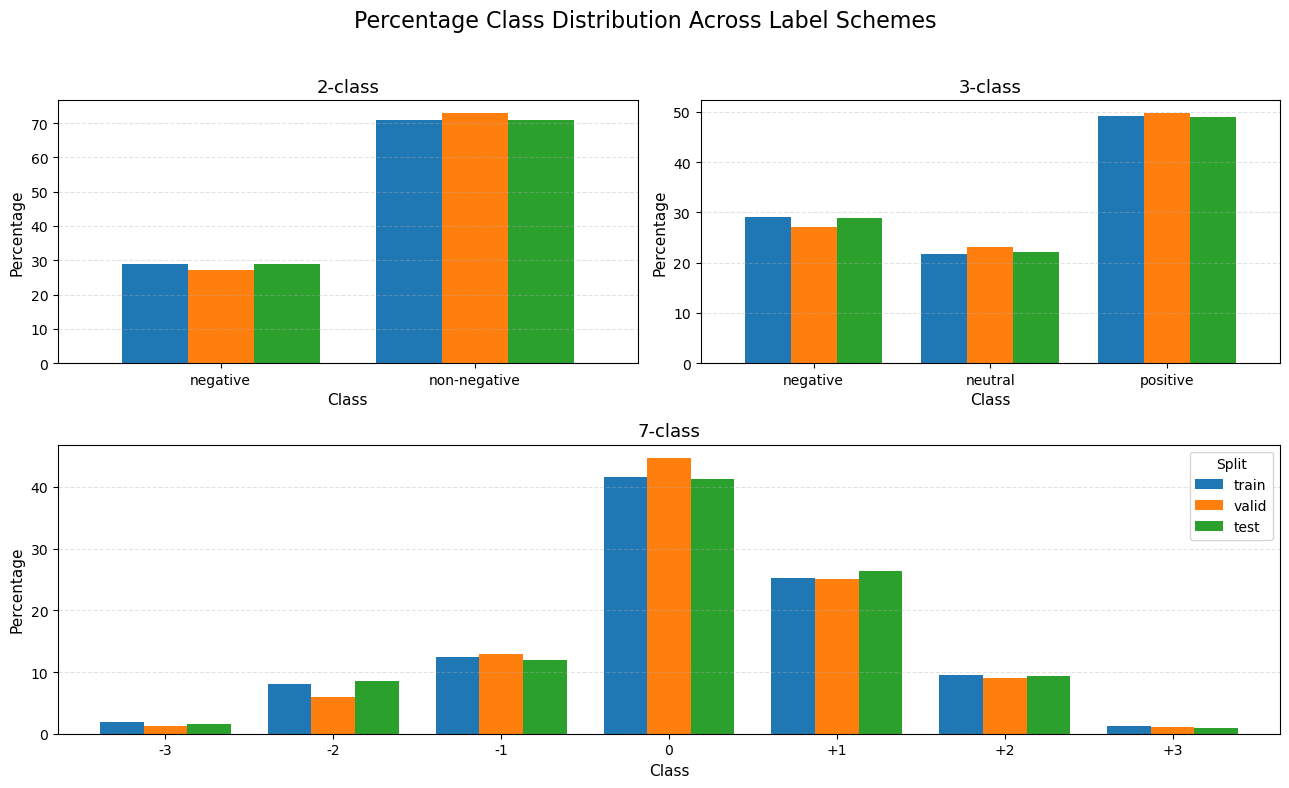

In [30]:
# ============================================================
# This cell plots percentage distributions in a two-row layout:
# 2-class and 3-class on the first row, and 7-class on the
# second row.
# ============================================================

scheme_order = ["2-class", "3-class", "7-class"]

label_maps = {
    "2-class": {0: "negative", 1: "non-negative"},
    "3-class": {0: "negative", 1: "neutral", 2: "positive"},
    "7-class": {0: "-3", 1: "-2", 2: "-1", 3: "0", 4: "+1", 5: "+2", 6: "+3"},
}

class_orders = {
    "2-class": ["negative", "non-negative"],
    "3-class": ["negative", "neutral", "positive"],
    "7-class": ["-3", "-2", "-1", "0", "+1", "+2", "+3"],
}

fig = plt.figure(figsize=(13, 8))
gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 1.1])

ax1 = fig.add_subplot(gs[0, 0])   # 2-class
ax2 = fig.add_subplot(gs[0, 1])   # 3-class
ax3 = fig.add_subplot(gs[1, :])   # 7-class spans full width

axes_map = {
    "2-class": ax1,
    "3-class": ax2,
    "7-class": ax3,
}

for scheme in scheme_order:
    ax = axes_map[scheme]

    temp = df_scheme_dist[df_scheme_dist["scheme"] == scheme].copy()
    temp["label_name"] = temp["class_id"].map(label_maps[scheme])

    pivot_temp = temp.pivot(index="label_name", columns="split", values="percentage")
    pivot_temp = pivot_temp[["train", "valid", "test"]]
    pivot_temp = pivot_temp.loc[class_orders[scheme]]

    pivot_temp.plot(kind="bar", ax=ax, width=0.78)

    ax.set_title(scheme, fontsize=13)
    ax.set_xlabel("Class", fontsize=11)
    ax.set_ylabel("Percentage", fontsize=11)
    ax.tick_params(axis="x", rotation=0, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.35)

    # keep legend only on the 7-class plot
    if scheme == "7-class":
        ax.legend(title="Split", fontsize=10, title_fontsize=10, loc="upper right")
    else:
        ax.get_legend().remove()

fig.suptitle("Percentage Class Distribution Across Label Schemes", fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 6. Final Model Definitions

This section defines the five final models used in the dissertation experiments:
- Text-only LSTM
- Text-only Transformer
- Early Fusion Transformer
- Late Fusion Transformer
- Hybrid Fusion Transformer

In [32]:
# ============================================================

class TextOnlyLSTM(nn.Module):
    """Text-only LSTM baseline model."""

    def __init__(
        self,
        input_dim,
        num_classes,
        hidden_dim=128,
        num_layers=2,
        dropout=0.3,
        bidirectional=False,
    ):
        super().__init__()

        lstm_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout,
            bidirectional=bidirectional,
        )

        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(out_dim, num_classes)

    def forward(self, t):
        """Forward pass."""
        x, _ = self.lstm(t)
        pooled = x.mean(dim=1)
        pooled = self.dropout(pooled)
        return self.fc(pooled)


class TextTransformer(nn.Module):
    """Text-only transformer model."""

    def __init__(
        self,
        text_dim,
        num_classes,
        d_model=128,
        nhead=4,
        num_layers=2,
        dropout=0.3,
        max_len=128,
    ):
        super().__init__()

        self.proj = nn.Linear(text_dim, d_model)
        self.pos = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 2,
            dropout=dropout,
            batch_first=True,
            activation="relu",
            norm_first=False,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, t):
        """Forward pass."""
        _, seq_len, _ = t.shape
        x = self.proj(t) + self.pos[:, :seq_len, :]
        x = self.encoder(x)
        pooled = 0.5 * (x.mean(dim=1) + x.amax(dim=1))
        pooled = self.norm(pooled)
        pooled = self.dropout(pooled)
        return self.head(pooled)


class EarlyFusionTransformer(nn.Module):
    """Early fusion transformer for multimodal input."""

    def __init__(
        self,
        dim_t,
        dim_a,
        dim_v,
        num_classes,
        d_model=256,
        nhead=8,
        num_layers=2,
        dropout=0.3,
        max_len=128,
    ):
        super().__init__()

        self.in_dim = dim_t + dim_a + dim_v
        self.proj = nn.Linear(self.in_dim, d_model)
        self.pos = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 2,
            dropout=dropout,
            batch_first=True,
            activation="relu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, t, a, v):
        """Forward pass."""
        x = torch.cat([t, a, v], dim=-1)
        _, seq_len, _ = x.shape
        x = self.proj(x) + self.pos[:, :seq_len, :]
        x = self.encoder(x)
        pooled = 0.5 * (x.mean(dim=1) + x.amax(dim=1))
        pooled = self.norm(pooled)
        pooled = self.dropout(pooled)
        return self.head(pooled)


class LateFusionTransformer(nn.Module):
    """Late fusion transformer with modality-specific encoders."""

    def __init__(
        self,
        dim_t,
        dim_a,
        dim_v,
        num_classes,
        d_model=256,
        nhead=8,
        num_layers=2,
        dropout=0.3,
        max_len=128,
    ):
        super().__init__()

        self.t_proj = nn.Linear(dim_t, d_model)
        self.a_proj = nn.Linear(dim_a, d_model)
        self.v_proj = nn.Linear(dim_v, d_model)

        self.pos_t = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)
        self.pos_a = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)
        self.pos_v = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)

        def make_encoder():
            enc_layer = nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=d_model * 2,
                dropout=dropout,
                batch_first=True,
                activation="relu",
                norm_first=True,
            )
            return nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.enc_t = make_encoder()
        self.enc_a = make_encoder()
        self.enc_v = make_encoder()

        self.norm_t = nn.LayerNorm(d_model)
        self.norm_a = nn.LayerNorm(d_model)
        self.norm_v = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        self.fuse_gate = nn.Sequential(
            nn.Linear(d_model * 3, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 3),
        )

        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    @staticmethod
    def _pool(x):
        """Apply mean and max pooling."""
        return 0.5 * (x.mean(dim=1) + x.amax(dim=1))

    def forward(self, t, a, v, return_gates=False):
        """Forward pass."""
        _, seq_len_t, _ = t.shape
        _, seq_len_a, _ = a.shape
        _, seq_len_v, _ = v.shape

        T = self.t_proj(t) + self.pos_t[:, :seq_len_t, :]
        A = self.a_proj(a) + self.pos_a[:, :seq_len_a, :]
        V = self.v_proj(v) + self.pos_v[:, :seq_len_v, :]

        T = self.enc_t(T)
        A = self.enc_a(A)
        V = self.enc_v(V)

        t_vec = self.norm_t(self._pool(T))
        a_vec = self.norm_a(self._pool(A))
        v_vec = self.norm_v(self._pool(V))

        cat = torch.cat([t_vec, a_vec, v_vec], dim=1)
        gate_logits = self.fuse_gate(cat)
        gates = F.softmax(gate_logits, dim=1)

        fused = (
            gates[:, 0:1] * t_vec
            + gates[:, 1:2] * a_vec
            + gates[:, 2:3] * v_vec
        )
        fused = self.dropout(fused)

        logits = self.head(fused)

        if return_gates:
            return logits, gates
        return logits


class _TransformerEncoderBlock(nn.Module):
    """Shared encoder block for a single modality."""

    def __init__(
        self,
        in_dim,
        d_model=256,
        nhead=8,
        num_layers=1,
        dropout=0.3,
        max_len=128,
    ):
        super().__init__()

        self.proj = nn.Linear(in_dim, d_model)
        self.pos = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 2,
            dropout=dropout,
            batch_first=True,
            activation="relu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        """Forward pass."""
        _, seq_len, _ = x.shape
        x = self.proj(x) + self.pos[:, :seq_len, :]
        x = self.encoder(x)

        pooled = 0.5 * (x.mean(dim=1) + x.amax(dim=1))
        pooled = self.norm(pooled)
        pooled = self.dropout(pooled)
        return pooled


class HybridFusionTransformer(nn.Module):
    """Hybrid fusion transformer combining early and late fusion."""

    def __init__(
        self,
        dim_t,
        dim_a,
        dim_v,
        num_classes,
        d_model=256,
        nhead=8,
        late_layers=1,
        early_layers=1,
        dropout=0.3,
        max_len=128,
    ):
        super().__init__()

        self.enc_t = _TransformerEncoderBlock(
            dim_t, d_model, nhead, late_layers, dropout, max_len
        )
        self.enc_a = _TransformerEncoderBlock(
            dim_a, d_model, nhead, late_layers, dropout, max_len
        )
        self.enc_v = _TransformerEncoderBlock(
            dim_v, d_model, nhead, late_layers, dropout, max_len
        )

        self.early_proj = nn.Linear(dim_t + dim_a + dim_v, d_model)
        self.pos = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 2,
            dropout=dropout,
            batch_first=True,
            activation="relu",
            norm_first=True,
        )
        self.early_encoder = nn.TransformerEncoder(enc_layer, num_layers=early_layers)

        self.fusion_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=dropout,
            batch_first=True,
        )
        self.norm_attn = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )
        self.norm_ff = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, t, a, v):
        """Forward pass."""
        t_vec = self.enc_t(t)
        a_vec = self.enc_a(a)
        v_vec = self.enc_v(v)

        late_tokens = torch.stack([t_vec, a_vec, v_vec], dim=1)

        x = torch.cat([t, a, v], dim=-1)
        _, seq_len, _ = x.shape
        x = self.early_proj(x) + self.pos[:, :seq_len, :]
        x = self.early_encoder(x)

        attn_out, _ = self.fusion_attn(
            query=x,
            key=late_tokens,
            value=late_tokens,
        )
        x = self.norm_attn(x + attn_out)

        ffn_out = self.ffn(x)
        x = self.norm_ff(x + ffn_out)

        pooled = 0.5 * (x.mean(dim=1) + x.amax(dim=1))
        pooled = self.dropout(pooled)
        return self.head(pooled)

## 7. Final Builder Functions

This section defines the final builder functions used to create the five dissertation models with the selected shared settings for the main experiments. Each builder returns one configured model instance using the current feature dimensions and number of classes.

In [3]:
# ============================================================
# 8. Final Model Builder Functions
# This cell defines the final model configurations used in the
# main experiments. The settings are kept consistent within the
# text-only and multimodal model groups to support fair comparison.
# ============================================================

def build_text_lstm_final():
    """Build the text-only LSTM baseline model."""
    return TextOnlyLSTM(
        input_dim=dim_t,
        num_classes=num_classes,
        hidden_dim=128,
        num_layers=2,
        dropout=0.3,
        bidirectional=False,
    )


def build_text_transformer_final():
    """Build the text-only transformer baseline model."""
    return TextTransformer(
        text_dim=dim_t,
        num_classes=num_classes,
        d_model=128,
        nhead=4,
        num_layers=2,
        dropout=0.3,
        max_len=128,
    )


def build_early_final():
    """Build the early fusion transformer model."""
    return EarlyFusionTransformer(
        dim_t=dim_t,
        dim_a=dim_a,
        dim_v=dim_v,
        num_classes=num_classes,
        d_model=192,
        nhead=6,
        num_layers=2,
        dropout=0.3,
        max_len=128,
    )


def build_late_final():
    """Build the late fusion transformer model."""
    return LateFusionTransformer(
        dim_t=dim_t,
        dim_a=dim_a,
        dim_v=dim_v,
        num_classes=num_classes,
        d_model=192,
        nhead=6,
        num_layers=2,
        dropout=0.3,
        max_len=128,
    )


def build_hybrid_final():
    """Build the hybrid fusion transformer model."""
    return HybridFusionTransformer(
        dim_t=dim_t,
        dim_a=dim_a,
        dim_v=dim_v,
        num_classes=num_classes,
        d_model=192,
        nhead=6,
        early_layers=2,
        late_layers=1,
        dropout=0.3,
        max_len=128,
    )


MODEL_BUILDERS = {
    "text_lstm": build_text_lstm_final,
    "text_transformer": build_text_transformer_final,
    "early": build_early_final,
    "late": build_late_final,
    "hybrid": build_hybrid_final,
}

## 8. Shared Training and Evaluation Utilities

This section defines the shared utilities used across the main experiments. It includes parameter counting, model-specific forward dispatch, one-epoch training, evaluation metrics, early stopping, and optional multi-seed experimentation.

In [36]:

def count_params(model):
    """Count trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def _get_logits(model, t, a, v):
    """Forward dispatch for all model types."""
    if isinstance(model, (TextOnlyLSTM, TextTransformer)):
        return model(t)

    if isinstance(model, (EarlyFusionTransformer, LateFusionTransformer, HybridFusionTransformer)):
        return model(t, a, v)

    raise TypeError(f"Unsupported model type: {type(model).__name__}")


def train_one_epoch(model, loader, optimizer, criterion, grad_clip=1.0):
    """Train for one epoch."""
    model.train()
    total_loss = 0.0

    for t, a, v, y in loader:
        t, a, v, y = t.to(device), a.to(device), v.to(device), y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = _get_logits(model, t, a, v)
        loss = criterion(logits, y)
        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()
        total_loss += loss.item() * y.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader):
    """Evaluate model and return metrics."""
    model.eval()
    y_true_all, y_pred_all = [], []

    for t, a, v, y in loader:
        t, a, v = t.to(device), a.to(device), v.to(device)

        logits = _get_logits(model, t, a, v)
        y_pred = torch.argmax(logits, dim=1).cpu().numpy()

        y_true_all.append(y.numpy())
        y_pred_all.append(y_pred)

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "per_class_f1": f1_score(y_true, y_pred, average=None, zero_division=0),
        "confusion": confusion_matrix(y_true, y_pred),
        "report": classification_report(y_true, y_pred, digits=4, zero_division=0),
    }


def fit_model(
    model,
    train_loader,
    valid_loader,
    epochs=30,
    lr=5e-5,
    weight_decay=1e-4,
    patience=10,
    use_class_weights=False,
    label_smoothing=0.0,
    select_metric="macro_f1",
    grad_clip=1.0,
    use_scheduler=True,
):
    """Train model with early stopping."""
    model = model.to(device)

    class_weight_tensor = None
    if use_class_weights and ("class_weights" in globals()) and class_weights is not None:
        class_weight_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)

    criterion = nn.CrossEntropyLoss(
        weight=class_weight_tensor,
        label_smoothing=label_smoothing,
    )
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = None
    if use_scheduler:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", factor=0.5, patience=3
        )

    best_score = -1.0
    best_state = None
    bad_epochs = 0
    epoch_times = []

    for ep in range(1, epochs + 1):
        start_time = time.time()

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, grad_clip)
        val_metrics = evaluate(model, valid_loader)
        score = val_metrics[select_metric]

        epoch_times.append(time.time() - start_time)

        if scheduler:
            scheduler.step(score)

        print(
            f"Epoch {ep:02d} | loss={train_loss:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_macroF1={val_metrics['macro_f1']:.4f}"
        )

        if score > best_score:
            best_score = score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Early stopping ({select_metric}, patience={patience})")
                break

    if best_state:
        model.load_state_dict(best_state)

    mean_epoch_time = float(np.mean(epoch_times)) if epoch_times else float("nan")
    return model, mean_epoch_time


def run_multiseed(
    model_name,
    build_fn,
    seeds=(42,),
    epochs=30,
    lr=5e-5,
    weight_decay=1e-4,
    use_class_weights=False,
    patience=10,
    grad_clip=1.0,
    use_scheduler=True,
    label_smoothing=0.0,
    select_metric="macro_f1",
):
    """Run experiments across multiple seeds."""
    rows = []

    for seed in seeds:
        print("\n" + "=" * 60)
        print(f"{model_name} | seed={seed}")
        set_seed(seed)

        model = build_fn()
        params = count_params(model)

        trained_model, mean_epoch_time = fit_model(
            model,
            train_loader,
            valid_loader,
            epochs,
            lr,
            weight_decay,
            patience,
            use_class_weights,
            label_smoothing,
            select_metric,
            grad_clip,
            use_scheduler,
        )

        val_metrics = evaluate(trained_model, valid_loader)
        test_metrics = evaluate(trained_model, test_loader)

        rows.append(
            {
                "model": model_name,
                "seed": seed,
                "params": params,
                "mean_epoch_time_sec": mean_epoch_time,
                "val_accuracy": val_metrics["accuracy"],
                "val_balanced_accuracy": val_metrics["balanced_accuracy"],
                "val_precision": val_metrics["precision"],
                "val_recall": val_metrics["recall"],
                "val_f1": val_metrics["f1"],
                "val_macro_f1": val_metrics["macro_f1"],
                "test_accuracy": test_metrics["accuracy"],
                "test_balanced_accuracy": test_metrics["balanced_accuracy"],
                "test_precision": test_metrics["precision"],
                "test_recall": test_metrics["recall"],
                "test_f1": test_metrics["f1"],
                "test_macro_f1": test_metrics["macro_f1"],
            }
        )

    df_runs = pd.DataFrame(rows)
    summary = df_runs.groupby("model").agg(["mean", "std"])
    return df_runs, summary

## 9. Main Five-Model Comparison Experiment

This cell runs the main fair-comparison experiment across the five final models using the same training configuration. It supports 2-class, 3-class, and 7-class settings, records validation and test performance, saves plots and confusion matrices, and exports the final summary results.

Models to run: ['text_lstm', 'text_transformer', 'early', 'late', 'hybrid']

=== Running Final Model Comparison (2-class) ===

=== Running mode: TEXT_LSTM ===
[TEXT_LSTM] Ep 01 | TR acc 0.705 f1 0.824 | VA acc 0.748 f1 0.851 | TE acc 0.726 f1 0.837
[TEXT_LSTM] Ep 02 | TR acc 0.755 f1 0.847 | VA acc 0.774 f1 0.858 | TE acc 0.770 f1 0.855
[TEXT_LSTM] Ep 03 | TR acc 0.773 f1 0.854 | VA acc 0.779 f1 0.859 | TE acc 0.773 f1 0.854
[TEXT_LSTM] Ep 04 | TR acc 0.782 f1 0.859 | VA acc 0.791 f1 0.867 | TE acc 0.778 f1 0.857
[TEXT_LSTM] Ep 05 | TR acc 0.792 f1 0.864 | VA acc 0.787 f1 0.868 | TE acc 0.777 f1 0.860
[TEXT_LSTM] Ep 06 | TR acc 0.798 f1 0.868 | VA acc 0.788 f1 0.862 | TE acc 0.784 f1 0.858
[TEXT_LSTM] Ep 07 | TR acc 0.806 f1 0.872 | VA acc 0.795 f1 0.867 | TE acc 0.790 f1 0.861
[TEXT_LSTM] Ep 08 | TR acc 0.813 f1 0.876 | VA acc 0.790 f1 0.866 | TE acc 0.785 f1 0.862
[TEXT_LSTM] Ep 09 | TR acc 0.821 f1 0.881 | VA acc 0.796 f1 0.865 | TE acc 0.793 f1 0.860
[TEXT_LSTM] Ep 10 | TR acc 0.83

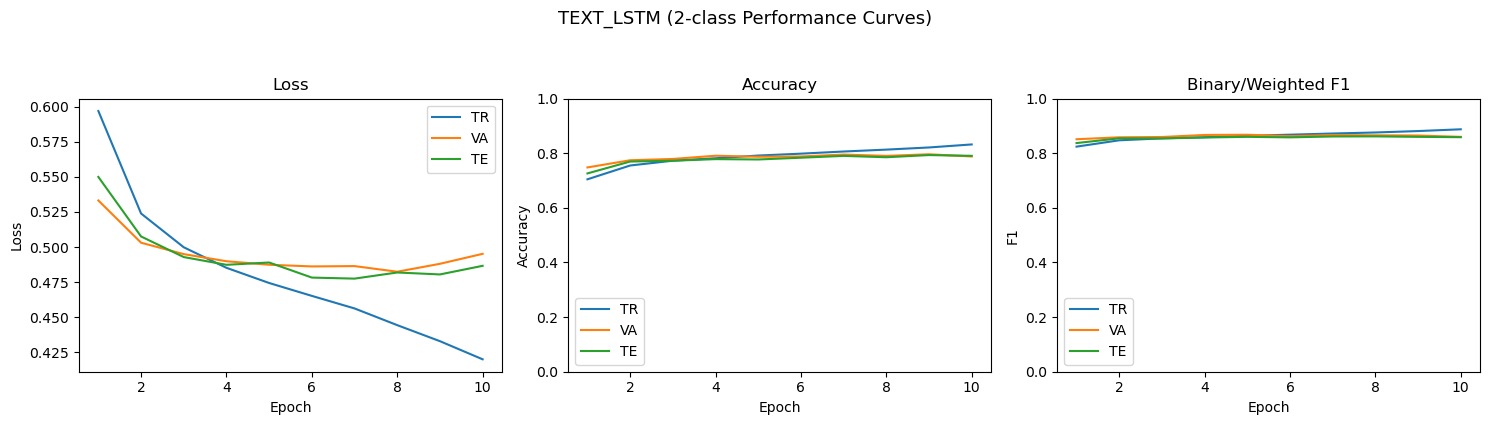

Saved: plots/curves_text_lstm_2class.png
Saved: plots/cm_text_lstm_test_2class.png


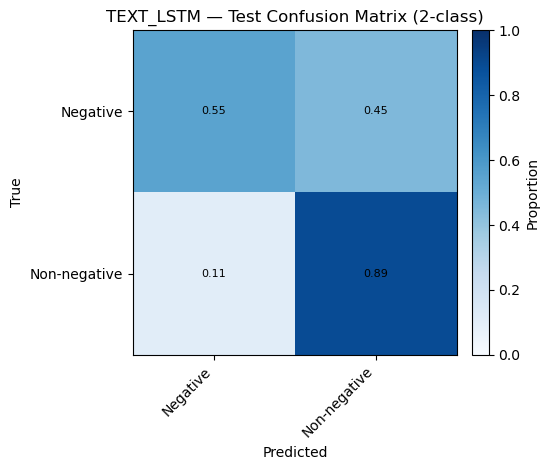


=== Running mode: TEXT_TRANS ===
[TEXT_TRANS] Ep 01 | TR acc 0.750 f1 0.840 | VA acc 0.789 f1 0.868 | TE acc 0.781 f1 0.861
[TEXT_TRANS] Ep 02 | TR acc 0.782 f1 0.854 | VA acc 0.796 f1 0.866 | TE acc 0.797 f1 0.866
[TEXT_TRANS] Ep 03 | TR acc 0.796 f1 0.863 | VA acc 0.798 f1 0.867 | TE acc 0.800 f1 0.867
[TEXT_TRANS] Ep 04 | TR acc 0.804 f1 0.868 | VA acc 0.805 f1 0.874 | TE acc 0.800 f1 0.869
[TEXT_TRANS] Ep 05 | TR acc 0.808 f1 0.870 | VA acc 0.803 f1 0.870 | TE acc 0.801 f1 0.867
[TEXT_TRANS] Ep 06 | TR acc 0.813 f1 0.873 | VA acc 0.805 f1 0.871 | TE acc 0.803 f1 0.867
[TEXT_TRANS] Ep 07 | TR acc 0.814 f1 0.875 | VA acc 0.807 f1 0.871 | TE acc 0.802 f1 0.866
[TEXT_TRANS] Ep 08 | TR acc 0.819 f1 0.878 | VA acc 0.810 f1 0.874 | TE acc 0.803 f1 0.867
[TEXT_TRANS] Ep 09 | TR acc 0.824 f1 0.881 | VA acc 0.805 f1 0.869 | TE acc 0.808 f1 0.868
[TEXT_TRANS] Ep 10 | TR acc 0.826 f1 0.883 | VA acc 0.802 f1 0.867 | TE acc 0.804 f1 0.866
[TEXT_TRANS] BEST@Ep08 | VAL acc 0.810 precision 0.848 r

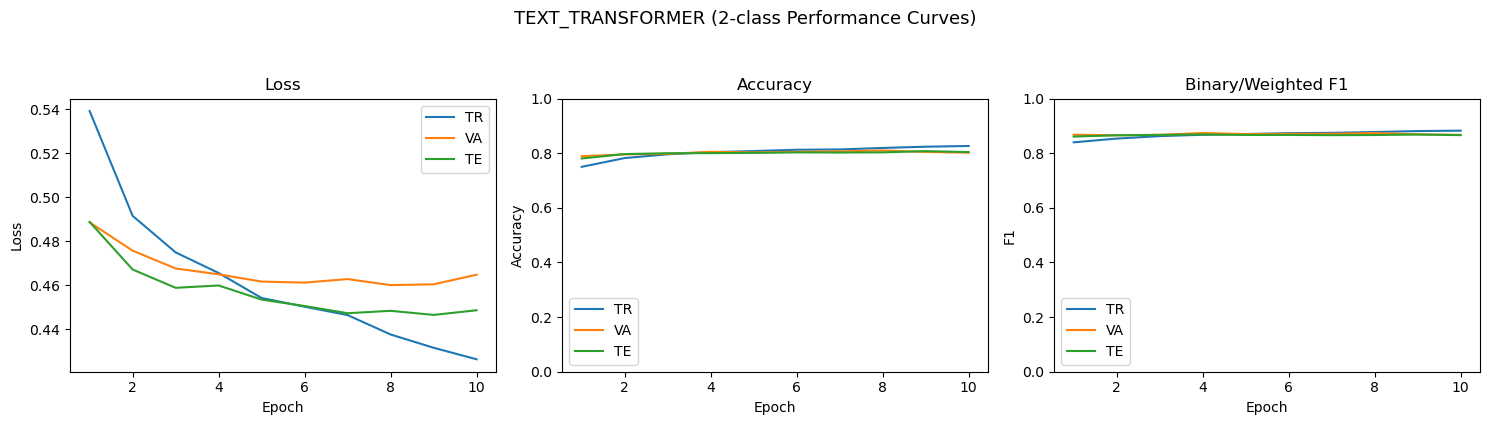

Saved: plots/curves_text_transformer_2class.png
Saved: plots/cm_text_transformer_test_2class.png


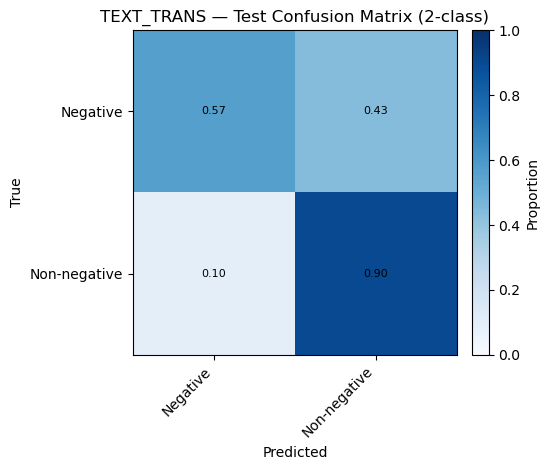


=== Running mode: EARLY ===
[EARLY] Ep 01 | TR acc 0.763 f1 0.845 | VA acc 0.792 f1 0.862 | TE acc 0.798 f1 0.863
[EARLY] Ep 02 | TR acc 0.806 f1 0.869 | VA acc 0.808 f1 0.876 | TE acc 0.798 f1 0.868
[EARLY] Ep 03 | TR acc 0.816 f1 0.876 | VA acc 0.802 f1 0.866 | TE acc 0.799 f1 0.861
[EARLY] Ep 04 | TR acc 0.823 f1 0.880 | VA acc 0.813 f1 0.878 | TE acc 0.807 f1 0.872
[EARLY] Ep 05 | TR acc 0.835 f1 0.888 | VA acc 0.804 f1 0.869 | TE acc 0.803 f1 0.867
[EARLY] Ep 06 | TR acc 0.841 f1 0.892 | VA acc 0.799 f1 0.862 | TE acc 0.800 f1 0.861
[EARLY] Ep 07 | TR acc 0.846 f1 0.895 | VA acc 0.809 f1 0.871 | TE acc 0.804 f1 0.865
[EARLY] Ep 08 | TR acc 0.858 f1 0.903 | VA acc 0.799 f1 0.865 | TE acc 0.807 f1 0.869
[EARLY] Ep 09 | TR acc 0.868 f1 0.909 | VA acc 0.801 f1 0.866 | TE acc 0.799 f1 0.862
[EARLY] Ep 10 | TR acc 0.875 f1 0.914 | VA acc 0.804 f1 0.869 | TE acc 0.808 f1 0.870
[EARLY] BEST@Ep07 | VAL acc 0.809 precision 0.860 recall 0.882 f1 0.871 macroF1 0.752 | TEST acc 0.804 precisio

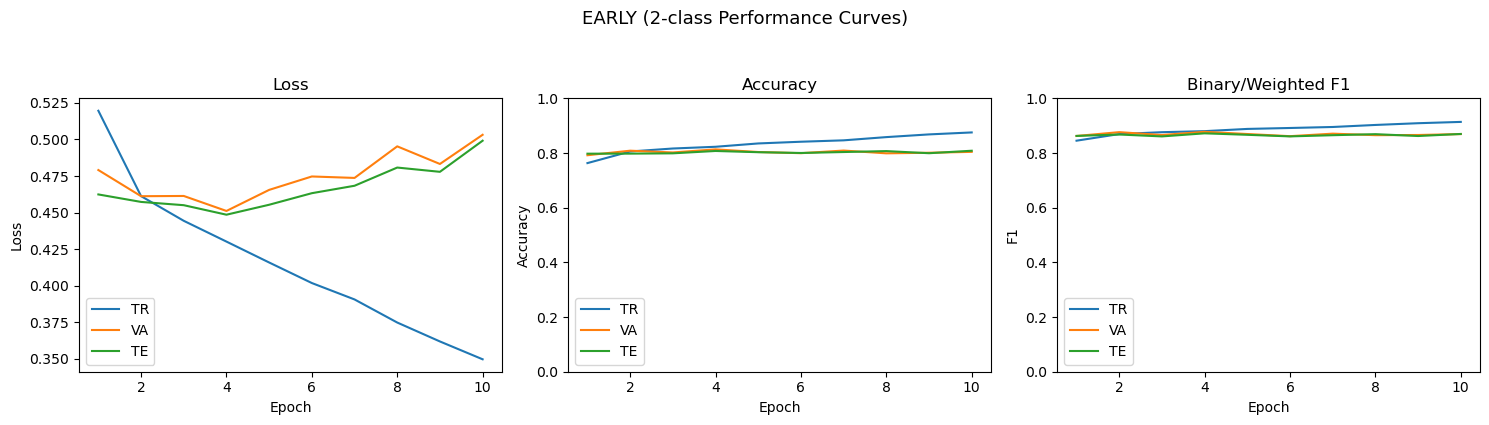

Saved: plots/curves_early_2class.png
Saved: plots/cm_early_test_2class.png


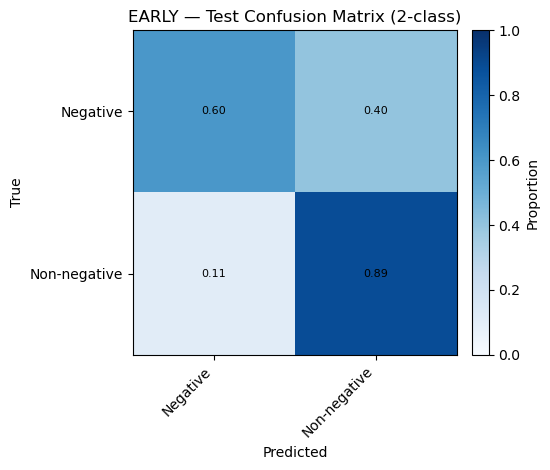


=== Running mode: LATE ===
[LATE] Ep 01 | TR acc 0.773 f1 0.851 | VA acc 0.808 f1 0.875 | TE acc 0.794 f1 0.864
[LATE] Ep 02 | TR acc 0.810 f1 0.872 | VA acc 0.808 f1 0.875 | TE acc 0.804 f1 0.870
[LATE] Ep 03 | TR acc 0.821 f1 0.879 | VA acc 0.810 f1 0.880 | TE acc 0.797 f1 0.869
[LATE] Ep 04 | TR acc 0.830 f1 0.885 | VA acc 0.813 f1 0.878 | TE acc 0.805 f1 0.871
[LATE] Ep 05 | TR acc 0.839 f1 0.891 | VA acc 0.812 f1 0.877 | TE acc 0.802 f1 0.869
[LATE] Ep 06 | TR acc 0.849 f1 0.897 | VA acc 0.800 f1 0.864 | TE acc 0.803 f1 0.865
[LATE] Ep 07 | TR acc 0.857 f1 0.902 | VA acc 0.795 f1 0.859 | TE acc 0.792 f1 0.855
[LATE] Ep 08 | TR acc 0.862 f1 0.906 | VA acc 0.796 f1 0.861 | TE acc 0.800 f1 0.862
[LATE] Ep 09 | TR acc 0.874 f1 0.913 | VA acc 0.801 f1 0.870 | TE acc 0.800 f1 0.866
[LATE] Ep 10 | TR acc 0.896 f1 0.928 | VA acc 0.787 f1 0.855 | TE acc 0.794 f1 0.857
[LATE] BEST@Ep06 | VAL acc 0.800 precision 0.856 recall 0.873 f1 0.864 macroF1 0.742 | TEST acc 0.803 precision 0.846 reca

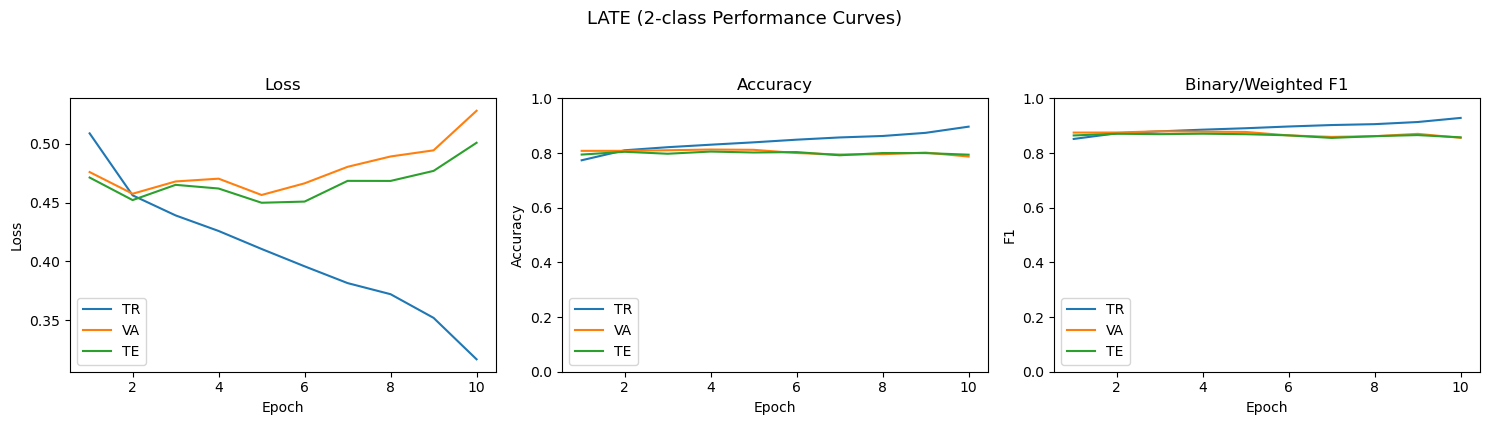

Saved: plots/curves_late_2class.png
Saved: plots/cm_late_test_2class.png


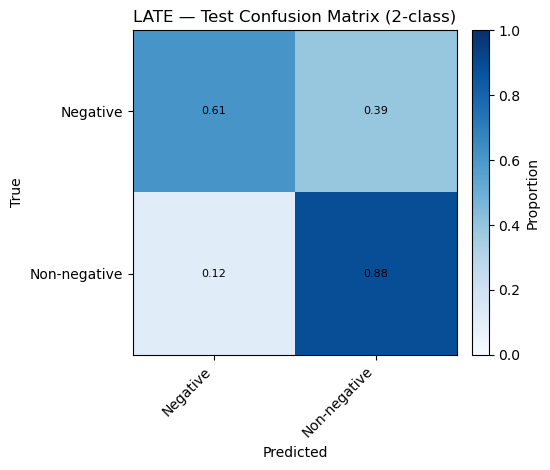


=== Running mode: HYBRID ===
[HYBRID] Ep 01 | TR acc 0.769 f1 0.850 | VA acc 0.801 f1 0.866 | TE acc 0.799 f1 0.862
[HYBRID] Ep 02 | TR acc 0.811 f1 0.872 | VA acc 0.812 f1 0.875 | TE acc 0.809 f1 0.871
[HYBRID] Ep 03 | TR acc 0.829 f1 0.884 | VA acc 0.815 f1 0.881 | TE acc 0.805 f1 0.872
[HYBRID] Ep 04 | TR acc 0.839 f1 0.890 | VA acc 0.813 f1 0.882 | TE acc 0.798 f1 0.869
[HYBRID] Ep 05 | TR acc 0.852 f1 0.899 | VA acc 0.798 f1 0.863 | TE acc 0.799 f1 0.861
[HYBRID] Ep 06 | TR acc 0.873 f1 0.913 | VA acc 0.796 f1 0.862 | TE acc 0.801 f1 0.863
[HYBRID] Ep 07 | TR acc 0.884 f1 0.920 | VA acc 0.788 f1 0.854 | TE acc 0.795 f1 0.856
Early stopping at epoch 7 (best=2)
[HYBRID] BEST@Ep02 | VAL acc 0.812 precision 0.848 recall 0.905 f1 0.875 macroF1 0.747 | TEST acc 0.809 precision 0.838 recall 0.906 f1 0.871 macroF1 0.753


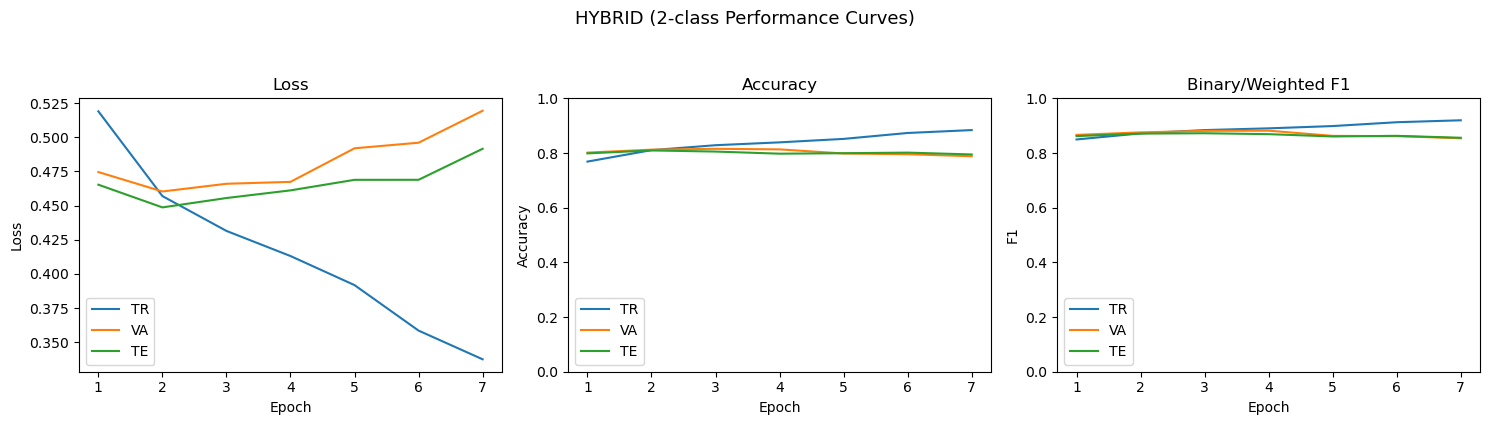

Saved: plots/curves_hybrid_2class.png
Saved: plots/cm_hybrid_test_2class.png


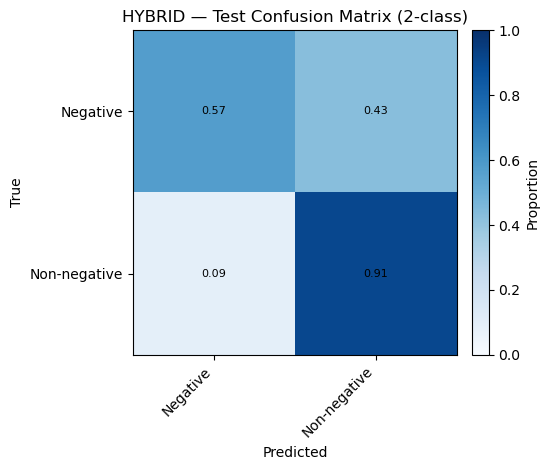

Finished 2-class setting.
Saved: all_results_5models_2class.pkl
Saved: results_5models_summary_2class.csv

=== Running Final Model Comparison (3-class) ===

=== Running mode: TEXT_LSTM ===
[TEXT_LSTM] Ep 01 | TR acc 0.516 f1 0.388 | VA acc 0.558 f1 0.470 | TE acc 0.574 f1 0.490
[TEXT_LSTM] Ep 02 | TR acc 0.584 f1 0.505 | VA acc 0.585 f1 0.503 | TE acc 0.595 f1 0.516
[TEXT_LSTM] Ep 03 | TR acc 0.603 f1 0.525 | VA acc 0.590 f1 0.506 | TE acc 0.600 f1 0.518
[TEXT_LSTM] Ep 04 | TR acc 0.614 f1 0.540 | VA acc 0.591 f1 0.512 | TE acc 0.612 f1 0.536
[TEXT_LSTM] Ep 05 | TR acc 0.627 f1 0.558 | VA acc 0.600 f1 0.530 | TE acc 0.620 f1 0.553
[TEXT_LSTM] Ep 06 | TR acc 0.634 f1 0.572 | VA acc 0.598 f1 0.532 | TE acc 0.624 f1 0.563
[TEXT_LSTM] Ep 07 | TR acc 0.646 f1 0.589 | VA acc 0.605 f1 0.543 | TE acc 0.625 f1 0.569
[TEXT_LSTM] Ep 08 | TR acc 0.653 f1 0.602 | VA acc 0.605 f1 0.554 | TE acc 0.632 f1 0.586
[TEXT_LSTM] Ep 09 | TR acc 0.666 f1 0.622 | VA acc 0.608 f1 0.560 | TE acc 0.630 f1 0.585
[

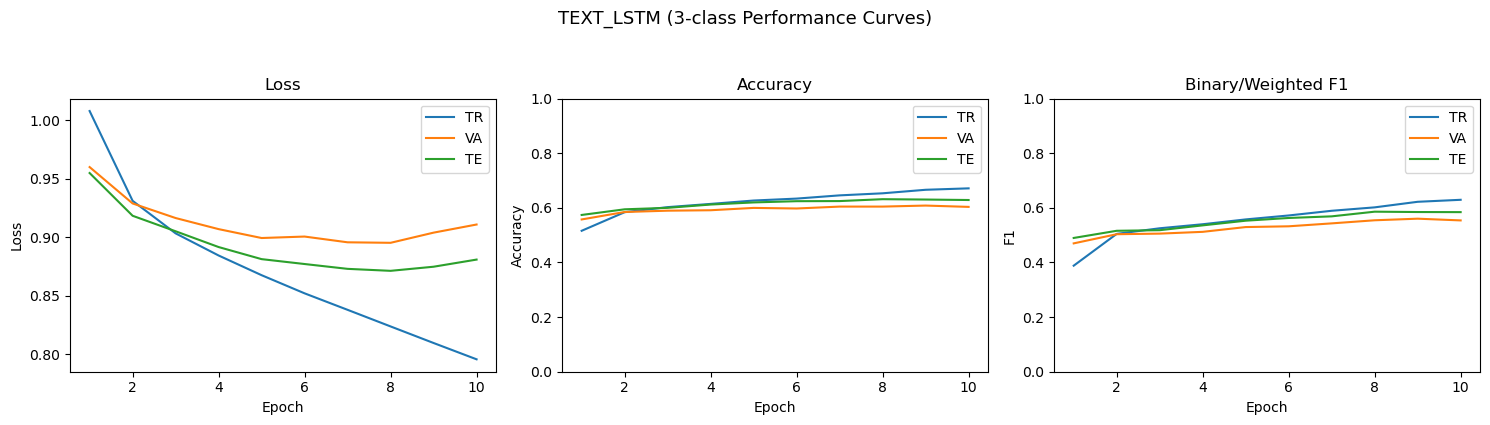

Saved: plots/curves_text_lstm_3class.png
Saved: plots/cm_text_lstm_test_3class.png


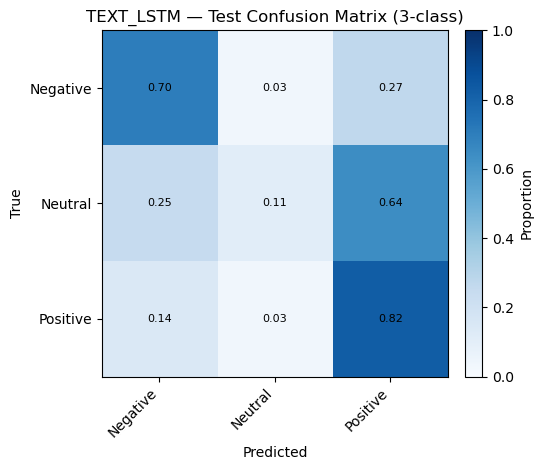


=== Running mode: TEXT_TRANS ===
[TEXT_TRANS] Ep 01 | TR acc 0.549 f1 0.487 | VA acc 0.597 f1 0.543 | TE acc 0.618 f1 0.563
[TEXT_TRANS] Ep 02 | TR acc 0.610 f1 0.566 | VA acc 0.600 f1 0.559 | TE acc 0.628 f1 0.589
[TEXT_TRANS] Ep 03 | TR acc 0.626 f1 0.592 | VA acc 0.599 f1 0.564 | TE acc 0.633 f1 0.604
[TEXT_TRANS] Ep 04 | TR acc 0.638 f1 0.610 | VA acc 0.614 f1 0.577 | TE acc 0.635 f1 0.596
[TEXT_TRANS] Ep 05 | TR acc 0.644 f1 0.619 | VA acc 0.604 f1 0.590 | TE acc 0.636 f1 0.623
[TEXT_TRANS] Ep 06 | TR acc 0.649 f1 0.629 | VA acc 0.620 f1 0.584 | TE acc 0.637 f1 0.602
[TEXT_TRANS] Ep 07 | TR acc 0.657 f1 0.636 | VA acc 0.608 f1 0.583 | TE acc 0.639 f1 0.616
[TEXT_TRANS] Ep 08 | TR acc 0.659 f1 0.639 | VA acc 0.622 f1 0.594 | TE acc 0.642 f1 0.618
[TEXT_TRANS] Ep 09 | TR acc 0.669 f1 0.651 | VA acc 0.621 f1 0.592 | TE acc 0.646 f1 0.621
[TEXT_TRANS] Ep 10 | TR acc 0.671 f1 0.651 | VA acc 0.621 f1 0.592 | TE acc 0.645 f1 0.619
Early stopping at epoch 10 (best=5)
[TEXT_TRANS] BEST@Ep

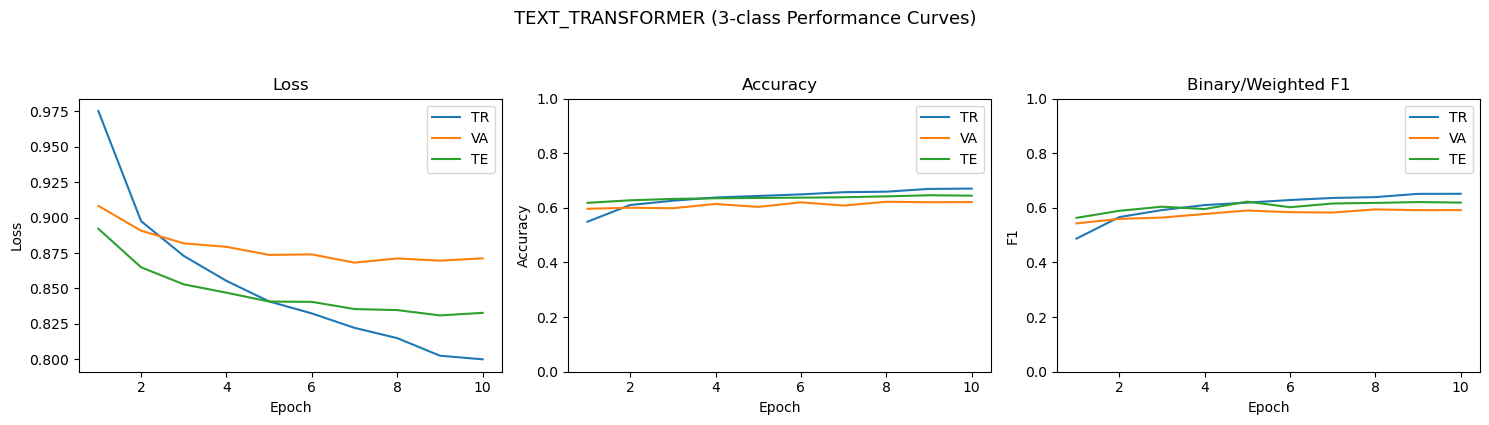

Saved: plots/curves_text_transformer_3class.png
Saved: plots/cm_text_transformer_test_3class.png


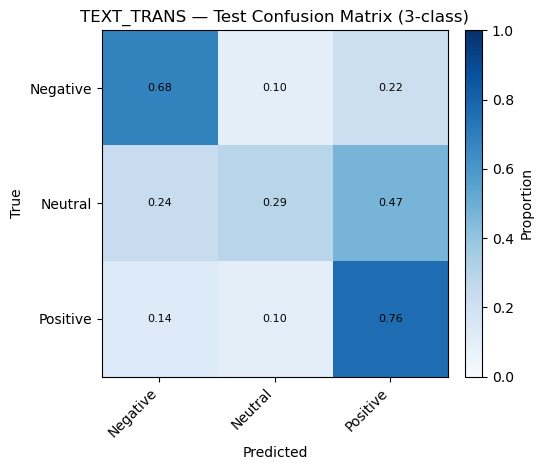


=== Running mode: EARLY ===
[EARLY] Ep 01 | TR acc 0.582 f1 0.542 | VA acc 0.587 f1 0.572 | TE acc 0.622 f1 0.602
[EARLY] Ep 02 | TR acc 0.642 f1 0.622 | VA acc 0.618 f1 0.607 | TE acc 0.639 f1 0.626
[EARLY] Ep 03 | TR acc 0.660 f1 0.643 | VA acc 0.628 f1 0.612 | TE acc 0.648 f1 0.631
[EARLY] Ep 04 | TR acc 0.675 f1 0.660 | VA acc 0.618 f1 0.607 | TE acc 0.639 f1 0.626
[EARLY] Ep 05 | TR acc 0.682 f1 0.669 | VA acc 0.627 f1 0.588 | TE acc 0.640 f1 0.602
[EARLY] Ep 06 | TR acc 0.697 f1 0.686 | VA acc 0.624 f1 0.609 | TE acc 0.647 f1 0.630
[EARLY] Ep 07 | TR acc 0.717 f1 0.708 | VA acc 0.615 f1 0.591 | TE acc 0.639 f1 0.615
[EARLY] Ep 08 | TR acc 0.732 f1 0.724 | VA acc 0.613 f1 0.602 | TE acc 0.635 f1 0.622
Early stopping at epoch 8 (best=3)
[EARLY] BEST@Ep03 | VAL acc 0.628 precision 0.611 recall 0.572 f1 0.612 macroF1 0.570 | TEST acc 0.648 precision 0.630 recall 0.585 f1 0.631 macroF1 0.585


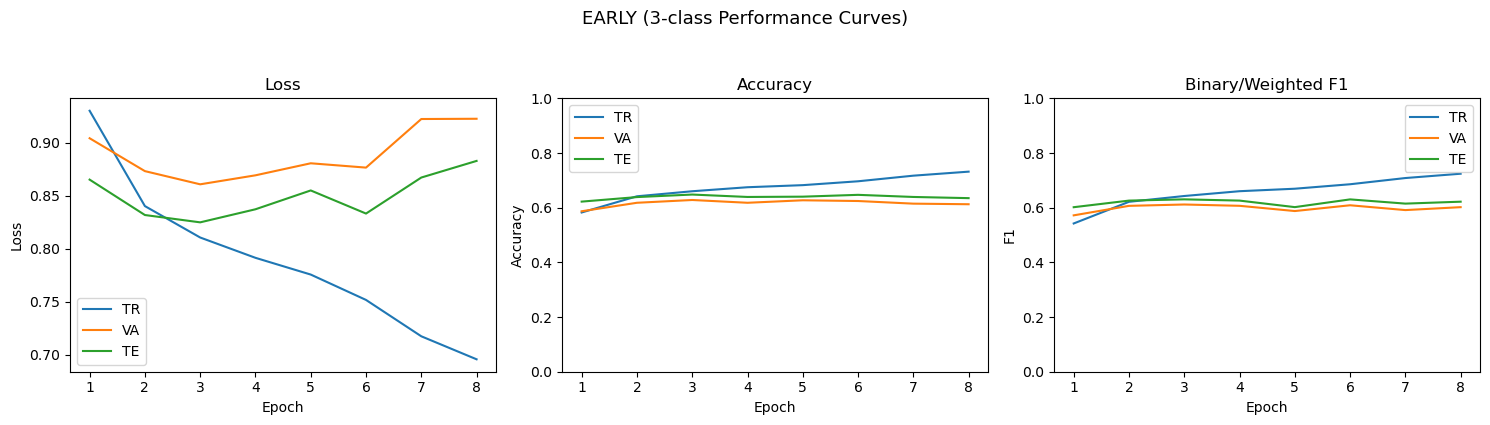

Saved: plots/curves_early_3class.png
Saved: plots/cm_early_test_3class.png


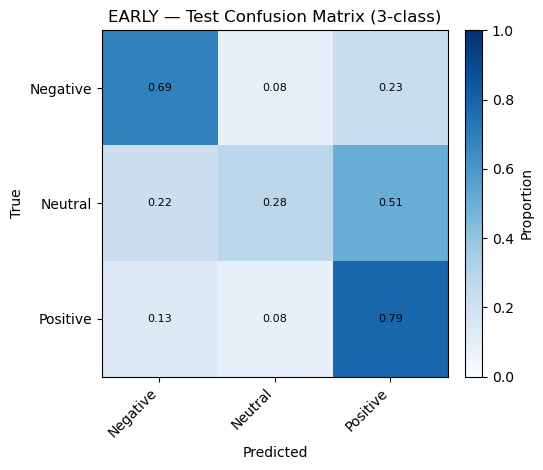


=== Running mode: LATE ===
[LATE] Ep 01 | TR acc 0.591 f1 0.548 | VA acc 0.621 f1 0.611 | TE acc 0.632 f1 0.620
[LATE] Ep 02 | TR acc 0.646 f1 0.624 | VA acc 0.624 f1 0.595 | TE acc 0.647 f1 0.617
[LATE] Ep 03 | TR acc 0.663 f1 0.647 | VA acc 0.624 f1 0.605 | TE acc 0.652 f1 0.630
[LATE] Ep 04 | TR acc 0.677 f1 0.662 | VA acc 0.625 f1 0.606 | TE acc 0.652 f1 0.633
[LATE] Ep 05 | TR acc 0.697 f1 0.685 | VA acc 0.623 f1 0.607 | TE acc 0.650 f1 0.632
[LATE] Ep 06 | TR acc 0.710 f1 0.700 | VA acc 0.622 f1 0.606 | TE acc 0.647 f1 0.629
Early stopping at epoch 6 (best=1)
[LATE] BEST@Ep01 | VAL acc 0.621 precision 0.607 recall 0.570 f1 0.611 macroF1 0.570 | TEST acc 0.632 precision 0.616 recall 0.571 f1 0.620 macroF1 0.573


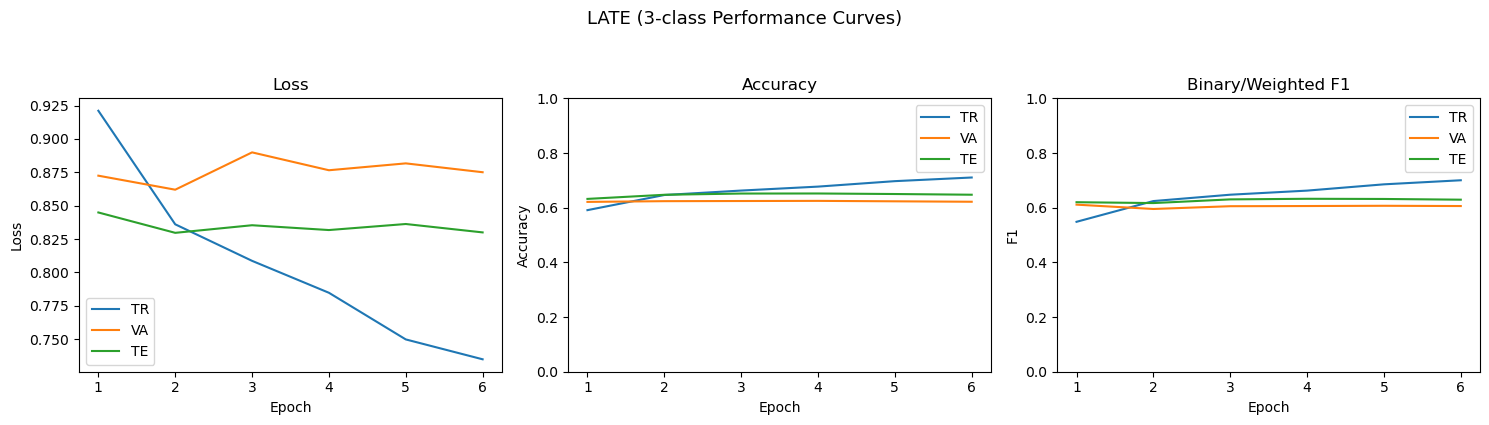

Saved: plots/curves_late_3class.png
Saved: plots/cm_late_test_3class.png


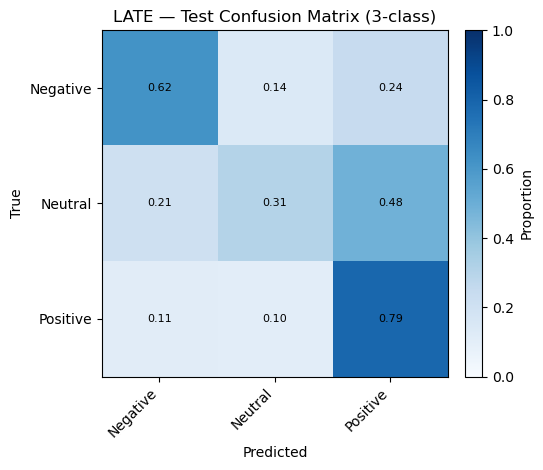


=== Running mode: HYBRID ===
[HYBRID] Ep 01 | TR acc 0.587 f1 0.547 | VA acc 0.614 f1 0.588 | TE acc 0.640 f1 0.610
[HYBRID] Ep 02 | TR acc 0.650 f1 0.631 | VA acc 0.623 f1 0.598 | TE acc 0.648 f1 0.618
[HYBRID] Ep 03 | TR acc 0.669 f1 0.654 | VA acc 0.631 f1 0.614 | TE acc 0.654 f1 0.632
[HYBRID] Ep 04 | TR acc 0.687 f1 0.675 | VA acc 0.630 f1 0.596 | TE acc 0.649 f1 0.617
[HYBRID] Ep 05 | TR acc 0.703 f1 0.693 | VA acc 0.612 f1 0.589 | TE acc 0.652 f1 0.631
[HYBRID] Ep 06 | TR acc 0.722 f1 0.713 | VA acc 0.608 f1 0.600 | TE acc 0.638 f1 0.626
[HYBRID] Ep 07 | TR acc 0.750 f1 0.745 | VA acc 0.620 f1 0.610 | TE acc 0.650 f1 0.637
[HYBRID] Ep 08 | TR acc 0.770 f1 0.766 | VA acc 0.627 f1 0.614 | TE acc 0.645 f1 0.630
Early stopping at epoch 8 (best=3)
[HYBRID] BEST@Ep03 | VAL acc 0.631 precision 0.613 recall 0.575 f1 0.614 macroF1 0.571 | TEST acc 0.654 precision 0.636 recall 0.586 f1 0.632 macroF1 0.583


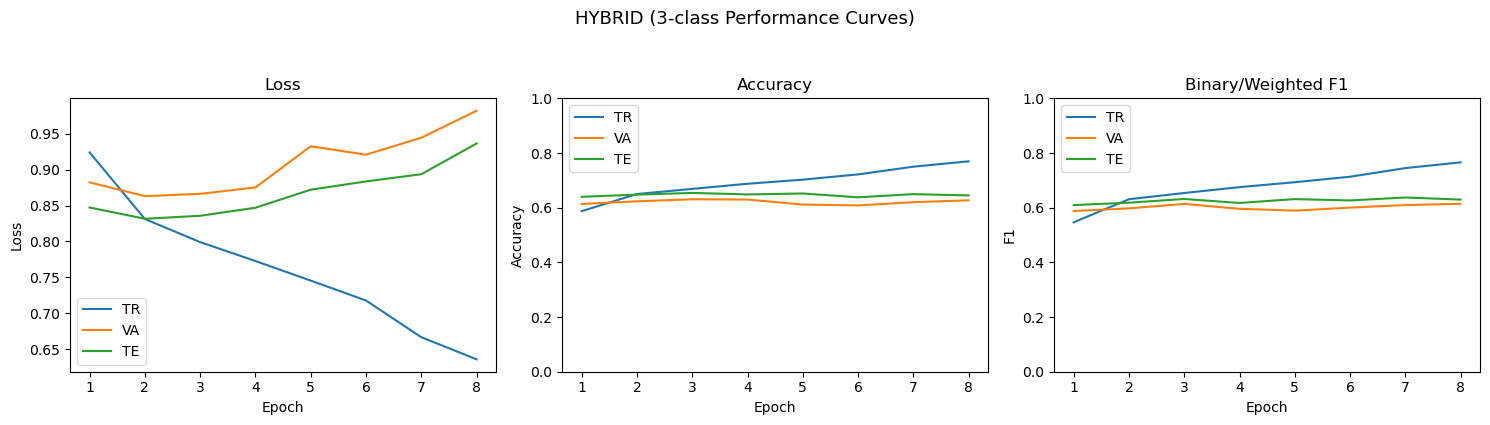

Saved: plots/curves_hybrid_3class.png
Saved: plots/cm_hybrid_test_3class.png


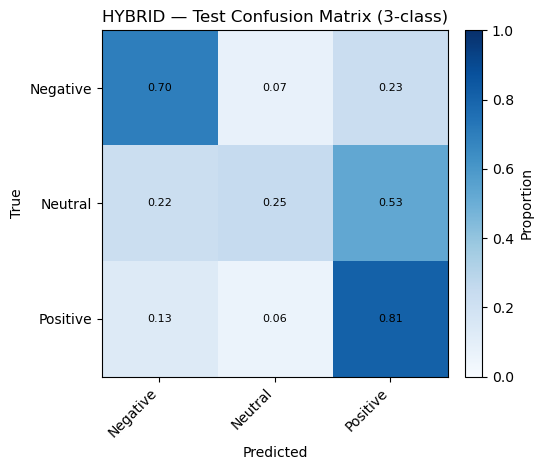

Finished 3-class setting.
Saved: all_results_5models_3class.pkl
Saved: results_5models_summary_3class.csv

=== Running Final Model Comparison (7-class) ===

=== Running mode: TEXT_LSTM ===
[TEXT_LSTM] Ep 01 | TR acc 0.405 f1 0.279 | VA acc 0.446 f1 0.287 | TE acc 0.417 f1 0.256
[TEXT_LSTM] Ep 02 | TR acc 0.421 f1 0.288 | VA acc 0.452 f1 0.313 | TE acc 0.418 f1 0.276
[TEXT_LSTM] Ep 03 | TR acc 0.433 f1 0.322 | VA acc 0.455 f1 0.330 | TE acc 0.429 f1 0.308
[TEXT_LSTM] Ep 04 | TR acc 0.442 f1 0.343 | VA acc 0.477 f1 0.400 | TE acc 0.445 f1 0.367
[TEXT_LSTM] Ep 05 | TR acc 0.450 f1 0.362 | VA acc 0.471 f1 0.381 | TE acc 0.445 f1 0.354
[TEXT_LSTM] Ep 06 | TR acc 0.456 f1 0.375 | VA acc 0.475 f1 0.389 | TE acc 0.452 f1 0.365
[TEXT_LSTM] Ep 07 | TR acc 0.466 f1 0.388 | VA acc 0.491 f1 0.419 | TE acc 0.459 f1 0.385
[TEXT_LSTM] Ep 08 | TR acc 0.471 f1 0.397 | VA acc 0.485 f1 0.411 | TE acc 0.457 f1 0.382
[TEXT_LSTM] Ep 09 | TR acc 0.473 f1 0.401 | VA acc 0.495 f1 0.433 | TE acc 0.462 f1 0.398
[

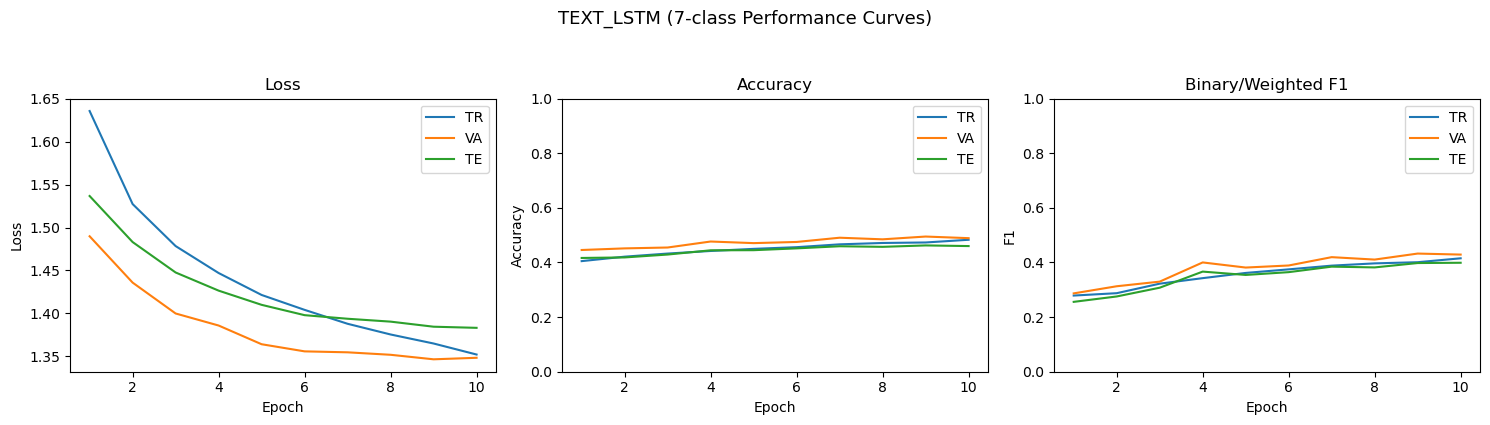

Saved: plots/curves_text_lstm_7class.png
Saved: plots/cm_text_lstm_test_7class.png


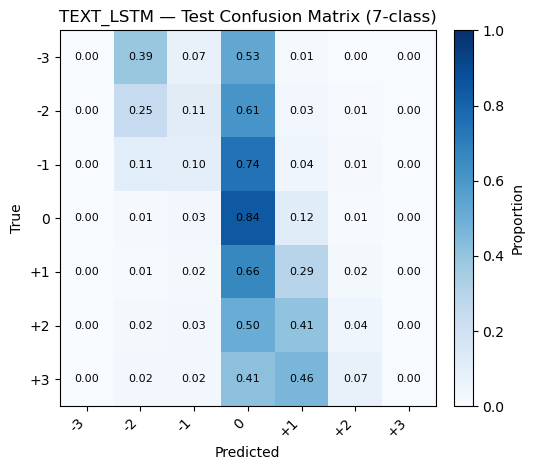


=== Running mode: TEXT_TRANS ===
[TEXT_TRANS] Ep 01 | TR acc 0.405 f1 0.322 | VA acc 0.475 f1 0.382 | TE acc 0.453 f1 0.360
[TEXT_TRANS] Ep 02 | TR acc 0.447 f1 0.384 | VA acc 0.495 f1 0.435 | TE acc 0.473 f1 0.408
[TEXT_TRANS] Ep 03 | TR acc 0.466 f1 0.418 | VA acc 0.505 f1 0.464 | TE acc 0.485 f1 0.441
[TEXT_TRANS] Ep 04 | TR acc 0.478 f1 0.437 | VA acc 0.506 f1 0.473 | TE acc 0.490 f1 0.452
[TEXT_TRANS] Ep 05 | TR acc 0.480 f1 0.440 | VA acc 0.517 f1 0.481 | TE acc 0.494 f1 0.454
[TEXT_TRANS] Ep 06 | TR acc 0.488 f1 0.446 | VA acc 0.505 f1 0.479 | TE acc 0.490 f1 0.459
[TEXT_TRANS] Ep 07 | TR acc 0.493 f1 0.454 | VA acc 0.515 f1 0.475 | TE acc 0.492 f1 0.451
[TEXT_TRANS] Ep 08 | TR acc 0.498 f1 0.458 | VA acc 0.509 f1 0.475 | TE acc 0.495 f1 0.459
[TEXT_TRANS] Ep 09 | TR acc 0.503 f1 0.465 | VA acc 0.509 f1 0.479 | TE acc 0.488 f1 0.455
[TEXT_TRANS] Ep 10 | TR acc 0.505 f1 0.469 | VA acc 0.506 f1 0.480 | TE acc 0.490 f1 0.461
[TEXT_TRANS] BEST@Ep10 | VAL acc 0.506 precision 0.475 r

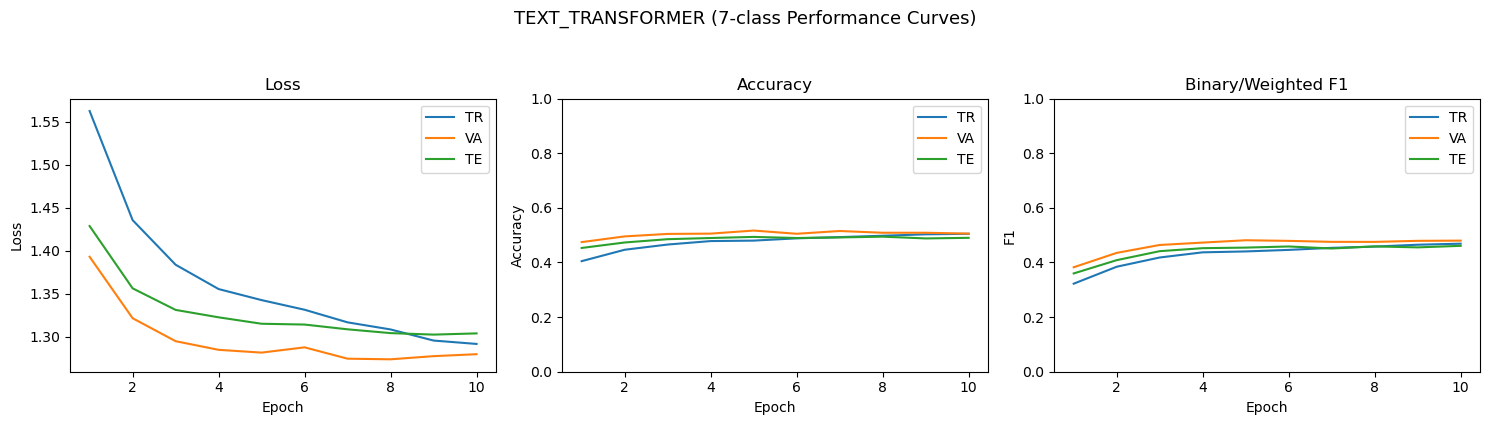

Saved: plots/curves_text_transformer_7class.png
Saved: plots/cm_text_transformer_test_7class.png


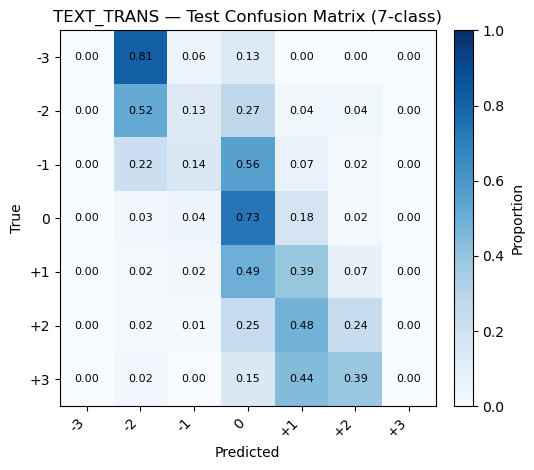


=== Running mode: EARLY ===
[EARLY] Ep 01 | TR acc 0.435 f1 0.367 | VA acc 0.501 f1 0.454 | TE acc 0.478 f1 0.437
[EARLY] Ep 02 | TR acc 0.484 f1 0.450 | VA acc 0.507 f1 0.471 | TE acc 0.495 f1 0.462
[EARLY] Ep 03 | TR acc 0.498 f1 0.466 | VA acc 0.512 f1 0.479 | TE acc 0.505 f1 0.475
[EARLY] Ep 04 | TR acc 0.517 f1 0.490 | VA acc 0.520 f1 0.497 | TE acc 0.514 f1 0.493
[EARLY] Ep 05 | TR acc 0.526 f1 0.501 | VA acc 0.488 f1 0.472 | TE acc 0.496 f1 0.478
[EARLY] Ep 06 | TR acc 0.539 f1 0.519 | VA acc 0.514 f1 0.486 | TE acc 0.505 f1 0.484
[EARLY] Ep 07 | TR acc 0.549 f1 0.530 | VA acc 0.518 f1 0.491 | TE acc 0.505 f1 0.479
[EARLY] Ep 08 | TR acc 0.575 f1 0.558 | VA acc 0.514 f1 0.499 | TE acc 0.506 f1 0.493
[EARLY] Ep 09 | TR acc 0.588 f1 0.572 | VA acc 0.512 f1 0.489 | TE acc 0.506 f1 0.487
[EARLY] Ep 10 | TR acc 0.597 f1 0.583 | VA acc 0.492 f1 0.479 | TE acc 0.493 f1 0.483
[EARLY] BEST@Ep08 | VAL acc 0.514 precision 0.497 recall 0.316 f1 0.499 macroF1 0.323 | TEST acc 0.506 precisio

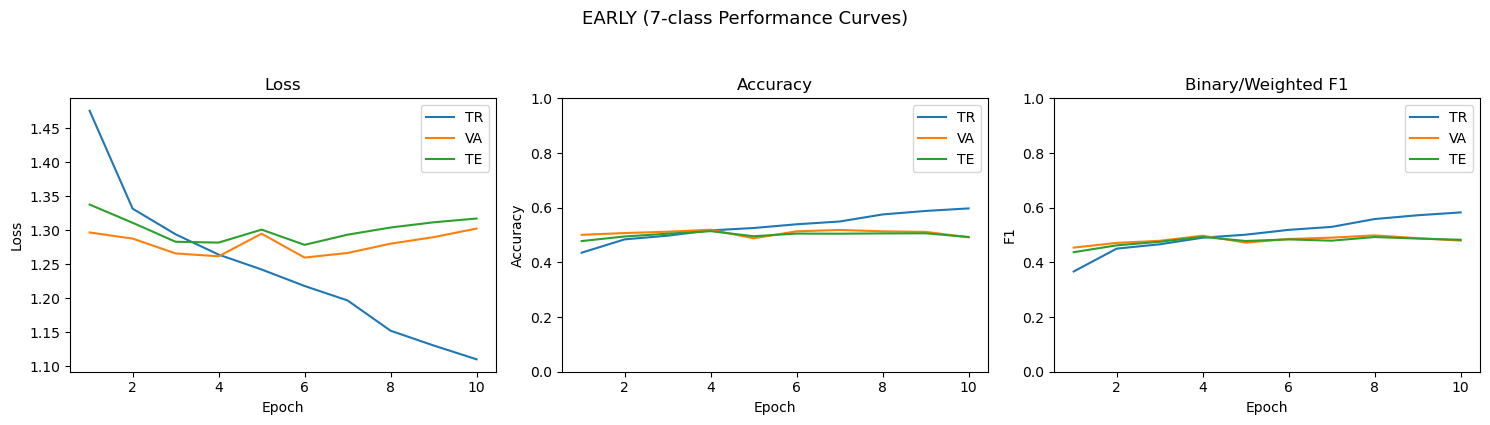

Saved: plots/curves_early_7class.png
Saved: plots/cm_early_test_7class.png


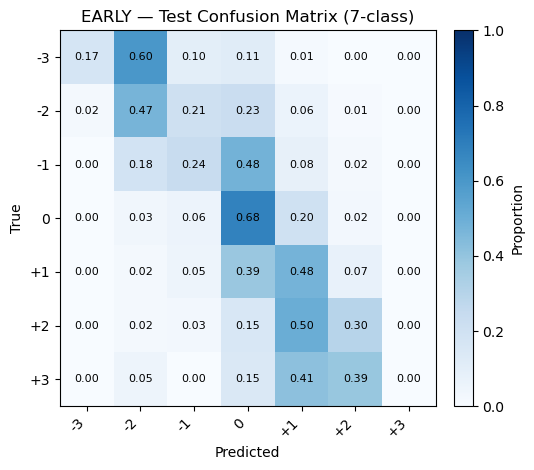


=== Running mode: LATE ===
[LATE] Ep 01 | TR acc 0.437 f1 0.371 | VA acc 0.521 f1 0.471 | TE acc 0.492 f1 0.440
[LATE] Ep 02 | TR acc 0.488 f1 0.452 | VA acc 0.505 f1 0.477 | TE acc 0.496 f1 0.469
[LATE] Ep 03 | TR acc 0.510 f1 0.479 | VA acc 0.508 f1 0.493 | TE acc 0.499 f1 0.485
[LATE] Ep 04 | TR acc 0.526 f1 0.499 | VA acc 0.515 f1 0.491 | TE acc 0.499 f1 0.476
[LATE] Ep 05 | TR acc 0.536 f1 0.512 | VA acc 0.526 f1 0.488 | TE acc 0.510 f1 0.474
[LATE] Ep 06 | TR acc 0.549 f1 0.526 | VA acc 0.507 f1 0.494 | TE acc 0.502 f1 0.487
[LATE] Ep 07 | TR acc 0.573 f1 0.553 | VA acc 0.517 f1 0.508 | TE acc 0.500 f1 0.491
[LATE] Ep 08 | TR acc 0.592 f1 0.575 | VA acc 0.512 f1 0.501 | TE acc 0.498 f1 0.489
[LATE] Ep 09 | TR acc 0.596 f1 0.581 | VA acc 0.513 f1 0.503 | TE acc 0.499 f1 0.493
[LATE] Ep 10 | TR acc 0.611 f1 0.597 | VA acc 0.501 f1 0.491 | TE acc 0.491 f1 0.482
[LATE] BEST@Ep08 | VAL acc 0.512 precision 0.505 recall 0.329 f1 0.501 macroF1 0.342 | TEST acc 0.498 precision 0.491 reca

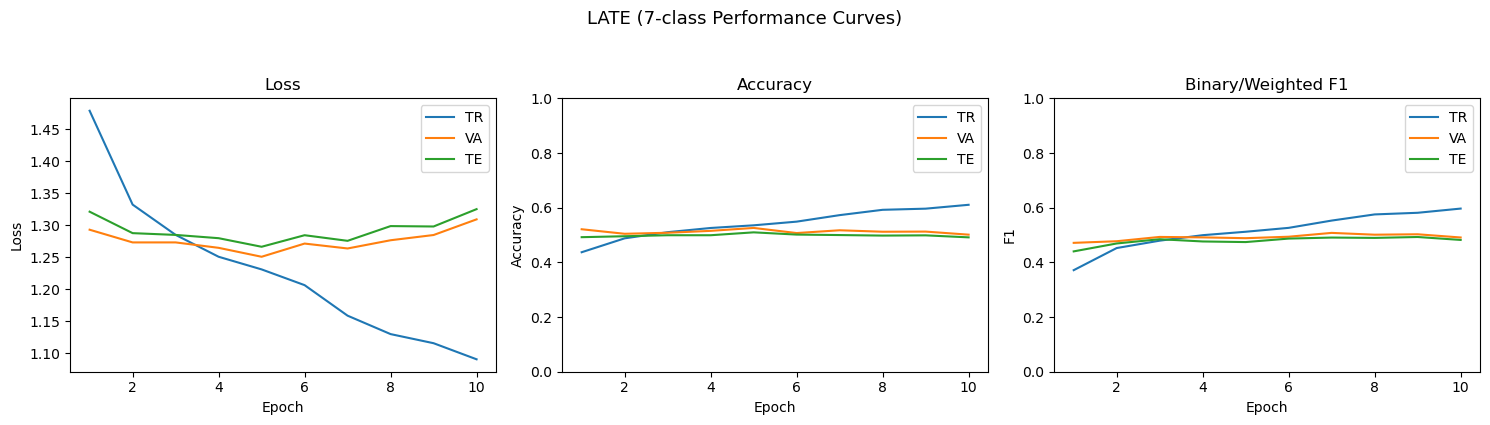

Saved: plots/curves_late_7class.png
Saved: plots/cm_late_test_7class.png


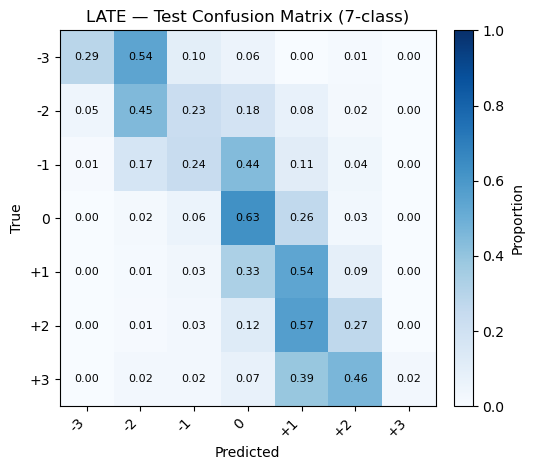


=== Running mode: HYBRID ===
[HYBRID] Ep 01 | TR acc 0.443 f1 0.377 | VA acc 0.508 f1 0.462 | TE acc 0.484 f1 0.443
[HYBRID] Ep 02 | TR acc 0.491 f1 0.455 | VA acc 0.520 f1 0.491 | TE acc 0.496 f1 0.473
[HYBRID] Ep 03 | TR acc 0.515 f1 0.487 | VA acc 0.528 f1 0.505 | TE acc 0.509 f1 0.489
[HYBRID] Ep 04 | TR acc 0.528 f1 0.504 | VA acc 0.499 f1 0.489 | TE acc 0.491 f1 0.478
[HYBRID] Ep 05 | TR acc 0.548 f1 0.527 | VA acc 0.528 f1 0.501 | TE acc 0.502 f1 0.478
[HYBRID] Ep 06 | TR acc 0.564 f1 0.547 | VA acc 0.500 f1 0.494 | TE acc 0.490 f1 0.483
[HYBRID] Ep 07 | TR acc 0.583 f1 0.569 | VA acc 0.514 f1 0.505 | TE acc 0.488 f1 0.481
[HYBRID] Ep 08 | TR acc 0.603 f1 0.590 | VA acc 0.477 f1 0.479 | TE acc 0.475 f1 0.476
[HYBRID] Ep 09 | TR acc 0.619 f1 0.609 | VA acc 0.514 f1 0.496 | TE acc 0.489 f1 0.477
[HYBRID] Ep 10 | TR acc 0.645 f1 0.635 | VA acc 0.491 f1 0.481 | TE acc 0.486 f1 0.482
[HYBRID] BEST@Ep07 | VAL acc 0.514 precision 0.503 recall 0.329 f1 0.505 macroF1 0.345 | TEST acc 0.

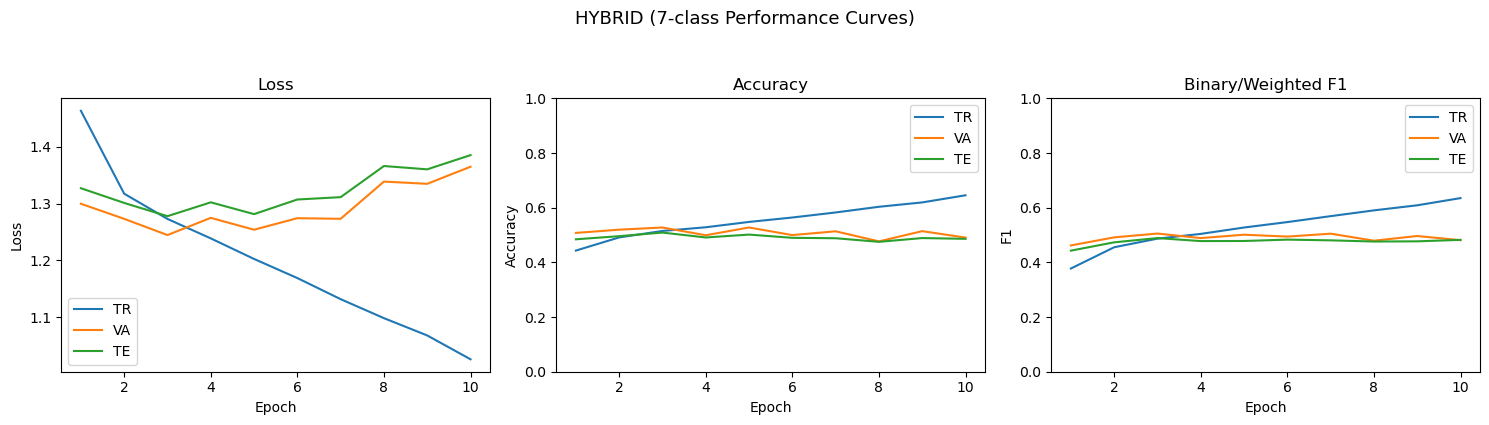

Saved: plots/curves_hybrid_7class.png
Saved: plots/cm_hybrid_test_7class.png


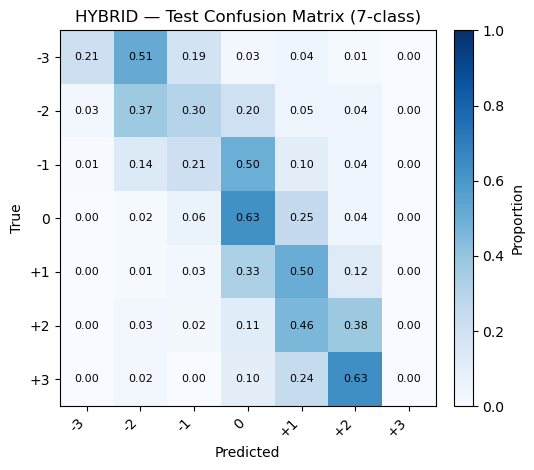

Finished 7-class setting.
Saved: all_results_5models_7class.pkl
Saved: results_5models_summary_7class.csv

All requested label schemes finished: 2-class, 3-class, and 7-class.


In [38]:

os.makedirs("plots", exist_ok=True)

# -----------------------------
# Shared experiment settings
# -----------------------------
RUN_SEED = 42
LABEL_SCHEMES = [2, 3, 7]

EPOCHS = 10
PATIENCE = 5
COMMON_LR = 2e-4
COMMON_WEIGHT_DECAY = 5e-1
COMMON_USE_CW = False
COMMON_LABEL_SMOOTHING = 0.05
GRAD_CLIP = 1.0
USE_SCHEDULER = True
SELECT_METRIC = "macro_f1"   # options: "f1" or "macro_f1"

# -----------------------------
# Output options
# -----------------------------
SHOW_TEST_CM = True
SHOW_VAL_CM = False
CM_NORMALIZE = True
CLASS_NAMES = None

# -----------------------------
# Run mode
# -----------------------------
RUN_MODE = "all"             # "one" or "all"
SELECT_ONE_MODEL = "hybrid"  # "text_lstm", "text_transformer", "early", "late", "hybrid"


def get_class_names(label_scheme):
    if label_scheme == 2:
        return ["Negative", "Non-negative"]
    if label_scheme == 3:
        return ["Negative", "Neutral", "Positive"]
    if label_scheme == 7:
        return ["-3", "-2", "-1", "0", "+1", "+2", "+3"]
    raise ValueError("label_scheme must be 2, 3, or 7")


def print_epoch_line(tag, ep, tr_acc, tr_f1, va_acc, va_f1, te_acc, te_f1):
    print(
        f"[{tag}] Ep {ep:02d} | TR acc {tr_acc:.3f} f1 {tr_f1:.3f} | "
        f"VA acc {va_acc:.3f} f1 {va_f1:.3f} | "
        f"TE acc {te_acc:.3f} f1 {te_f1:.3f}"
    )


def plot_curves(curves, mode, label_scheme):
    epochs = np.arange(1, len(curves["tr_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    ax_loss, ax_acc, ax_f1 = axes

    ax_loss.plot(epochs, curves["tr_loss"], label="TR")
    ax_loss.plot(epochs, curves["va_loss"], label="VA")
    ax_loss.plot(epochs, curves["te_loss"], label="TE")
    ax_loss.set_title("Loss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()

    ax_acc.plot(epochs, curves["tr_acc"], label="TR")
    ax_acc.plot(epochs, curves["va_acc"], label="VA")
    ax_acc.plot(epochs, curves["te_acc"], label="TE")
    ax_acc.set_title("Accuracy")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_ylim(0, 1.0)
    ax_acc.legend()

    ax_f1.plot(epochs, curves["tr_f1"], label="TR")
    ax_f1.plot(epochs, curves["va_f1"], label="VA")
    ax_f1.plot(epochs, curves["te_f1"], label="TE")
    ax_f1.set_title("Binary/Weighted F1")
    ax_f1.set_xlabel("Epoch")
    ax_f1.set_ylabel("F1")
    ax_f1.set_ylim(0, 1.0)
    ax_f1.legend()

    fig.suptitle(
        f"{mode.upper()} ({label_scheme}-class Performance Curves)",
        y=1.05,
        fontsize=13,
    )
    fig.tight_layout()

    outfile = f"plots/curves_{mode}_{label_scheme}class.png"
    fig.savefig(outfile, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {outfile}")


def _normalize_rows(cm):
    cm = cm.astype(float)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    return cm / row_sums


def plot_confusion_matrix(cm, classes, title, normalize=True, outfile=None):
    cm_disp = _normalize_rows(cm) if normalize else cm
    vmax = 1.0 if normalize else (cm_disp.max() if cm_disp.size else 1.0)

    fig, ax = plt.subplots(figsize=(5.6, 4.8))
    im = ax.imshow(cm_disp, cmap="Blues", vmin=0.0, vmax=vmax)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticklabels(classes)

    fmt = ".2f" if normalize else "d"
    for i in range(cm_disp.shape[0]):
        for j in range(cm_disp.shape[1]):
            ax.text(
                j,
                i,
                f"{cm_disp[i, j]:{fmt}}",
                ha="center",
                va="center",
                fontsize=8,
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Proportion" if normalize else "Count")
    fig.tight_layout()

    if outfile is not None:
        fig.savefig(outfile, dpi=200, bbox_inches="tight")
        print(f"Saved: {outfile}")

    plt.show()


def metrics_from_logits(logits, y_true_tensor):
    probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
    y_pred = probs.argmax(axis=1)
    y_true = y_true_tensor.detach().cpu().numpy()

    n_classes = logits.shape[1]

    accuracy = accuracy_score(y_true, y_pred)

    if n_classes == 2:
        # 2-class setting:
        # Class 1 = Non-negative, treated as the positive class.
        precision = precision_score(
            y_true, y_pred, average="binary", zero_division=0
        )
        recall = recall_score(
            y_true, y_pred, average="binary", zero_division=0
        )
        f1 = f1_score(
            y_true, y_pred, average="binary", zero_division=0
        )
    else:
        # 3-class and 7-class settings:
        # Precision and F1 are weighted to reflect class distribution.
        # Recall is macro recall so it does not duplicate accuracy.
        precision = precision_score(
            y_true, y_pred, average="weighted", zero_division=0
        )
        recall = recall_score(
            y_true, y_pred, average="macro", zero_division=0
        )
        f1 = f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        )

    macro_f1 = f1_score(
        y_true, y_pred, average="macro", zero_division=0
    )

    return accuracy, precision, recall, f1, macro_f1, y_true, y_pred


def run_epoch_collect(model, loader, criterion, optimizer=None, grad_clip=1.0):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_logits = []
    all_y = []

    for t, a, v, y in loader:
        t = t.to(device)
        a = a.to(device)
        v = v.to(device)
        y = y.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = _get_logits(model, t, a, v)
            loss = criterion(logits, y)

            if is_train:
                loss.backward()
                if grad_clip is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()

        total_loss += loss.item() * y.size(0)
        all_logits.append(logits.detach().cpu())
        all_y.append(y.detach().cpu())

    all_logits = torch.cat(all_logits, dim=0)
    all_y = torch.cat(all_y, dim=0)
    avg_loss = total_loss / len(loader.dataset)

    return avg_loss, all_logits, all_y


FINAL_MODELS = [
    {"mode": "text_lstm", "tag": "TEXT_LSTM", "build": build_text_lstm_best},
    {"mode": "text_transformer", "tag": "TEXT_TRANS", "build": build_text_transformer_best},
    {"mode": "early", "tag": "EARLY", "build": build_early_best},
    {"mode": "late", "tag": "LATE", "build": build_late_best},
    {"mode": "hybrid", "tag": "HYBRID", "build": build_hybrid_best},
]

valid_modes = [cfg["mode"] for cfg in FINAL_MODELS]

if RUN_MODE not in ["one", "all"]:
    raise ValueError("RUN_MODE must be 'one' or 'all'")

if RUN_MODE == "one":
    if SELECT_ONE_MODEL not in valid_modes:
        raise ValueError(f"SELECT_ONE_MODEL must be one of: {valid_modes}")
    MODELS_TO_RUN = [cfg for cfg in FINAL_MODELS if cfg["mode"] == SELECT_ONE_MODEL]
else:
    MODELS_TO_RUN = FINAL_MODELS

print("Models to run:", [m["mode"] for m in MODELS_TO_RUN])

all_scheme_results = {}

for LABEL_SCHEME in LABEL_SCHEMES:
    print("\n" + "=" * 80)
    print(f"=== Running Final Model Comparison ({LABEL_SCHEME}-class) ===")

    # -----------------------------
    # Rebuild labels for this scheme
    # -----------------------------
    y_tr_raw = derive_labels(y_tr_cont, LABEL_SCHEME)
    y_va_raw = derive_labels(y_va_cont, LABEL_SCHEME)
    y_te_raw = derive_labels(y_te_cont, LABEL_SCHEME)

    y_tr = remap_labels_for_ce(y_tr_raw, LABEL_SCHEME)
    y_va = remap_labels_for_ce(y_va_raw, LABEL_SCHEME)
    y_te = remap_labels_for_ce(y_te_raw, LABEL_SCHEME)

    num_classes = {2: 2, 3: 3, 7: 7}[LABEL_SCHEME]

    # -----------------------------
    # Rebuild datasets and loaders
    # -----------------------------
    train_ds = MoseiDataset(TEXT_TR, AUDIO_TR, VISION_TR, y_tr)
    valid_ds = MoseiDataset(TEXT_VA, AUDIO_VA, VISION_VA, y_va)
    test_ds = MoseiDataset(TEXT_TE, AUDIO_TE, VISION_TE, y_te)

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=False,
        collate_fn=collate_fn,
    )

    valid_loader = DataLoader(
        valid_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_fn,
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_fn,
    )

    class_names = get_class_names(LABEL_SCHEME) if CLASS_NAMES is None else CLASS_NAMES

    if COMMON_USE_CW:
        class_weight_values = compute_class_weight(
            class_weight="balanced",
            classes=np.unique(y_tr),
            y=y_tr,
        )
        weights_tensor = torch.tensor(
            class_weight_values,
            dtype=torch.float32,
            device=device,
        )
    else:
        weights_tensor = None

    all_results = {}
    summary_rows = []

    for cfg in MODELS_TO_RUN:
        mode = cfg["mode"]
        tag = cfg["tag"]

        print(f"\n=== Running mode: {tag} ===")
        set_seed(RUN_SEED)

        model = cfg["build"]().to(device)
        params = count_params(model)

        criterion = nn.CrossEntropyLoss(
            weight=weights_tensor,
            label_smoothing=COMMON_LABEL_SMOOTHING,
        )

        optimizer = optim.AdamW(
            model.parameters(),
            lr=COMMON_LR,
            weight_decay=COMMON_WEIGHT_DECAY,
        )

        scheduler = None
        if USE_SCHEDULER:
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer,
                mode="max",
                factor=0.5,
                patience=2,
            )

        best_score = -1.0
        best_state = None
        best_epoch = 0
        patience_count = 0

        curves = {
            key: []
            for key in [
                "tr_loss", "va_loss", "te_loss",
                "tr_acc", "va_acc", "te_acc",
                "tr_f1", "va_f1", "te_f1",
                "tr_macro_f1", "va_macro_f1", "te_macro_f1",
            ]
        }

        for ep in range(1, EPOCHS + 1):
            tr_loss, tr_logits, tr_y = run_epoch_collect(
                model,
                train_loader,
                criterion,
                optimizer=optimizer,
                grad_clip=GRAD_CLIP,
            )

            tr_acc, tr_prec, tr_rec, tr_f1, tr_macro_f1, _, _ = metrics_from_logits(
                tr_logits, tr_y
            )

            va_loss, va_logits, va_y = run_epoch_collect(
                model,
                valid_loader,
                criterion,
                optimizer=None,
            )

            va_acc, va_prec, va_rec, va_f1, va_macro_f1, va_true, va_pred = metrics_from_logits(
                va_logits, va_y
            )

            te_loss, te_logits, te_y = run_epoch_collect(
                model,
                test_loader,
                criterion,
                optimizer=None,
            )

            te_acc, te_prec, te_rec, te_f1, te_macro_f1, te_true, te_pred = metrics_from_logits(
                te_logits, te_y
            )

            curves["tr_loss"].append(tr_loss)
            curves["va_loss"].append(va_loss)
            curves["te_loss"].append(te_loss)

            curves["tr_acc"].append(tr_acc)
            curves["va_acc"].append(va_acc)
            curves["te_acc"].append(te_acc)

            curves["tr_f1"].append(tr_f1)
            curves["va_f1"].append(va_f1)
            curves["te_f1"].append(te_f1)

            curves["tr_macro_f1"].append(tr_macro_f1)
            curves["va_macro_f1"].append(va_macro_f1)
            curves["te_macro_f1"].append(te_macro_f1)

            print_epoch_line(tag, ep, tr_acc, tr_f1, va_acc, va_f1, te_acc, te_f1)

            if SELECT_METRIC == "f1":
                score = va_f1
            elif SELECT_METRIC == "macro_f1":
                score = va_macro_f1
            else:
                raise ValueError(f"Unsupported SELECT_METRIC: {SELECT_METRIC}")

            if score > best_score:
                best_score = score
                best_state = copy.deepcopy(model.state_dict())
                best_epoch = ep
                patience_count = 0
            else:
                patience_count += 1
                if patience_count >= PATIENCE:
                    print(f"Early stopping at epoch {ep} (best={best_epoch})")
                    break

            if scheduler is not None:
                scheduler.step(score)

        if best_state is None:
            best_state = copy.deepcopy(model.state_dict())

        model.load_state_dict(best_state)

        _, va_logits_best, va_y_best = run_epoch_collect(
            model,
            valid_loader,
            criterion,
            optimizer=None,
        )

        va_acc, va_prec, va_rec, va_f1, va_macro_f1, va_true_np, va_pred_np = metrics_from_logits(
            va_logits_best,
            va_y_best,
        )

        val_cm = confusion_matrix(va_true_np, va_pred_np)

        _, te_logits_best, te_y_best = run_epoch_collect(
            model,
            test_loader,
            criterion,
            optimizer=None,
        )

        te_acc, te_prec, te_rec, te_f1, te_macro_f1, te_true_np, te_pred_np = metrics_from_logits(
            te_logits_best,
            te_y_best,
        )

        test_cm = confusion_matrix(te_true_np, te_pred_np)

        print(
            f"[{tag}] BEST@Ep{best_epoch:02d} | "
            f"VAL acc {va_acc:.3f} precision {va_prec:.3f} recall {va_rec:.3f} "
            f"f1 {va_f1:.3f} macroF1 {va_macro_f1:.3f} | "
            f"TEST acc {te_acc:.3f} precision {te_prec:.3f} recall {te_rec:.3f} "
            f"f1 {te_f1:.3f} macroF1 {te_macro_f1:.3f}"
        )

        plot_curves(curves, mode, LABEL_SCHEME)

        if SHOW_TEST_CM:
            plot_confusion_matrix(
                test_cm,
                class_names,
                title=f"{tag} — Test Confusion Matrix ({LABEL_SCHEME}-class)",
                normalize=CM_NORMALIZE,
                outfile=f"plots/cm_{mode}_test_{LABEL_SCHEME}class.png",
            )

        if SHOW_VAL_CM:
            plot_confusion_matrix(
                val_cm,
                class_names,
                title=f"{tag} — Validation Confusion Matrix ({LABEL_SCHEME}-class)",
                normalize=CM_NORMALIZE,
                outfile=f"plots/cm_{mode}_val_{LABEL_SCHEME}class.png",
            )

        all_results[mode] = {
            "label_scheme": LABEL_SCHEME,
            "class_names": class_names,

            "val_acc": va_acc,
            "val_precision": va_prec,
            "val_recall": va_rec,
            "val_f1": va_f1,
            "val_macro_f1": va_macro_f1,

            "test_acc": te_acc,
            "test_precision": te_prec,
            "test_recall": te_rec,
            "test_f1": te_f1,
            "test_macro_f1": te_macro_f1,

            "best_epoch": best_epoch,
            "params": params,
            "curves": curves,
        }

        summary_rows.append(
            {
                "mode": mode,
                "label_scheme": LABEL_SCHEME,
                "params": params,
                "best_epoch": best_epoch,

                "val_acc": va_acc,
                "val_precision": va_prec,
                "val_recall": va_rec,
                "val_f1": va_f1,
                "val_macro_f1": va_macro_f1,

                "test_acc": te_acc,
                "test_precision": te_prec,
                "test_recall": te_rec,
                "test_f1": te_f1,
                "test_macro_f1": te_macro_f1,
            }
        )

    df_final = pd.DataFrame(summary_rows).set_index("mode")

    with open(f"all_results_5models_{LABEL_SCHEME}class.pkl", "wb") as f:
        pickle.dump(all_results, f)

    df_final.to_csv(f"results_5models_summary_{LABEL_SCHEME}class.csv")

    all_scheme_results[LABEL_SCHEME] = {
        "df_final": df_final.copy(),
        "all_results": all_results,
    }

    print(f"Finished {LABEL_SCHEME}-class setting.")
    print(f"Saved: all_results_5models_{LABEL_SCHEME}class.pkl")
    print(f"Saved: results_5models_summary_{LABEL_SCHEME}class.csv")

print("\nAll requested label schemes finished: 2-class, 3-class, and 7-class.")

## 9.1 Full Validation and Test Result Tables

This section shows the full validation and test performance of all five models across the three sentiment classification settings. The results are used as the basis for the model comparisons in the following sections.

In [88]:
# ============================================================
# Displays validation and test metrics for all five models
# across the 2-class, 3-class, and 7-class settings.
# ============================================================
for i, scheme in enumerate([2, 3, 7], start=1):
    df = pd.read_csv(f"results_5models_summary_{scheme}class.csv")

    keep_cols = [
        "mode",
        "params",
        "best_epoch",
        "val_macro_f1",
        "test_macro_f1",
        "val_f1",
        "test_f1",
        "val_precision",
        "test_precision",
        "val_recall",
        "test_recall",
        "val_acc",
        "test_acc",
    ]

    df = df[keep_cols]

    percent_cols = [
        "val_macro_f1", "test_macro_f1",
        "val_f1", "test_f1",
        "val_precision", "test_precision",
        "val_recall", "test_recall",
        "val_acc", "test_acc",
    ]

    # Convert to percentage and keep 2 decimal places
    df[percent_cols] = (df[percent_cols] * 100).round(2)

    print(f"\nTable B.{i} Full Validation and Test Results for All Models in the {scheme}-Class Setting")
    
    display(
        df.style
        .hide(axis="index")
        .format({
            "params": "{:,.0f}",
            "best_epoch": "{:.0f}",
            "val_macro_f1": "{:.2f}",
            "test_macro_f1": "{:.2f}",
            "val_f1": "{:.2f}",
            "test_f1": "{:.2f}",
            "val_precision": "{:.2f}",
            "test_precision": "{:.2f}",
            "val_recall": "{:.2f}",
            "test_recall": "{:.2f}",
            "val_acc": "{:.2f}",
            "test_acc": "{:.2f}",
        })
    )


Table B.1 Full Validation and Test Results for All Models in the 2-Class Setting


mode,params,best_epoch,val_macro_f1,test_macro_f1,val_f1,test_f1,val_precision,test_precision,val_recall,test_recall,val_acc,test_acc
text_lstm,"93,826",9,72.51,73.26,86.48,85.99,83.78,82.87,89.37,89.36,79.61,79.32
text_transformer,"65,346",8,74.46,74.55,87.39,86.66,84.77,83.54,90.18,90.02,81.01,80.31
early,"735,170",7,75.23,75.19,87.08,86.51,85.99,84.44,88.20,88.69,80.90,80.36
late,"2,084,933",6,74.17,75.28,86.43,86.46,85.56,84.62,87.32,88.39,79.99,80.34
hybrid,"2,076,866",2,74.68,75.29,87.55,87.10,84.81,83.84,90.47,90.63,81.22,80.94



Table B.2 Full Validation and Test Results for All Models in the 3-Class Setting


mode,params,best_epoch,val_macro_f1,test_macro_f1,val_f1,test_f1,val_precision,test_precision,val_recall,test_recall,val_acc,test_acc
text_lstm,"93,891",9,49.78,51.95,56.03,58.47,57.67,60.28,52.74,54.39,60.83,63.04
text_transformer,"65,411",5,54.81,57.76,59.04,62.28,58.68,61.93,55.28,57.92,60.35,63.62
early,"735,363",3,56.96,58.47,61.17,63.05,61.09,63.04,57.22,58.54,62.81,64.81
late,"2,085,126",1,57.02,57.35,61.11,62.00,60.67,61.58,56.96,57.09,62.12,63.21
hybrid,"2,077,059",3,57.13,58.26,61.39,63.18,61.28,63.56,57.50,58.55,63.08,65.41



Table B.3 Full Validation and Test Results for All Models in the 7-Class Setting


mode,params,best_epoch,val_macro_f1,test_macro_f1,val_f1,test_f1,val_precision,test_precision,val_recall,test_recall,val_acc,test_acc
text_lstm,"94,151",9,23.59,21.43,43.26,39.79,44.53,41.46,23.71,21.74,49.49,46.24
text_transformer,"65,671",10,29.18,28.69,47.99,46.09,47.46,45.47,29.73,28.94,50.56,49.02
early,"736,135",8,32.29,34.79,49.87,49.27,49.74,48.93,31.56,33.30,51.36,50.59
late,"2,085,898",8,34.15,36.30,50.12,48.95,50.45,49.15,32.86,34.72,51.20,49.80
hybrid,"2,077,831",7,34.48,34.28,50.50,48.06,50.32,47.77,32.94,32.99,51.36,48.83


## 9.2 RQ1: Baseline Model Comparison (Text LSTM vs Text Transformer)
This section compares the two text-only baseline models: the Text LSTM and the Text Transformer. The comparison shows whether the transformer-based text model improves performance over the traditional LSTM baseline.

Table 4.1: Macro-F1 Performance Comparison of LSTM and Text Transformer Across Class Schemes


Label Scheme,Model,Validation Macro-F1,Test Macro-F1
2-class,LSTM,72.51%,73.26%
2-class,Text Transformer,74.46%,74.55%
3-class,LSTM,49.78%,51.95%
3-class,Text Transformer,54.81%,57.76%
7-class,LSTM,23.59%,21.43%
7-class,Text Transformer,29.18%,28.69%


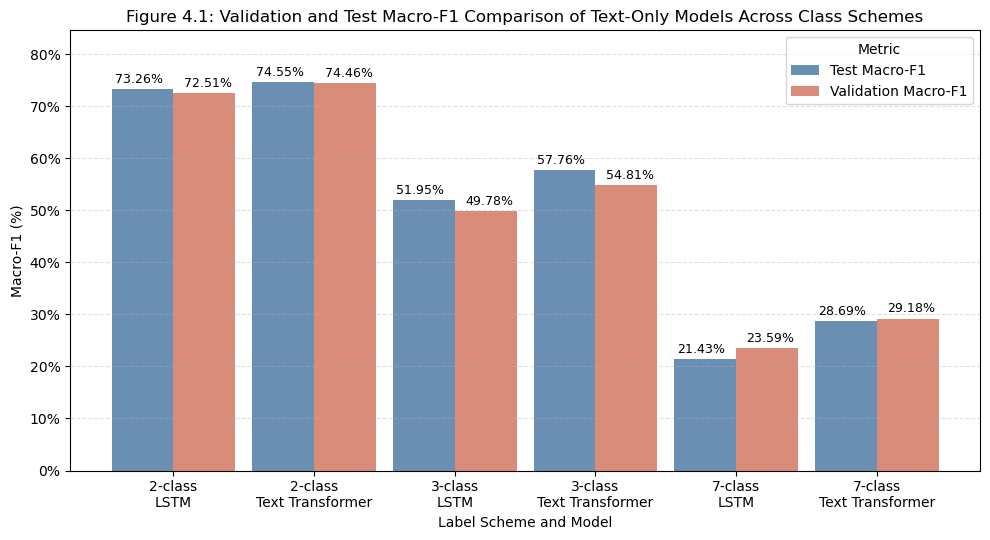

Saved:
 - Table_4_1_RQ1_MacroF1_LSTM_vs_TextTransformer_percent.csv
 - Figure_4_1_RQ1_TestMacroF1_Data.csv

Final Table 4.1 columns:
['Label Scheme', 'Model', 'Validation Macro-F1', 'Test Macro-F1']


In [40]:

# -----------------------------
# File paths
# -----------------------------
scheme_files = {
    "2-class": "results_5models_summary_2class.csv",
    "3-class": "results_5models_summary_3class.csv",
    "7-class": "results_5models_summary_7class.csv",
}

# -----------------------------
# RQ1 settings
# -----------------------------
rq1_models = ["text_lstm", "text_transformer"]

model_name_map = {
    "text_lstm": "LSTM",
    "text_transformer": "Text Transformer",
}

scheme_order = ["2-class", "3-class", "7-class"]

# -----------------------------
# Plot colors
# -----------------------------
test_color = "#6B8FB3"
val_color = "#D98C7A"

# -----------------------------
# Helper function
# -----------------------------
def load_rq1_results(label_scheme, file_path):
    """Load and prepare RQ1 results for one label scheme."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"Cannot find {file_path}. Make sure the five-model summary CSV was saved first."
        )

    df = pd.read_csv(file_path)

    if "Unnamed: 0" in df.columns and "mode" not in df.columns:
        df = df.rename(columns={"Unnamed: 0": "mode"})

    if "mode" not in df.columns:
        raise KeyError(f"'mode' column not found in {file_path}")

    required_cols = [
        "mode",
        "val_macro_f1",
        "test_macro_f1",
    ]

    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(
            f"Missing required columns in {file_path}: {missing}\n"
            f"Available columns: {list(df.columns)}"
        )

    df = df[df["mode"].isin(rq1_models)].copy()
    df["Label Scheme"] = label_scheme
    df["Model"] = df["mode"].map(model_name_map)

    return df


def highlight_best_per_scheme(display_df, numeric_df, metric_cols):
    """Bold the best value within each label scheme."""
    styles = pd.DataFrame("", index=display_df.index, columns=display_df.columns)

    for scheme in display_df["Label Scheme"].unique():
        idx = display_df.index[display_df["Label Scheme"] == scheme].tolist()

        if len(idx) < 2:
            continue

        for col in metric_cols:
            max_val = numeric_df.loc[idx, col].max()
            winners = numeric_df.loc[idx, col] == max_val

            for row_idx in numeric_df.loc[idx].index[winners]:
                styles.loc[row_idx, col] = "font-weight: bold;"

    return styles


# -----------------------------
# Load results
# -----------------------------
rq1_frames = []

for scheme, file_path in scheme_files.items():
    rq1_frames.append(load_rq1_results(scheme, file_path))

df_rq1 = pd.concat(rq1_frames, ignore_index=True)

df_rq1["Label Scheme"] = pd.Categorical(
    df_rq1["Label Scheme"],
    categories=scheme_order,
    ordered=True,
)

df_rq1["mode"] = pd.Categorical(
    df_rq1["mode"],
    categories=rq1_models,
    ordered=True,
)

df_rq1 = df_rq1.sort_values(["Label Scheme", "mode"]).reset_index(drop=True)

# ============================================================
# Table 4.1
# ============================================================
rq1_table = df_rq1[
    [
        "Label Scheme",
        "Model",
        "val_macro_f1",
        "test_macro_f1",
    ]
].copy()

rq1_table = rq1_table.rename(columns={
    "val_macro_f1": "Validation Macro-F1",
    "test_macro_f1": "Test Macro-F1",
})

numeric_cols = [
    "Validation Macro-F1",
    "Test Macro-F1",
]

rq1_table_numeric = rq1_table.copy()
rq1_table_display = rq1_table.copy()

for col in numeric_cols:
    rq1_table_display[col] = (
        rq1_table_display[col] * 100
    ).round(2).map(lambda x: f"{x:.2f}%")

styles = highlight_best_per_scheme(
    rq1_table_display,
    rq1_table_numeric,
    numeric_cols,
)

print("Table 4.1: Macro-F1 Performance Comparison of LSTM and Text Transformer Across Class Schemes")

styled_rq1 = (
    rq1_table_display.style
    .hide(axis="index")
    .set_caption(
        "Table 4.1: Macro-F1 Performance Comparison of LSTM and Text Transformer Across Class Schemes"
    )
    .set_properties(subset=["Label Scheme", "Model"], **{
        "text-align": "center",
        "white-space": "nowrap",
    })
    .set_properties(subset=numeric_cols, **{
        "text-align": "center",
        "white-space": "nowrap",
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("margin-bottom", "10px"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
                ("border-bottom", "1.5px solid black"),
                ("padding", "8px"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("padding", "8px"),
            ],
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "0 auto"),
                ("font-size", "14px"),
            ],
        },
    ])
    .apply(lambda _: styles, axis=None)
)

display(styled_rq1)

rq1_table_display.to_csv(
    "Table_4_1_RQ1_MacroF1_LSTM_vs_TextTransformer_percent.csv",
    index=False
)

# ============================================================
# Figure 4.1
# Validation and Test Macro-F1 across label schemes
# ============================================================
plot_macro = df_rq1[
    ["Label Scheme", "Model", "val_macro_f1", "test_macro_f1"]
].melt(
    id_vars=["Label Scheme", "Model"],
    value_vars=["val_macro_f1", "test_macro_f1"],
    var_name="Metric",
    value_name="Score",
)

plot_macro["Metric"] = plot_macro["Metric"].map({
    "val_macro_f1": "Validation Macro-F1",
    "test_macro_f1": "Test Macro-F1",
})

plot_macro["X"] = plot_macro["Label Scheme"].astype(str) + "\n" + plot_macro["Model"]

x_order = []
for scheme in scheme_order:
    x_order.append(f"{scheme}\nLSTM")
    x_order.append(f"{scheme}\nText Transformer")

pivot_macro = plot_macro.pivot(
    index="X",
    columns="Metric",
    values="Score",
).reindex(x_order)

fig, ax = plt.subplots(figsize=(10, 5.5))

x = np.arange(len(pivot_macro.index))
width = 0.44

bars1 = ax.bar(
    x - width / 2,
    pivot_macro["Test Macro-F1"],
    width,
    label="Test Macro-F1",
    color=test_color,
)

bars2 = ax.bar(
    x + width / 2,
    pivot_macro["Validation Macro-F1"],
    width,
    label="Validation Macro-F1",
    color=val_color,
)

ax.set_title(
    "Figure 4.1: Validation and Test Macro-F1 Comparison of Text-Only Models Across Class Schemes"
)
ax.set_xlabel("Label Scheme and Model")
ax.set_ylabel("Macro-F1 (%)")
ax.set_xticks(x)
ax.set_xticklabels(pivot_macro.index, rotation=0)
ax.set_ylim(0, pivot_macro.max().max() + 0.10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Metric")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))

for bar in bars1:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2 - 0.025,
        h + 0.006,
        f"{h * 100:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )

for bar in bars2:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2 + 0.025,
        h + 0.006,
        f"{h * 100:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

# -----------------------------
# Save outputs
# -----------------------------
plot_macro.to_csv("Figure_4_1_RQ1_TestMacroF1_Data.csv")

print("Saved:")
print(" - Table_4_1_RQ1_MacroF1_LSTM_vs_TextTransformer_percent.csv")
print(" - Figure_4_1_RQ1_TestMacroF1_Data.csv")

print("\nFinal Table 4.1 columns:")
print(rq1_table_display.columns.tolist())

### 9.3 RQ2: Multimodal Fusion Strategy Comparison

This section compares the three multimodal fusion strategies: Early Fusion, Late Fusion, and Hybrid Fusion. The comparison shows which fusion method performs better when text, audio, and visual features are combined.

Table 4.2: Macro-F1 Performance Comparison of Multimodal Fusion Strategies Across Class Schemes


Label Scheme,Model,Validation Macro-F1,Test Macro-F1
2-class,Early Fusion,75.23%,75.19%
2-class,Late Fusion,74.17%,75.28%
2-class,Hybrid Fusion,74.68%,75.29%
3-class,Early Fusion,56.96%,58.47%
3-class,Late Fusion,57.02%,57.35%
3-class,Hybrid Fusion,57.13%,58.26%
7-class,Early Fusion,32.29%,34.79%
7-class,Late Fusion,34.15%,36.30%
7-class,Hybrid Fusion,34.48%,34.28%


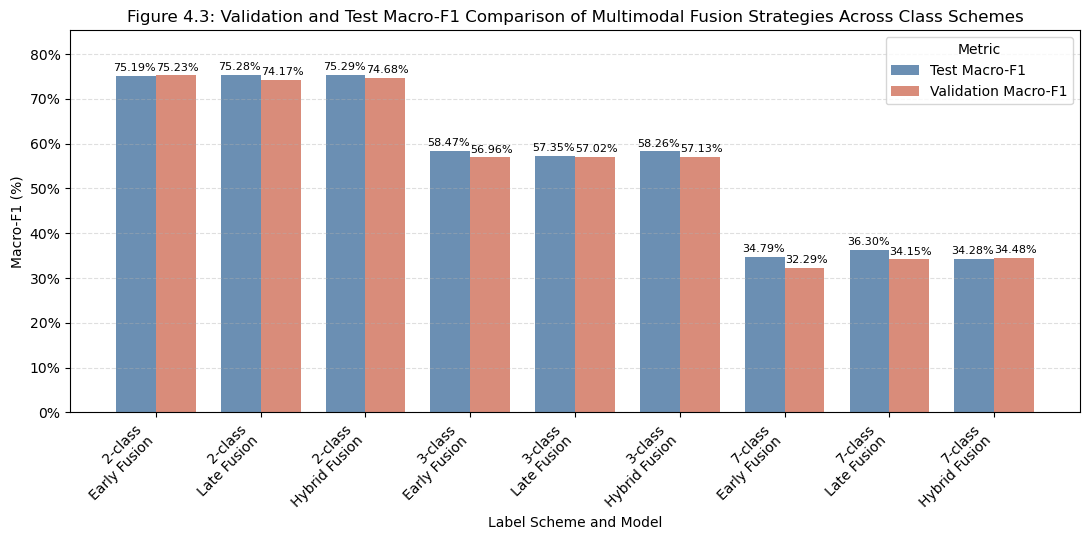

Saved:
 - Table_4_2_RQ2_MacroF1_Fusion_Strategies_percent.csv
 - Figure_4_3_RQ2_Val_vs_Test_MacroF1_Data.csv

Final Table 4.2 columns:
['Label Scheme', 'Model', 'Validation Macro-F1', 'Test Macro-F1']


In [42]:

# -----------------------------
# File paths
# -----------------------------
scheme_files = {
    "2-class": "results_5models_summary_2class.csv",
    "3-class": "results_5models_summary_3class.csv",
    "7-class": "results_5models_summary_7class.csv",
}

# -----------------------------
# RQ2 settings
# -----------------------------
rq2_models = ["early", "late", "hybrid"]

model_name_map = {
    "early": "Early Fusion",
    "late": "Late Fusion",
    "hybrid": "Hybrid Fusion",
}

scheme_order = ["2-class", "3-class", "7-class"]

# -----------------------------
# Plot colors
# -----------------------------
test_color = "#6B8FB3"
val_color = "#D98C7A"

# -----------------------------
# Helper function
# -----------------------------
def load_rq2_results(label_scheme, file_path):
    """Load and prepare RQ2 results."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Missing file: {file_path}")

    df = pd.read_csv(file_path)

    if "Unnamed: 0" in df.columns and "mode" not in df.columns:
        df = df.rename(columns={"Unnamed: 0": "mode"})

    if "mode" not in df.columns:
        raise KeyError(f"'mode' column not found in {file_path}")

    required_cols = [
        "mode",
        "val_macro_f1",
        "test_macro_f1",
    ]

    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(
            f"Missing required columns in {file_path}: {missing}\n"
            f"Available columns: {list(df.columns)}"
        )

    df = df[df["mode"].isin(rq2_models)].copy()
    df["Label Scheme"] = label_scheme
    df["Model"] = df["mode"].map(model_name_map)

    return df


def highlight_best_per_scheme(display_df, numeric_df, metric_cols):
    """Bold best values per label scheme."""
    styles = pd.DataFrame("", index=display_df.index, columns=display_df.columns)

    for scheme in display_df["Label Scheme"].unique():
        idx = display_df.index[display_df["Label Scheme"] == scheme].tolist()

        for col in metric_cols:
            max_val = numeric_df.loc[idx, col].max()
            winners = numeric_df.loc[idx, col] == max_val

            for row_idx in numeric_df.loc[idx].index[winners]:
                styles.loc[row_idx, col] = "font-weight: bold;"

    return styles


# -----------------------------
# Load results
# -----------------------------
rq2_frames = []

for scheme, file_path in scheme_files.items():
    rq2_frames.append(load_rq2_results(scheme, file_path))

df_rq2 = pd.concat(rq2_frames, ignore_index=True)

df_rq2["Label Scheme"] = pd.Categorical(
    df_rq2["Label Scheme"],
    categories=scheme_order,
    ordered=True
)

df_rq2["mode"] = pd.Categorical(
    df_rq2["mode"],
    categories=rq2_models,
    ordered=True
)

df_rq2 = df_rq2.sort_values(["Label Scheme", "mode"]).reset_index(drop=True)

# ============================================================
# Table 4.2
# ============================================================
rq2_table = df_rq2[
    [
        "Label Scheme",
        "Model",
        "val_macro_f1",
        "test_macro_f1",
    ]
].copy()

rq2_table = rq2_table.rename(columns={
    "val_macro_f1": "Validation Macro-F1",
    "test_macro_f1": "Test Macro-F1",
})

numeric_cols = [
    "Validation Macro-F1",
    "Test Macro-F1",
]

rq2_table_numeric = rq2_table.copy()
rq2_table_display = rq2_table.copy()

for col in numeric_cols:
    rq2_table_display[col] = (
        rq2_table_display[col] * 100
    ).round(2).map(lambda x: f"{x:.2f}%")

styles = highlight_best_per_scheme(
    rq2_table_display,
    rq2_table_numeric,
    numeric_cols
)

print("Table 4.2: Macro-F1 Performance Comparison of Multimodal Fusion Strategies Across Class Schemes")

styled_rq2 = (
    rq2_table_display.style
    .hide(axis="index")
    .set_caption(
        "Table 4.2: Macro-F1 Performance Comparison of Multimodal Fusion Strategies Across Class Schemes"
    )
    .set_properties(subset=["Label Scheme", "Model"], **{
        "text-align": "center",
        "white-space": "nowrap"
    })
    .set_properties(subset=numeric_cols, **{
        "text-align": "center",
        "white-space": "nowrap"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("margin-bottom", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
                ("border-bottom", "1.5px solid black"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "8px")
            ]
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "0 auto"),
                ("font-size", "14px")
            ]
        }
    ])
    .apply(lambda _: styles, axis=None)
)

display(styled_rq2)

rq2_table_display.to_csv(
    "Table_4_2_RQ2_MacroF1_Fusion_Strategies_percent.csv",
    index=False
)

# ============================================================
# Figure 4.3
# Validation and Test Macro-F1 comparison across label schemes
# ============================================================
plot_macro = df_rq2[
    ["Label Scheme", "Model", "val_macro_f1", "test_macro_f1"]
].melt(
    id_vars=["Label Scheme", "Model"],
    value_vars=["val_macro_f1", "test_macro_f1"],
    var_name="Metric",
    value_name="Score"
)

plot_macro["Metric"] = plot_macro["Metric"].map({
    "val_macro_f1": "Validation Macro-F1",
    "test_macro_f1": "Test Macro-F1",
})

plot_macro["X"] = (
    plot_macro["Label Scheme"].astype(str)
    + "\n"
    + plot_macro["Model"].astype(str)
)

x_order = []

for scheme in scheme_order:
    x_order.append(f"{scheme}\nEarly Fusion")
    x_order.append(f"{scheme}\nLate Fusion")
    x_order.append(f"{scheme}\nHybrid Fusion")

pivot_macro = plot_macro.pivot(
    index="X",
    columns="Metric",
    values="Score"
).reindex(x_order)

fig, ax = plt.subplots(figsize=(11, 5.5))

x = np.arange(len(pivot_macro.index))
width = 0.38

bars1 = ax.bar(
    x - width / 2,
    pivot_macro["Test Macro-F1"],
    width,
    label="Test Macro-F1",
    color=test_color
)

bars2 = ax.bar(
    x + width / 2,
    pivot_macro["Validation Macro-F1"],
    width,
    label="Validation Macro-F1",
    color=val_color
)

ax.set_title(
    "Figure 4.3: Validation and Test Macro-F1 Comparison of Multimodal Fusion Strategies Across Class Schemes"
)
ax.set_xlabel("Label Scheme and Model")
ax.set_ylabel("Macro-F1 (%)")
ax.set_xticks(x)
ax.set_xticklabels(pivot_macro.index, rotation=45, ha="right")
ax.set_ylim(0, pivot_macro.max().max() + 0.10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Metric")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))

for bar in bars1:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2 - 0.015,
        h + 0.006,
        f"{h * 100:.2f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

for bar in bars2:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2 + 0.015,
        h + 0.006,
        f"{h * 100:.2f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

# -----------------------------
# Save outputs
# -----------------------------
pivot_macro.to_csv("Figure_4_3_RQ2_Val_vs_Test_MacroF1_Data.csv")

print("Saved:")
print(" - Table_4_2_RQ2_MacroF1_Fusion_Strategies_percent.csv")
print(" - Figure_4_3_RQ2_Val_vs_Test_MacroF1_Data.csv")

print("\nFinal Table 4.2 columns:")
print(rq2_table_display.columns.tolist())

### 9.4 RQ3: Text-Only vs Multimodal Transformer Comparison

This section compares the Text Transformer with the multimodal transformer models. The aim is to evaluate whether adding audio and visual features improves performance compared with using text only.

Table 4.3: Macro-F1 Performance Comparison of Text-Only and Multimodal Transformer Models Across Class Schemes


Label Scheme,Model,Validation Macro-F1,Test Macro-F1
2-class,Text Transformer,74.46%,74.55%
2-class,Early Fusion,75.23%,75.19%
2-class,Late Fusion,74.17%,75.28%
2-class,Hybrid Fusion,74.68%,75.29%
3-class,Text Transformer,54.81%,57.76%
3-class,Early Fusion,56.96%,58.47%
3-class,Late Fusion,57.02%,57.35%
3-class,Hybrid Fusion,57.13%,58.26%
7-class,Text Transformer,29.18%,28.69%
7-class,Early Fusion,32.29%,34.79%


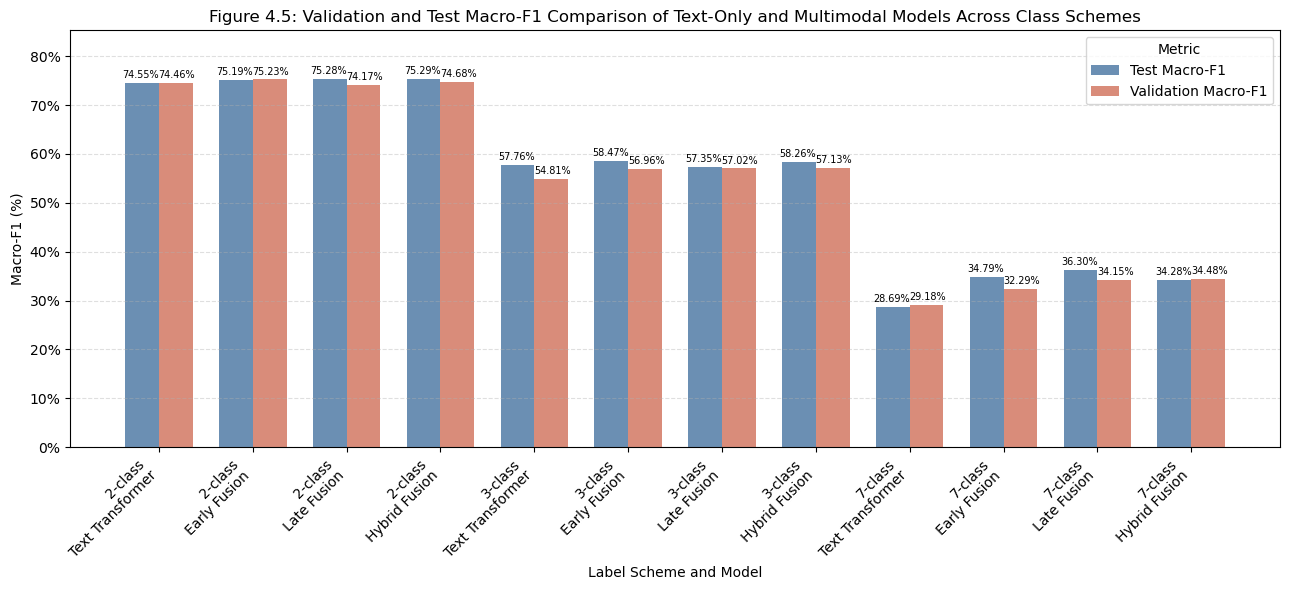

Saved:
 - Table_4_3_RQ3_MacroF1_Text_vs_Multimodal_percent.csv
 - Figure_4_5_RQ3_Val_vs_Test_MacroF1_Data.csv

Final Table 4.3 columns:
['Label Scheme', 'Model', 'Validation Macro-F1', 'Test Macro-F1']


In [44]:


# -----------------------------
# File paths
# -----------------------------
scheme_files = {
    "2-class": "results_5models_summary_2class.csv",
    "3-class": "results_5models_summary_3class.csv",
    "7-class": "results_5models_summary_7class.csv",
}

# -----------------------------
# RQ3 settings
# -----------------------------
rq3_models = ["text_transformer", "early", "late", "hybrid"]

model_name_map = {
    "text_transformer": "Text Transformer",
    "early": "Early Fusion",
    "late": "Late Fusion",
    "hybrid": "Hybrid Fusion",
}

scheme_order = ["2-class", "3-class", "7-class"]

# -----------------------------
# Colors
# -----------------------------
test_color = "#6B8FB3"
val_color = "#D98C7A"

# -----------------------------
# Helper functions
# -----------------------------
def load_rq3_results(label_scheme, file_path):
    """Load and prepare RQ3 results."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Missing file: {file_path}")

    df = pd.read_csv(file_path)

    if "Unnamed: 0" in df.columns and "mode" not in df.columns:
        df = df.rename(columns={"Unnamed: 0": "mode"})

    if "mode" not in df.columns:
        raise KeyError(f"'mode' column not found in {file_path}")

    required_cols = [
        "mode",
        "val_macro_f1",
        "test_macro_f1",
    ]

    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(
            f"Missing required columns in {file_path}: {missing}\n"
            f"Available columns: {list(df.columns)}"
        )

    df = df[df["mode"].isin(rq3_models)].copy()
    df["Label Scheme"] = label_scheme
    df["Model"] = df["mode"].map(model_name_map)

    return df


def highlight_best_per_scheme(display_df, numeric_df, metric_cols):
    """Bold best values within each label scheme."""
    styles = pd.DataFrame("", index=display_df.index, columns=display_df.columns)

    for scheme in display_df["Label Scheme"].unique():
        idx = display_df.index[display_df["Label Scheme"] == scheme].tolist()

        for col in metric_cols:
            max_val = numeric_df.loc[idx, col].max()
            winners = numeric_df.loc[idx, col] == max_val

            for row_idx in numeric_df.loc[idx].index[winners]:
                styles.loc[row_idx, col] = "font-weight: bold;"

    return styles


# -----------------------------
# Load results
# -----------------------------
df_rq3 = pd.concat(
    [load_rq3_results(s, f) for s, f in scheme_files.items()],
    ignore_index=True,
)

df_rq3["Label Scheme"] = pd.Categorical(
    df_rq3["Label Scheme"],
    categories=scheme_order,
    ordered=True
)

df_rq3["mode"] = pd.Categorical(
    df_rq3["mode"],
    categories=rq3_models,
    ordered=True
)

df_rq3 = df_rq3.sort_values(["Label Scheme", "mode"]).reset_index(drop=True)

# ============================================================
# Table 4.3
# ============================================================
rq3_table = df_rq3[
    [
        "Label Scheme",
        "Model",
        "val_macro_f1",
        "test_macro_f1",
    ]
].copy()

rq3_table = rq3_table.rename(columns={
    "val_macro_f1": "Validation Macro-F1",
    "test_macro_f1": "Test Macro-F1",
})

numeric_cols = [
    "Validation Macro-F1",
    "Test Macro-F1",
]

rq3_numeric = rq3_table.copy()
rq3_display = rq3_table.copy()

for col in numeric_cols:
    rq3_display[col] = (
        rq3_display[col] * 100
    ).round(2).map(lambda x: f"{x:.2f}%")

styles = highlight_best_per_scheme(
    rq3_display,
    rq3_numeric,
    numeric_cols
)

print("Table 4.3: Macro-F1 Performance Comparison of Text-Only and Multimodal Transformer Models Across Class Schemes")

styled_rq3 = (
    rq3_display.style
    .hide(axis="index")
    .set_caption(
        "Table 4.3: Macro-F1 Performance Comparison of Text-Only and Multimodal Transformer Models Across Class Schemes"
    )
    .set_properties(subset=["Label Scheme", "Model"], **{
        "text-align": "center",
        "white-space": "nowrap"
    })
    .set_properties(subset=numeric_cols, **{
        "text-align": "center",
        "white-space": "nowrap"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("margin-bottom", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
                ("border-bottom", "1.5px solid black"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "8px")
            ]
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "0 auto"),
                ("font-size", "14px")
            ]
        }
    ])
    .apply(lambda _: styles, axis=None)
)

display(styled_rq3)

rq3_display.to_csv(
    "Table_4_3_RQ3_MacroF1_Text_vs_Multimodal_percent.csv",
    index=False
)

# ============================================================
# Figure 4.5
# Validation and Test Macro-F1 comparison across label schemes
# ============================================================
plot_macro = df_rq3[
    ["Label Scheme", "Model", "val_macro_f1", "test_macro_f1"]
].melt(
    id_vars=["Label Scheme", "Model"],
    value_vars=["val_macro_f1", "test_macro_f1"],
    var_name="Metric",
    value_name="Score"
)

plot_macro["Metric"] = plot_macro["Metric"].map({
    "val_macro_f1": "Validation Macro-F1",
    "test_macro_f1": "Test Macro-F1",
})

plot_macro["X"] = (
    plot_macro["Label Scheme"].astype(str)
    + "\n"
    + plot_macro["Model"].astype(str)
)

x_order = []

for scheme in scheme_order:
    x_order.append(f"{scheme}\nText Transformer")
    x_order.append(f"{scheme}\nEarly Fusion")
    x_order.append(f"{scheme}\nLate Fusion")
    x_order.append(f"{scheme}\nHybrid Fusion")

pivot_macro = plot_macro.pivot(
    index="X",
    columns="Metric",
    values="Score"
).reindex(x_order)

fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(pivot_macro.index))
width = 0.36

bars1 = ax.bar(
    x - width / 2,
    pivot_macro["Test Macro-F1"],
    width,
    label="Test Macro-F1",
    color=test_color
)

bars2 = ax.bar(
    x + width / 2,
    pivot_macro["Validation Macro-F1"],
    width,
    label="Validation Macro-F1",
    color=val_color
)

ax.set_title(
    "Figure 4.5: Validation and Test Macro-F1 Comparison of Text-Only and Multimodal Models Across Class Schemes"
)
ax.set_xlabel("Label Scheme and Model")
ax.set_ylabel("Macro-F1 (%)")
ax.set_xticks(x)
ax.set_xticklabels(pivot_macro.index, rotation=45, ha="right")
ax.set_ylim(0, pivot_macro.max().max() + 0.10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Metric")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))

for bar in bars1:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2 - 0.012,
        h + 0.006,
        f"{h * 100:.2f}%",
        ha="center",
        va="bottom",
        fontsize=7
    )

for bar in bars2:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2 + 0.012,
        h + 0.006,
        f"{h * 100:.2f}%",
        ha="center",
        va="bottom",
        fontsize=7
    )

plt.tight_layout()
plt.show()

# -----------------------------
# Save outputs
# -----------------------------
pivot_macro.to_csv("Figure_4_5_RQ3_Val_vs_Test_MacroF1_Data.csv")

print("Saved:")
print(" - Table_4_3_RQ3_MacroF1_Text_vs_Multimodal_percent.csv")
print(" - Figure_4_5_RQ3_Val_vs_Test_MacroF1_Data.csv")

print("\nFinal Table 4.3 columns:")
print(rq3_display.columns.tolist())

## 9.5. Validation and Test Performance Visualization

This section presents grouped bar-chart panels comparing validation and test performance across the five main models for the 2-class, 3-class, and 7-class settings. It shows F1-score, precision, recall, and accuracy using a shared y-axis within each panel to make small performance differences easier to compare.

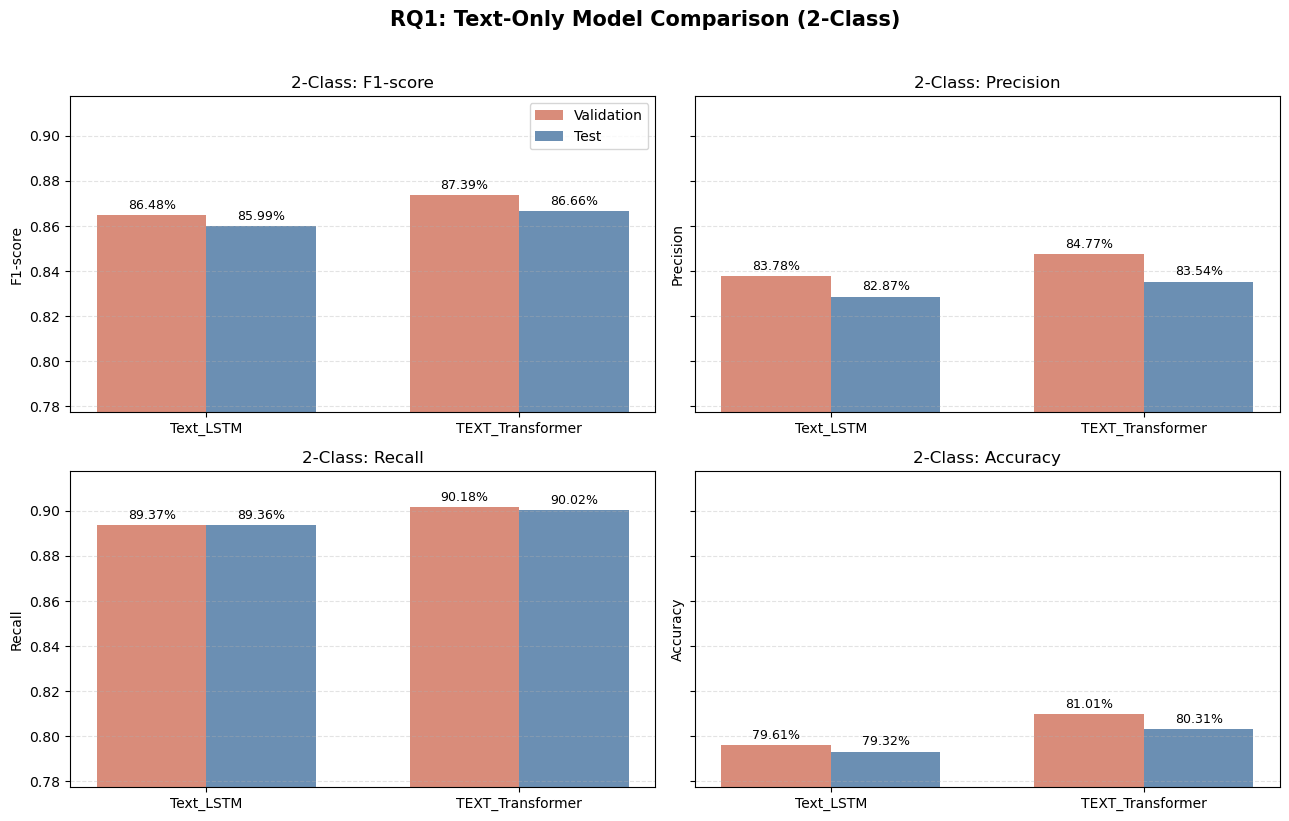

Saved: plots/k2_rq1_lstm_vs_text_transformer_metrics_panel.png


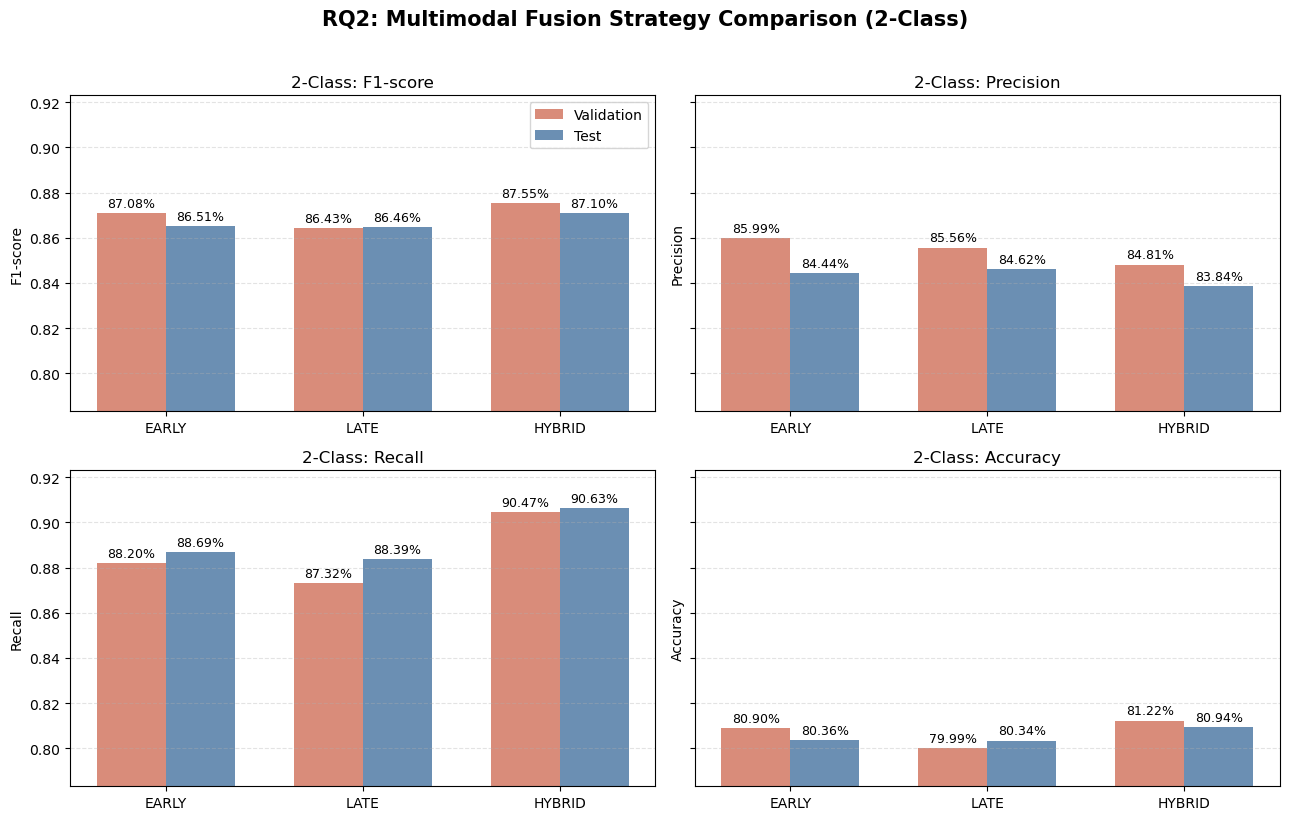

Saved: plots/k2_rq2_early_late_hybrid_metrics_panel.png


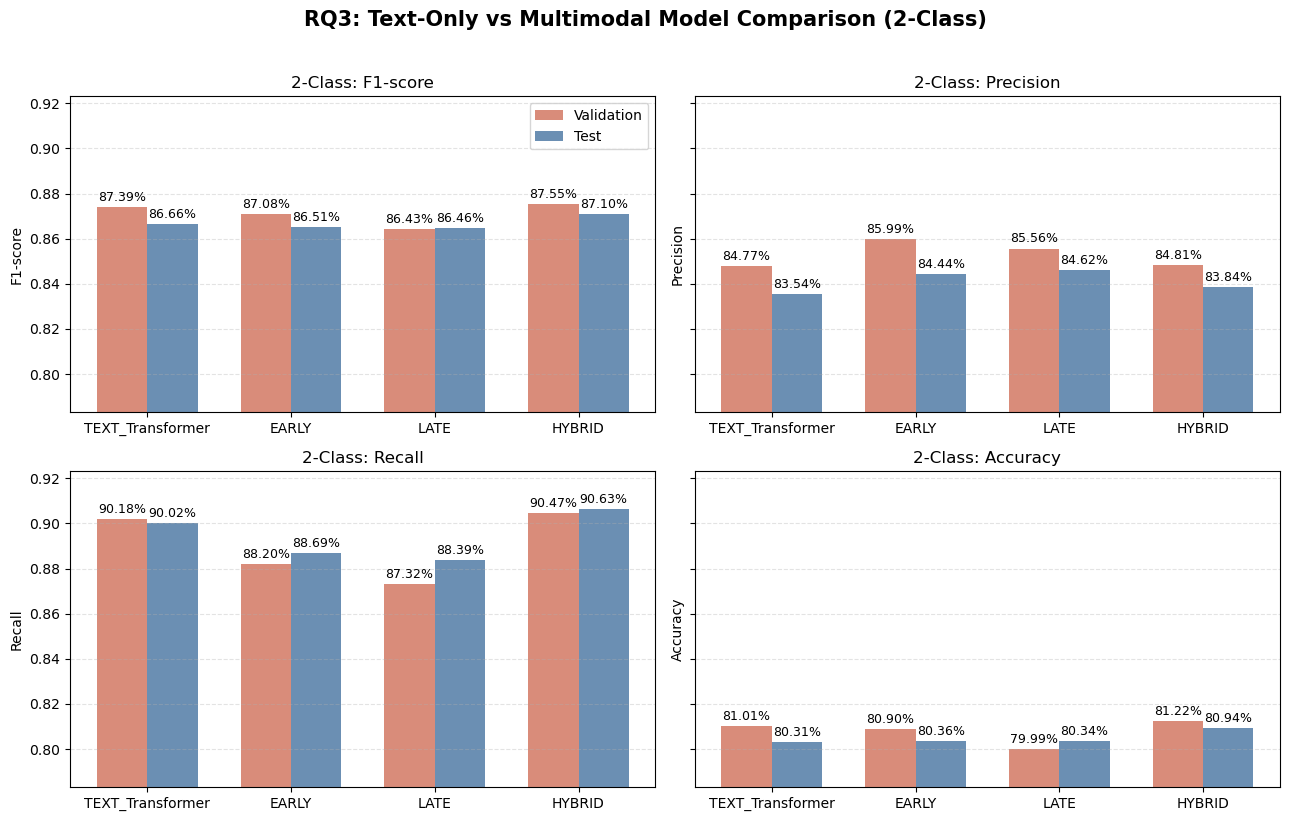

Saved: plots/k2_rq3_text_vs_multimodal_metrics_panel.png


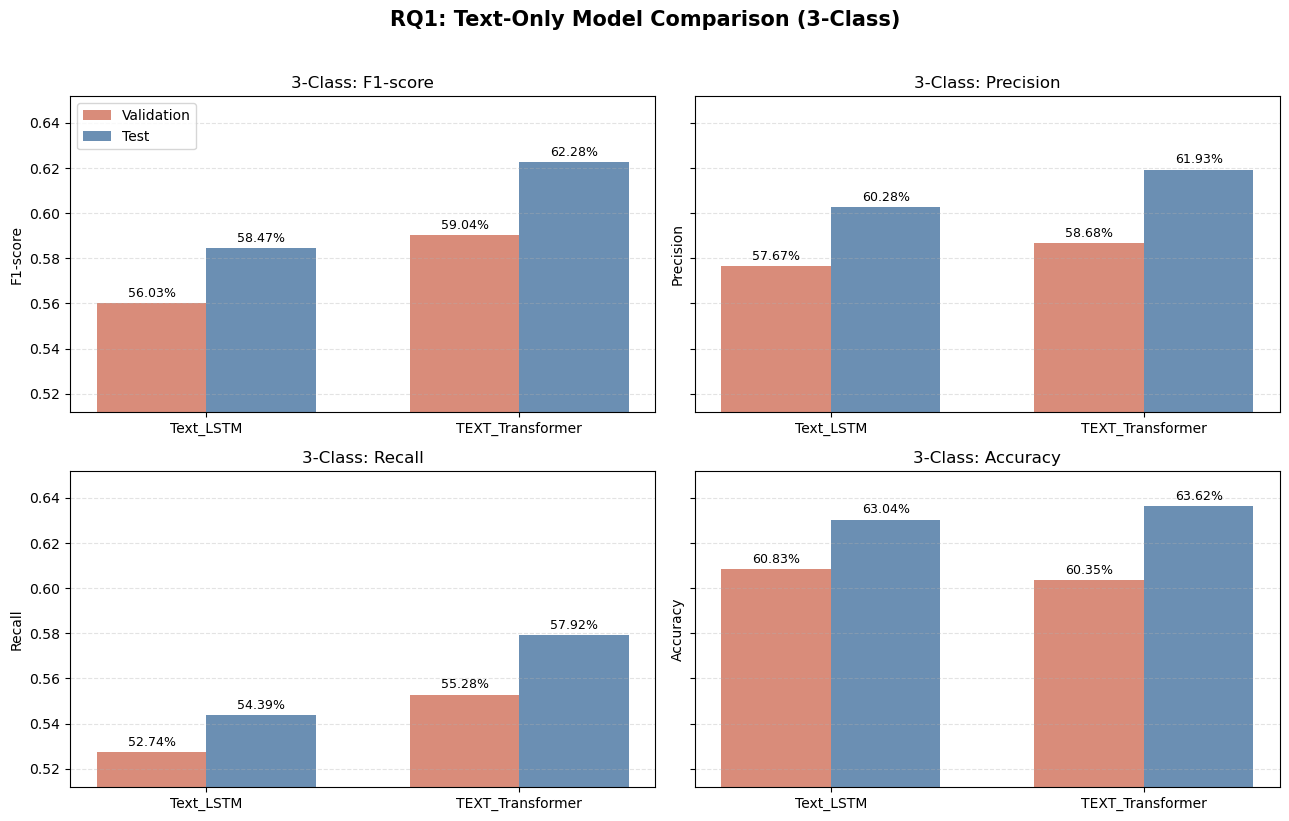

Saved: plots/k3_rq1_lstm_vs_text_transformer_metrics_panel.png


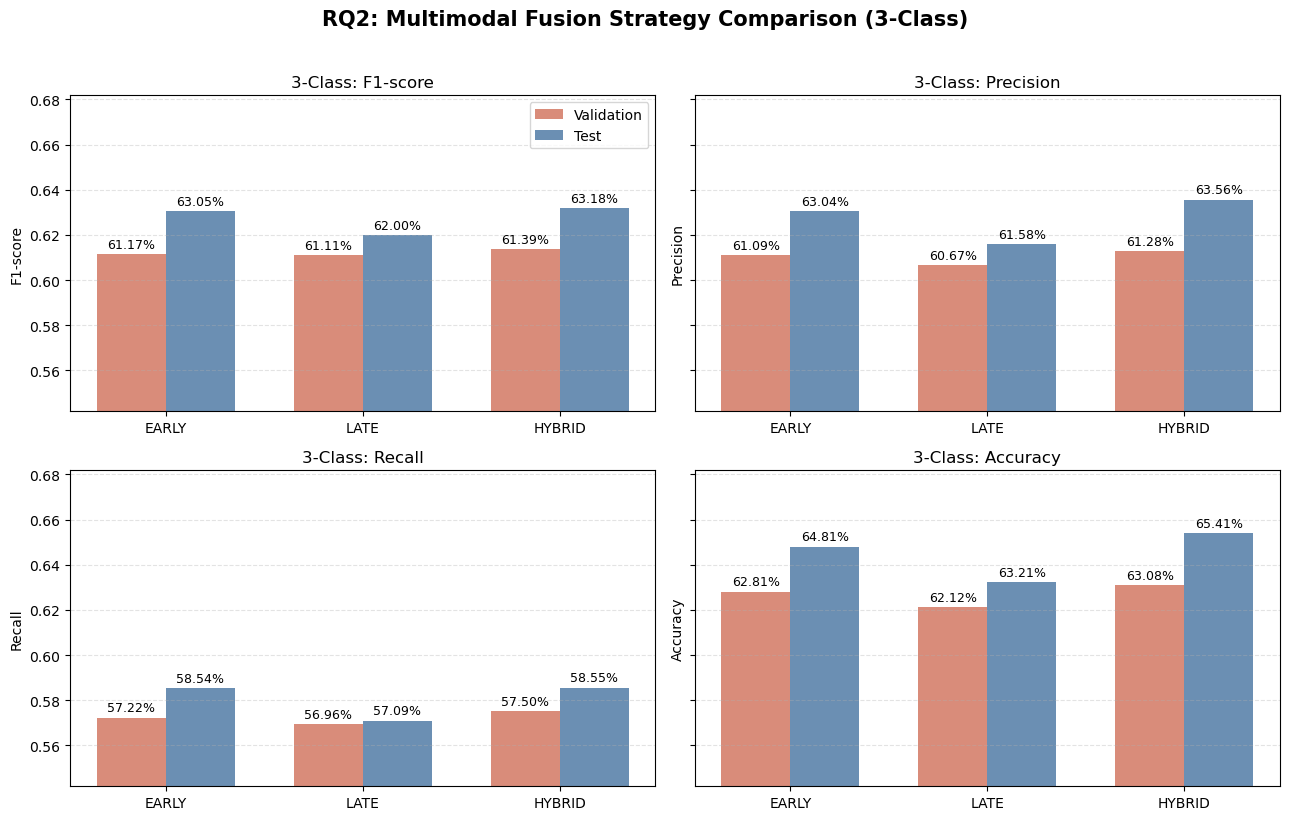

Saved: plots/k3_rq2_early_late_hybrid_metrics_panel.png


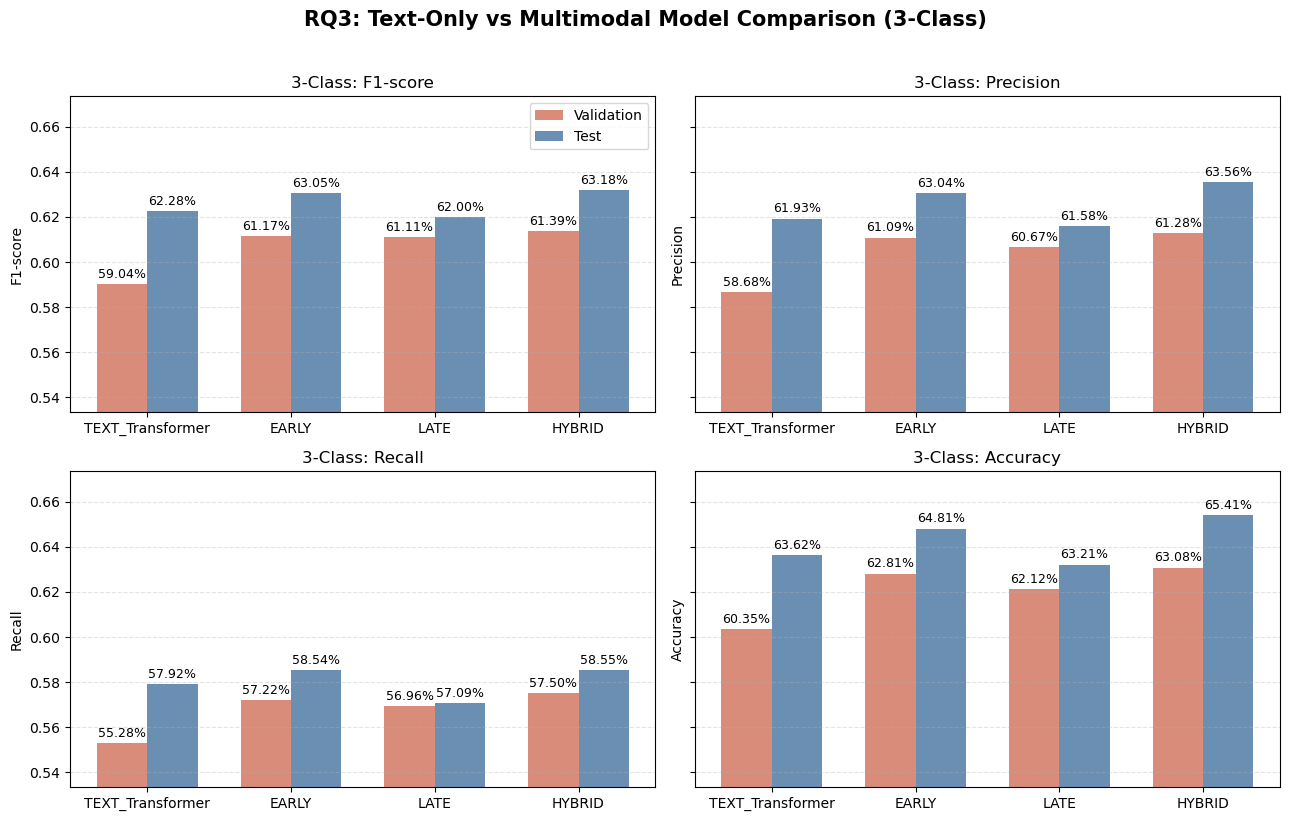

Saved: plots/k3_rq3_text_vs_multimodal_metrics_panel.png


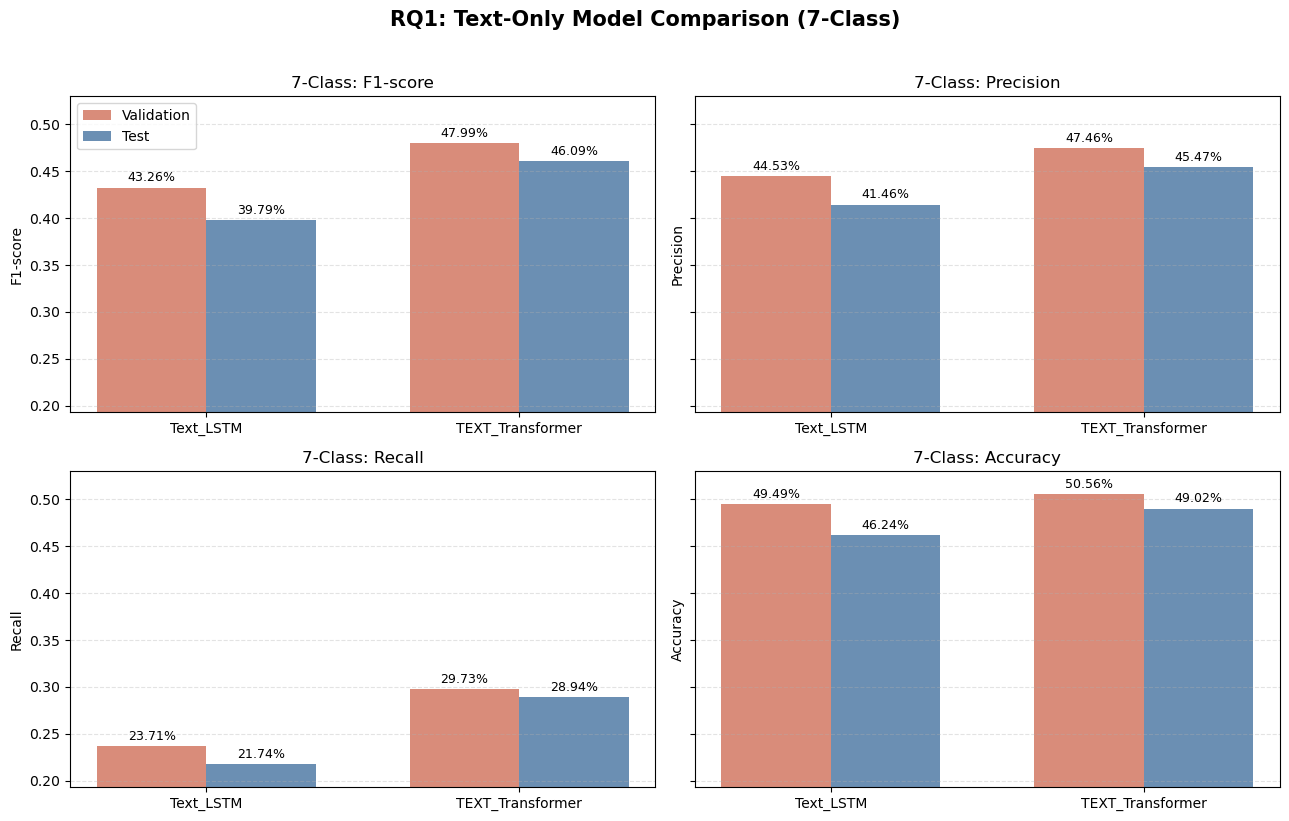

Saved: plots/k7_rq1_lstm_vs_text_transformer_metrics_panel.png


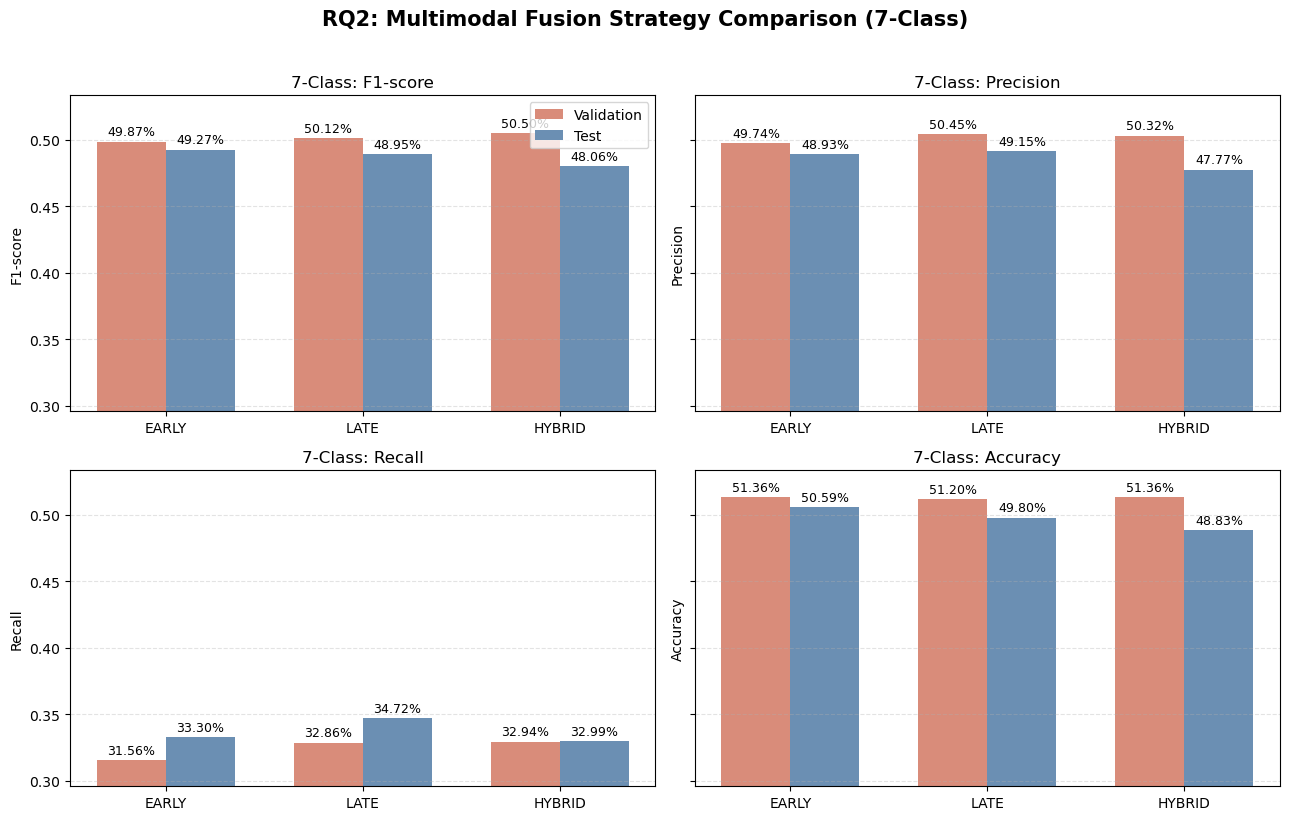

Saved: plots/k7_rq2_early_late_hybrid_metrics_panel.png


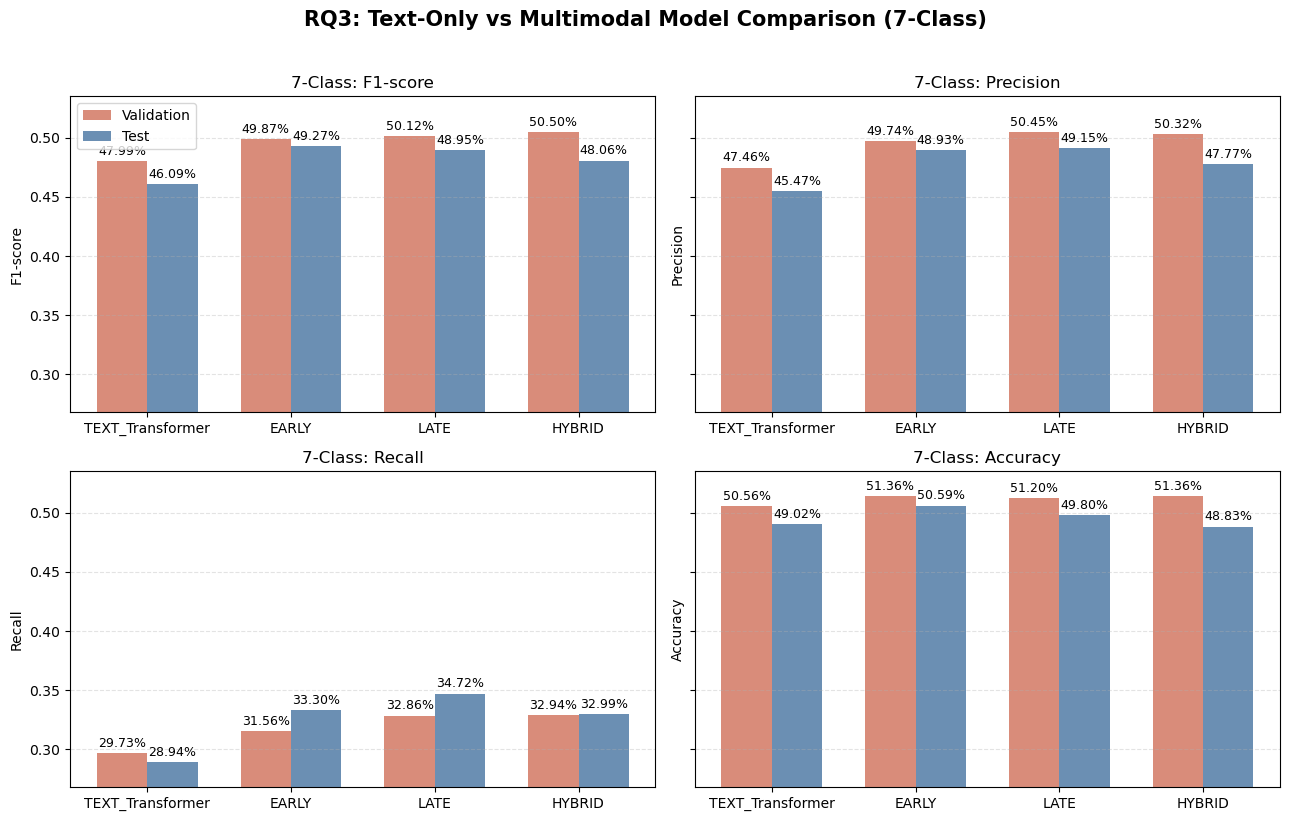

Saved: plots/k7_rq3_text_vs_multimodal_metrics_panel.png


In [46]:
# ============================================================
# This cell creates separate 2×2 grouped bar-chart panels for:
# RQ1: LSTM vs Text Transformer
# RQ2: Early vs Late vs Hybrid Fusion
# RQ3: Text Transformer vs Multimodal Models
# for the 2-class, 3-class, and 7-class settings.
# ============================================================

os.makedirs("plots", exist_ok=True)

# -----------------------------
# Settings
# -----------------------------
SCHEMES = [2, 3, 7]

# Same colors as your other figures
VAL_COLOR = "#D98C7A"   # coral
TEST_COLOR = "#6B8FB3"  # blue

MIN_RANGE = 0.12
EDGE_PAD = 0.01
REL_PAD = 0.05


# -----------------------------
# RQ-specific model groups
# -----------------------------
RQ_PLOTS = {
    "RQ1": {
        "title": "RQ1: Text-Only Model Comparison",
        "modes": ["text_lstm", "text_transformer"],
        "labels": ["Text_LSTM", "TEXT_Transformer"],
        "outfile_suffix": "rq1_lstm_vs_text_transformer"
    },
    "RQ2": {
        "title": "RQ2: Multimodal Fusion Strategy Comparison",
        "modes": ["early", "late", "hybrid"],
        "labels": ["EARLY", "LATE", "HYBRID"],
        "outfile_suffix": "rq2_early_late_hybrid"
    },
    "RQ3": {
        "title": "RQ3: Text-Only vs Multimodal Model Comparison",
        "modes": ["text_transformer", "early", "late", "hybrid"],
        "labels": ["TEXT_Transformer", "EARLY", "LATE", "HYBRID"],
        "outfile_suffix": "rq3_text_vs_multimodal"
    }
}


def load_scheme_results(label_scheme):
    """Load results for one label scheme."""
    if "all_scheme_results" in globals() and label_scheme in all_scheme_results:
        return all_scheme_results[label_scheme]["all_results"]

    fname = f"all_results_5models_{label_scheme}class.pkl"
    if not os.path.exists(fname):
        raise FileNotFoundError(
            f"Could not find {fname}. Run the main five-model comparison cell first."
        )

    with open(fname, "rb") as f:
        return pickle.load(f)


def compute_shared_ylims(*arrays):
    """Compute a shared y-axis range for one 2x2 panel."""
    vals = np.concatenate([np.asarray(a, dtype=float) for a in arrays])
    vmin, vmax = float(vals.min()), float(vals.max())
    span = vmax - vmin

    if span < MIN_RANGE:
        mid = (vmin + vmax) / 2.0
        lo = mid - MIN_RANGE / 2.0 - EDGE_PAD
        hi = mid + MIN_RANGE / 2.0 + EDGE_PAD
    else:
        pad = REL_PAD * span
        lo = vmin - pad - EDGE_PAD
        hi = vmax + pad + EDGE_PAD

    lo = max(0.0, lo)
    hi = min(1.0, hi)

    if hi - lo < 1e-6:
        lo = max(0.0, lo - 0.01)
        hi = min(1.0, hi + 0.01)

    return lo, hi


def plot_group(ax, val, test, title, ylabel, ylims, labels):
    """Plot grouped bars for validation and test metrics."""
    x = np.arange(len(labels))
    w = 0.35

    bars_val = ax.bar(
        x - w / 2,
        val,
        width=w,
        label="Validation",
        color=VAL_COLOR,
    )

    bars_test = ax.bar(
        x + w / 2,
        test,
        width=w,
        label="Test",
        color=TEST_COLOR,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0)
    ax.set_ylim(*ylims)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)

    y_range = ylims[1] - ylims[0]

    for bar, v in zip(bars_val, val):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + y_range * 0.01,
            f"{v * 100:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

    for bar, v in zip(bars_test, test):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + y_range * 0.01,
            f"{v * 100:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel)


def make_metric_panel(K, scheme_results, rq_key, rq_info):
    """Create one 2x2 metric panel for one RQ and one class scheme."""

    modes = rq_info["modes"]
    labels = rq_info["labels"]

    missing = [m for m in modes if m not in scheme_results]
    if missing:
        raise KeyError(
            f"The following modes are missing for the {K}-class results in {rq_key}: {missing}"
        )

    # -----------------------------
    # Validation metrics
    # -----------------------------
    vf1 = np.array([scheme_results[m]["val_f1"] for m in modes])
    vpr = np.array([scheme_results[m]["val_precision"] for m in modes])
    vrc = np.array([scheme_results[m]["val_recall"] for m in modes])
    vacc = np.array([scheme_results[m]["val_acc"] for m in modes])

    # -----------------------------
    # Test metrics
    # -----------------------------
    tf1 = np.array([scheme_results[m]["test_f1"] for m in modes])
    tpr = np.array([scheme_results[m]["test_precision"] for m in modes])
    trc = np.array([scheme_results[m]["test_recall"] for m in modes])
    tacc = np.array([scheme_results[m]["test_acc"] for m in modes])

    # Shared y-axis for all four panels
    ylims = compute_shared_ylims(vf1, vpr, vrc, vacc, tf1, tpr, trc, tacc)

    fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)

    plot_group(
        axes[0, 0],
        vf1,
        tf1,
        f"{K}-Class: F1-score",
        "F1-score",
        ylims,
        labels
    )

    plot_group(
        axes[0, 1],
        vpr,
        tpr,
        f"{K}-Class: Precision",
        "Precision",
        ylims,
        labels
    )

    plot_group(
        axes[1, 0],
        vrc,
        trc,
        f"{K}-Class: Recall",
        "Recall",
        ylims,
        labels
    )

    plot_group(
        axes[1, 1],
        vacc,
        tacc,
        f"{K}-Class: Accuracy",
        "Accuracy",
        ylims,
        labels
    )

    axes[0, 0].legend(loc="best")

    fig.suptitle(
        f"{rq_info['title']} ({K}-Class)",
        fontsize=15,
        fontweight="bold",
        y=1.02
    )

    fig.tight_layout()

    outfile = f"plots/k{K}_{rq_info['outfile_suffix']}_metrics_panel.png"
    fig.savefig(outfile, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved: {outfile}")


# -----------------------------
# Generate all RQ panels
# -----------------------------
for K in SCHEMES:
    scheme_results = load_scheme_results(K)

    for rq_key, rq_info in RQ_PLOTS.items():
        make_metric_panel(K, scheme_results, rq_key, rq_info)

## 10. Hybrid Ablation Study

This section presents additional experiments on the hybrid fusion model after the main five-model comparison. It includes modality ablation, architecture ablation, and a tuned Hybrid-TAV variant.

The ablation experiments cover:

- **Modality ablation:** `Hybrid-T`, `Hybrid-TA`, `Hybrid-TV`, `Hybrid-AV`, `Hybrid-TAV-Full`
- **Architecture ablation:** `Hybrid-NoEarly`, `Hybrid-NoLate`, `Hybrid-NoFusionAttn`, `Hybrid-ReducedDepth`
- **Tuned variant:** `Hybrid-TAV-Tuned`

### 10.1 Hybrid Ablation and Tuned Hybrid Model Definitions


This section  defines ablation variants of the hybrid model and a tuned Hybrid-TAV model for additional analysis.

In [49]:


class HybridFusionTransformerAblation(nn.Module):
    """Hybrid model with configurable modality and architecture ablations."""

    def __init__(
        self,
        dim_t, dim_a, dim_v, num_classes,
        d_model=192, nhead=6,
        late_layers=1, early_layers=2,
        dropout=0.3, max_len=128,
        modality_mask=(True, True, True),
        use_early_branch=True,
        use_late_branch=True,
        use_fusion_attn=True
    ):
        super().__init__()

        self.use_text, self.use_audio, self.use_vision = modality_mask
        self.use_early_branch = use_early_branch
        self.use_late_branch = use_late_branch
        self.use_fusion_attn = use_fusion_attn

        if not (self.use_text or self.use_audio or self.use_vision):
            raise ValueError("At least one modality must be enabled.")
        if not (self.use_early_branch or self.use_late_branch):
            raise ValueError("At least one branch must be enabled.")

        # Late encoders
        if self.use_text:
            self.enc_t = _TransformerEncoderBlock(dim_t, d_model, nhead, late_layers, dropout, max_len)
        if self.use_audio:
            self.enc_a = _TransformerEncoderBlock(dim_a, d_model, nhead, late_layers, dropout, max_len)
        if self.use_vision:
            self.enc_v = _TransformerEncoderBlock(dim_v, d_model, nhead, late_layers, dropout, max_len)

        # Early branch
        active_dim = sum([
            dim_t if self.use_text else 0,
            dim_a if self.use_audio else 0,
            dim_v if self.use_vision else 0,
        ])

        if self.use_early_branch:
            self.early_proj = nn.Linear(active_dim, d_model)
            self.pos = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)

            enc_layer = nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=d_model * 2,
                dropout=dropout,
                batch_first=True,
                activation="relu",
                norm_first=True
            )
            self.early_encoder = nn.TransformerEncoder(enc_layer, num_layers=early_layers)

        # Fusion attention
        if self.use_early_branch and self.use_late_branch and self.use_fusion_attn:
            self.fusion_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
            self.norm_attn = nn.LayerNorm(d_model)

        # FFN + head
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )
        self.norm_ff = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )

    @staticmethod
    def _pool(x):
        return 0.5 * (x.mean(dim=1) + x.amax(dim=1))

    def _build_active_inputs(self, t, a, v):
        xs = []
        if self.use_text: xs.append(t)
        if self.use_audio: xs.append(a)
        if self.use_vision: xs.append(v)
        return torch.cat(xs, dim=2)

    def forward(self, t, a, v):
        # Late branch
        if self.use_late_branch:
            tokens = []
            if self.use_text: tokens.append(self.enc_t(t))
            if self.use_audio: tokens.append(self.enc_a(a))
            if self.use_vision: tokens.append(self.enc_v(v))

            late_tokens = torch.stack(tokens, dim=1)
            late_pooled = late_tokens.mean(dim=1)
        else:
            late_tokens, late_pooled = None, None

        # Early branch
        if self.use_early_branch:
            x = self._build_active_inputs(t, a, v)
            B, T, _ = x.shape
            x = self.early_proj(x) + self.pos[:, :T, :]
            x = self.early_encoder(x)

            if self.use_late_branch and self.use_fusion_attn:
                attn_out, _ = self.fusion_attn(query=x, key=late_tokens, value=late_tokens)
                x = self.norm_attn(x + attn_out)

            x = self.norm_ff(x + self.ffn(x))
            early_pooled = self._pool(x)
        else:
            early_pooled = None

        # Combine
        if self.use_early_branch and self.use_late_branch:
            pooled = 0.5 * (early_pooled + late_pooled)
        elif self.use_early_branch:
            pooled = early_pooled
        else:
            pooled = late_pooled

        return self.head(self.dropout(pooled))


class HybridFusionTransformerTuned(nn.Module):
    """Tuned hybrid model with modality scaling and branch weighting."""

    def __init__(
        self,
        dim_t, dim_a, dim_v, num_classes,
        d_model=160, nhead=4,
        late_layers=2, early_layers=1,
        dropout=0.35, max_len=128,
        init_text_scale=1.0,
        init_audio_scale=1.0,
        init_vision_scale=0.5,
        init_late_weight=0.7,
        init_early_weight=0.3,
    ):
        super().__init__()

        self.enc_t = _TransformerEncoderBlock(dim_t, d_model, nhead, late_layers, dropout, max_len)
        self.enc_a = _TransformerEncoderBlock(dim_a, d_model, nhead, late_layers, dropout, max_len)
        self.enc_v = _TransformerEncoderBlock(dim_v, d_model, nhead, late_layers, dropout, max_len)

        self.early_proj = nn.Linear(dim_t + dim_a + dim_v, d_model)
        self.pos = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 2,
            dropout=dropout,
            batch_first=True,
            activation="relu",
            norm_first=True
        )
        self.early_encoder = nn.TransformerEncoder(enc_layer, num_layers=early_layers)

        self.fusion_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.norm_attn = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )
        self.norm_ff = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )

        # Learnable modality scales
        self.text_scale = nn.Parameter(torch.tensor(init_text_scale))
        self.audio_scale = nn.Parameter(torch.tensor(init_audio_scale))
        self.vision_scale = nn.Parameter(torch.tensor(init_vision_scale))

        # Learnable branch weights
        self.branch_logits = nn.Parameter(torch.log(torch.tensor([init_late_weight, init_early_weight])))

    @staticmethod
    def _pool(x):
        return 0.5 * (x.mean(dim=1) + x.amax(dim=1))

    def forward(self, t, a, v):
        # Scale modalities
        t = self.text_scale * t
        a = self.audio_scale * a
        v = self.vision_scale * v

        # Late branch
        t_tok = self.enc_t(t)
        a_tok = self.enc_a(a)
        v_tok = self.enc_v(v)

        late_tokens = torch.stack([t_tok, a_tok, v_tok], dim=1)
        late_pooled = late_tokens.mean(dim=1)

        # Early branch
        x = torch.cat([t, a, v], dim=2)
        B, T, _ = x.shape
        x = self.early_proj(x) + self.pos[:, :T, :]
        x = self.early_encoder(x)

        attn_out, _ = self.fusion_attn(query=x, key=late_tokens, value=late_tokens)
        x = self.norm_attn(x + attn_out)

        x = self.norm_ff(x + self.ffn(x))
        early_pooled = self._pool(x)

        # Weighted fusion
        weights = torch.softmax(self.branch_logits, dim=0)
        pooled = weights[0] * late_pooled + weights[1] * early_pooled

        return self.head(self.dropout(pooled))

### 10.2 Ablation Builder Functions

This section defines the builder functions for modality ablation, architecture ablation, and the tuned Hybrid-TAV variant.

In [51]:


def build_hybrid_ablation_full():
    """Build the full hybrid ablation model."""
    return HybridFusionTransformerAblation(
        dim_t, dim_a, dim_v, num_classes,
        d_model=192, nhead=6,
        late_layers=1, early_layers=2,
        dropout=0.3, max_len=128,
        modality_mask=(True, True, True),
        use_early_branch=True,
        use_late_branch=True,
        use_fusion_attn=True,
    )


# -----------------------------
# Modality ablations
# -----------------------------
def build_hybrid_ablation_T_only():
    """Build the text-only hybrid ablation variant."""
    return HybridFusionTransformerAblation(
        dim_t, dim_a, dim_v, num_classes,
        d_model=32, nhead=1,
        late_layers=1, early_layers=1,
        dropout=0.4, max_len=128,
        modality_mask=(True, False, False),
        use_early_branch=False,
        use_late_branch=True,
        use_fusion_attn=False,
    )


def build_hybrid_ablation_TA():
    """Build the text-audio hybrid ablation variant."""
    return HybridFusionTransformerAblation(
        dim_t, dim_a, dim_v, num_classes,
        d_model=192, nhead=6,
        late_layers=1, early_layers=2,
        dropout=0.3, max_len=128,
        modality_mask=(True, True, False),
        use_early_branch=True,
        use_late_branch=True,
        use_fusion_attn=True,
    )


def build_hybrid_ablation_TV():
    """Build the text-vision hybrid ablation variant."""
    return HybridFusionTransformerAblation(
        dim_t, dim_a, dim_v, num_classes,
        d_model=192, nhead=6,
        late_layers=1, early_layers=2,
        dropout=0.3, max_len=128,
        modality_mask=(True, False, True),
        use_early_branch=True,
        use_late_branch=True,
        use_fusion_attn=True,
    )


def build_hybrid_ablation_AV():
    """Build the audio-vision hybrid ablation variant."""
    return HybridFusionTransformerAblation(
        dim_t, dim_a, dim_v, num_classes,
        d_model=192, nhead=6,
        late_layers=1, early_layers=2,
        dropout=0.3, max_len=128,
        modality_mask=(False, True, True),
        use_early_branch=True,
        use_late_branch=True,
        use_fusion_attn=True,
    )


# -----------------------------
# Architecture ablations
# -----------------------------
def build_hybrid_ablation_no_early():
    """Build the no-early-branch variant."""
    return HybridFusionTransformerAblation(
        dim_t, dim_a, dim_v, num_classes,
        d_model=192, nhead=6,
        late_layers=1, early_layers=2,
        dropout=0.3, max_len=128,
        modality_mask=(True, True, True),
        use_early_branch=False,
        use_late_branch=True,
        use_fusion_attn=False,
    )


def build_hybrid_ablation_no_late():
    """Build the no-late-branch variant."""
    return HybridFusionTransformerAblation(
        dim_t, dim_a, dim_v, num_classes,
        d_model=192, nhead=6,
        late_layers=1, early_layers=2,
        dropout=0.3, max_len=128,
        modality_mask=(True, True, True),
        use_early_branch=True,
        use_late_branch=False,
        use_fusion_attn=False,
    )


def build_hybrid_ablation_no_fusion_attn():
    """Build the no-fusion-attention variant."""
    return HybridFusionTransformerAblation(
        dim_t, dim_a, dim_v, num_classes,
        d_model=192, nhead=6,
        late_layers=1, early_layers=2,
        dropout=0.3, max_len=128,
        modality_mask=(True, True, True),
        use_early_branch=True,
        use_late_branch=True,
        use_fusion_attn=False,
    )


def build_hybrid_ablation_reduced_depth():
    """Build the reduced-depth hybrid variant."""
    return HybridFusionTransformerAblation(
        dim_t, dim_a, dim_v, num_classes,
        d_model=192, nhead=6,
        late_layers=1, early_layers=1,
        dropout=0.3, max_len=128,
        modality_mask=(True, True, True),
        use_early_branch=True,
        use_late_branch=True,
        use_fusion_attn=True,
    )


# -----------------------------
# Tuned Hybrid-TAV
# -----------------------------
def build_hybrid_tav_tuned():
    """Build the tuned Hybrid-TAV variant."""
    return HybridFusionTransformerTuned(
        dim_t, dim_a, dim_v, num_classes,
        d_model=160,
        nhead=4,
        late_layers=2,
        early_layers=1,
        dropout=0.35,
        max_len=128,
        init_text_scale=1.0,
        init_audio_scale=1.0,
        init_vision_scale=0.5,
        init_late_weight=0.7,
        init_early_weight=0.3,
    )

### 10.3 Hybrid Ablation Experiment (Single Label Scheme)

This section runs the hybrid ablation experiment for one selected label scheme. It compares different modality combinations to examine how text, audio, and visual features contribute to the Hybrid Fusion model.

In [53]:


# -----------------------------
# Select label scheme
# -----------------------------
ABLATION_LABEL_SCHEME = 2  # change to 2, 3, or 7

# -----------------------------
# Rebuild labels
# -----------------------------
ab_y_tr = remap_labels_for_ce(
    derive_labels(y_tr_cont, ABLATION_LABEL_SCHEME),
    ABLATION_LABEL_SCHEME,
)
ab_y_va = remap_labels_for_ce(
    derive_labels(y_va_cont, ABLATION_LABEL_SCHEME),
    ABLATION_LABEL_SCHEME,
)
ab_y_te = remap_labels_for_ce(
    derive_labels(y_te_cont, ABLATION_LABEL_SCHEME),
    ABLATION_LABEL_SCHEME,
)

ab_num_classes = {2: 2, 3: 3, 7: 7}[ABLATION_LABEL_SCHEME]
ab_class_names = get_class_names(ABLATION_LABEL_SCHEME)

print(f"Running ablation ({ABLATION_LABEL_SCHEME}-class)")
print("Train label counts:", np.bincount(ab_y_tr, minlength=ab_num_classes))

# -----------------------------
# DataLoaders
# -----------------------------
ab_train_loader = DataLoader(
    MoseiDataset(TEXT_TR, AUDIO_TR, VISION_TR, ab_y_tr),
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
)

ab_valid_loader = DataLoader(
    MoseiDataset(TEXT_VA, AUDIO_VA, VISION_VA, ab_y_va),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)

ab_test_loader = DataLoader(
    MoseiDataset(TEXT_TE, AUDIO_TE, VISION_TE, ab_y_te),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)

# -----------------------------
# Switch output size temporarily
# -----------------------------
_original_num_classes = num_classes
num_classes = ab_num_classes

# -----------------------------
# Ablation models
# -----------------------------
ABLATION_MODELS = {
    "Hybrid-T": build_hybrid_ablation_T_only,
    "Hybrid-TA": build_hybrid_ablation_TA,
    "Hybrid-TV": build_hybrid_ablation_TV,
    "Hybrid-AV": build_hybrid_ablation_AV,
    "Hybrid-TAV-Full": build_hybrid_ablation_full,
    "Hybrid-NoEarly": build_hybrid_ablation_no_early,
    "Hybrid-NoLate": build_hybrid_ablation_no_late,
    "Hybrid-NoFusionAttn": build_hybrid_ablation_no_fusion_attn,
    "Hybrid-ReducedDepth": build_hybrid_ablation_reduced_depth,
}

# -----------------------------
# Training utilities
# -----------------------------
def get_logits_ablation(model, t, a, v):
    """Forward dispatch for ablation models."""
    if isinstance(model, (TextOnlyLSTM, TextTransformer)):
        return model(t)
    if isinstance(model, (HybridFusionTransformerAblation, HybridFusionTransformerTuned)):
        return model(t, a, v)
    return _get_logits(model, t, a, v)


def metrics_from_logits_ablation(logits, y_true_tensor):
    """Compute metrics from logits for the selected ablation scheme."""
    probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
    y_pred = probs.argmax(axis=1)
    y_true = y_true_tensor.detach().cpu().numpy()

    average_mode = "binary" if ab_num_classes == 2 else "weighted"

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average=average_mode, zero_division=0)
    recall = recall_score(y_true, y_pred, average=average_mode, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=average_mode, zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)

    return accuracy, precision, recall, f1, macro_f1, balanced_acc, y_true, y_pred


def run_epoch_ablation(model, loader, criterion, optimizer=None):
    """Run one epoch."""
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss = 0.0
    all_logits, all_y = [], []

    for t, a, v, y in loader:
        t, a, v, y = t.to(device), a.to(device), v.to(device), y.to(device)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train_mode):
            logits = get_logits_ablation(model, t, a, v)
            loss = criterion(logits, y)

            if train_mode:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()

        total_loss += loss.item() * y.size(0)
        all_logits.append(logits.detach().cpu())
        all_y.append(y.detach().cpu())

    return total_loss / len(loader.dataset), torch.cat(all_logits), torch.cat(all_y)


def fit_one_ablation(model_name, build_fn, seed=42):
    """Train one ablation model."""
    set_seed(seed)

    model = build_fn().to(device)
    params = count_params(model)

    criterion = nn.CrossEntropyLoss(label_smoothing=COMMON_LABEL_SMOOTHING)
    optimizer = optim.AdamW(
        model.parameters(),
        lr=COMMON_LR,
        weight_decay=COMMON_WEIGHT_DECAY,
    )

    best_state = None
    best_score = -1.0
    best_epoch = 0
    patience_count = 0
    epoch_times = []

    print(f"\n=== {model_name} ({ABLATION_LABEL_SCHEME}-class) ===")
    print(f"Params: {params:,}")

    for ep in range(1, EPOCHS + 1):
        start = time.time()

        tr_loss, tr_logits, tr_y = run_epoch_ablation(model, ab_train_loader, criterion, optimizer)
        va_loss, va_logits, va_y = run_epoch_ablation(model, ab_valid_loader, criterion)
        te_loss, te_logits, te_y = run_epoch_ablation(model, ab_test_loader, criterion)

        tr_acc, tr_prec, tr_rec, tr_f1, tr_macro, tr_bal, _, _ = metrics_from_logits_ablation(tr_logits, tr_y)
        va_acc, va_prec, va_rec, va_f1, va_macro, va_bal, _, _ = metrics_from_logits_ablation(va_logits, va_y)
        te_acc, te_prec, te_rec, te_f1, te_macro, te_bal, _, _ = metrics_from_logits_ablation(te_logits, te_y)

        epoch_times.append(time.time() - start)

        if SELECT_METRIC == "macro_f1":
            score = va_macro
        elif SELECT_METRIC == "balanced_accuracy":
            score = va_bal
        else:
            score = va_f1

        print(
            f"[{model_name}] Ep {ep:02d} | "
            f"TR acc {tr_acc:.3f} f1 {tr_f1:.3f} | "
            f"VA acc {va_acc:.3f} f1 {va_f1:.3f} macroF1 {va_macro:.3f} | "
            f"TE acc {te_acc:.3f} f1 {te_f1:.3f} macroF1 {te_macro:.3f}"
        )

        if score > best_score:
            best_score = score
            best_epoch = ep
            best_state = copy.deepcopy(model.state_dict())
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f"Early stopping at epoch {ep}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    _, va_logits, va_y = run_epoch_ablation(model, ab_valid_loader, criterion)
    _, te_logits, te_y = run_epoch_ablation(model, ab_test_loader, criterion)

    va_acc, va_prec, va_rec, va_f1, va_macro, va_bal, _, _ = metrics_from_logits_ablation(va_logits, va_y)
    te_acc, te_prec, te_rec, te_f1, te_macro, te_bal, _, _ = metrics_from_logits_ablation(te_logits, te_y)

    return {
        "mode": model_name,
        "params": params,
        "best_epoch": best_epoch,
        "val_acc": va_acc,
        "val_precision": va_prec,
        "val_recall": va_rec,
        "val_f1": va_f1,
        "val_macro_f1": va_macro,
        "val_bal_acc": va_bal,
        "test_acc": te_acc,
        "test_precision": te_prec,
        "test_recall": te_rec,
        "test_f1": te_f1,
        "test_macro_f1": te_macro,
        "test_bal_acc": te_bal,
        "mean_epoch_time_sec": float(np.mean(epoch_times)) if epoch_times else float("nan"),
    }


# -----------------------------
# Run all ablations
# -----------------------------
results = [fit_one_ablation(name, fn, RUN_SEED) for name, fn in ABLATION_MODELS.items()]

df_ablation_summary = pd.DataFrame(results)

print(f"\n=== Ablation Summary ({ABLATION_LABEL_SCHEME}-class) ===")
display(df_ablation_summary.sort_values("test_macro_f1", ascending=False))

df_ablation_summary.to_csv(
    f"hybrid_ablation_summary_{ABLATION_LABEL_SCHEME}class.csv",
    index=False,
)

print(f"Saved: hybrid_ablation_summary_{ABLATION_LABEL_SCHEME}class.csv")

# Restore original setting
num_classes = _original_num_classes

Running ablation (2-class)
Train label counts: [ 4721 11544]

=== Hybrid-T (2-class) ===
Params: 27,714
[Hybrid-T] Ep 01 | TR acc 0.656 f1 0.776 | VA acc 0.761 f1 0.853 macroF1 0.605 | TE acc 0.751 f1 0.847 macroF1 0.597
[Hybrid-T] Ep 02 | TR acc 0.731 f1 0.827 | VA acc 0.785 f1 0.859 macroF1 0.702 | TE acc 0.773 f1 0.848 macroF1 0.699
[Hybrid-T] Ep 03 | TR acc 0.762 f1 0.842 | VA acc 0.789 f1 0.860 macroF1 0.713 | TE acc 0.793 f1 0.861 macroF1 0.727
[Hybrid-T] Ep 04 | TR acc 0.779 f1 0.852 | VA acc 0.793 f1 0.863 macroF1 0.721 | TE acc 0.794 f1 0.861 macroF1 0.732
[Hybrid-T] Ep 05 | TR acc 0.785 f1 0.855 | VA acc 0.799 f1 0.868 macroF1 0.723 | TE acc 0.793 f1 0.861 macroF1 0.727
[Hybrid-T] Ep 06 | TR acc 0.793 f1 0.860 | VA acc 0.801 f1 0.869 macroF1 0.727 | TE acc 0.796 f1 0.863 macroF1 0.732
[Hybrid-T] Ep 07 | TR acc 0.796 f1 0.862 | VA acc 0.806 f1 0.873 macroF1 0.733 | TE acc 0.799 f1 0.866 macroF1 0.733
[Hybrid-T] Ep 08 | TR acc 0.797 f1 0.862 | VA acc 0.808 f1 0.874 macroF1 0.73

,mode,params,best_epoch,val_acc,val_precision,val_recall,val_f1,val_macro_f1,val_bal_acc,test_acc,test_precision,test_recall,test_f1,test_macro_f1,test_bal_acc,mean_epoch_time_sec
1,Hybrid-TA,1741250,4,0.806314,0.853315,0.887097,0.869878,0.745608,0.737608,0.812621,0.848450,0.896301,0.871719,0.762138,0.751868,171.799130
4,Hybrid-TAV-Full,2076866,5,0.807384,0.855021,0.886364,0.870410,0.747705,0.740212,0.807452,0.841283,0.898423,0.868915,0.753192,0.741405,209.584744
2,Hybrid-TV,1726274,3,0.805243,0.868189,0.864370,0.866275,0.754004,0.754957,0.797114,0.855676,0.859309,0.857489,0.752735,0.751959,171.518379
5,Hybrid-NoEarly,1230914,9,0.808989,0.850871,0.895161,0.872454,0.746131,0.735699,0.805083,0.842935,0.891753,0.866657,0.752256,0.742159,116.732302
6,Hybrid-NoLate,1928258,2,0.806314,0.851332,0.890029,0.870251,0.744197,0.735114,0.802929,0.838783,0.894482,0.865737,0.747721,0.736460,91.935729
7,Hybrid-NoFusionAttn,1928258,4,0.801498,0.850883,0.882698,0.866499,0.739819,0.732438,0.799914,0.841060,0.885688,0.862797,0.746707,0.737640,209.979682
8,Hybrid-ReducedDepth,1779842,3,0.815409,0.845893,0.913490,0.878393,0.747742,0.731992,0.806160,0.831033,0.912674,0.869942,0.744777,0.728828,179.846946
0,Hybrid-T,27714,9,0.804173,0.841781,0.901026,0.870397,0.734979,0.721800,0.799914,0.830589,0.902365,0.864991,0.739356,0.725532,8.004654
3,Hybrid-AV,1639490,7,0.700910,0.783251,0.815982,0.799282,0.606357,0.603041,0.700840,0.774834,0.815949,0.794860,0.621287,0.617268,171.292650


Saved: hybrid_ablation_summary_2class.csv


### 10.4 RQ4: Ablation Study (Table 4.4 and Figure 4.7)

This section presents the ablation study results for the Hybrid Fusion model. It compares different modality combinations to identify the contribution of text, audio, and visual features to sentiment classification performance.

Table 4.4: Ablation Results for Modality Contribution (2-Class)


Variant,Modalities Used,Parameters,Val F1,Val Macro-F1,Test F1,Test Macro-F1
Hybrid-T,Text,27714,87.04%,73.50%,86.50%,73.94%
Hybrid-TA,Text + Audio,1741250,86.99%,74.56%,87.17%,76.21%
Hybrid-TV,Text + Vision,1726274,86.63%,75.40%,85.75%,75.27%
Hybrid-AV,Audio + Vision,1639490,79.93%,60.64%,79.49%,62.13%
Hybrid-TAV-Full,Text + Audio + Vision,2076866,87.04%,74.77%,86.89%,75.32%


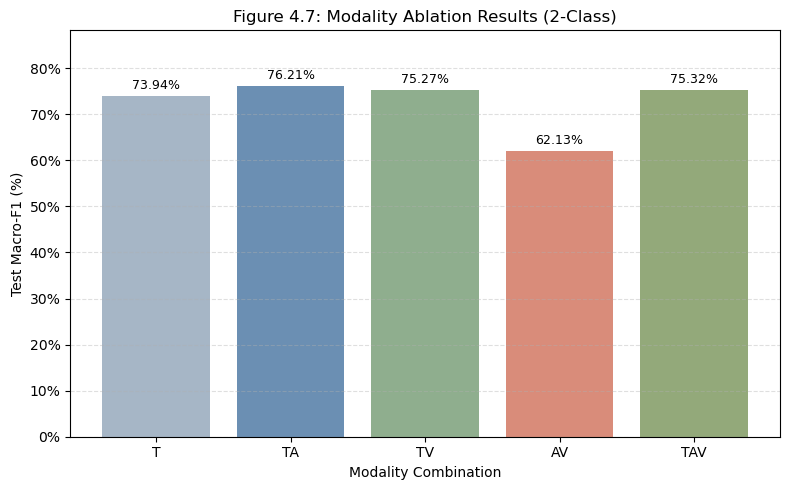

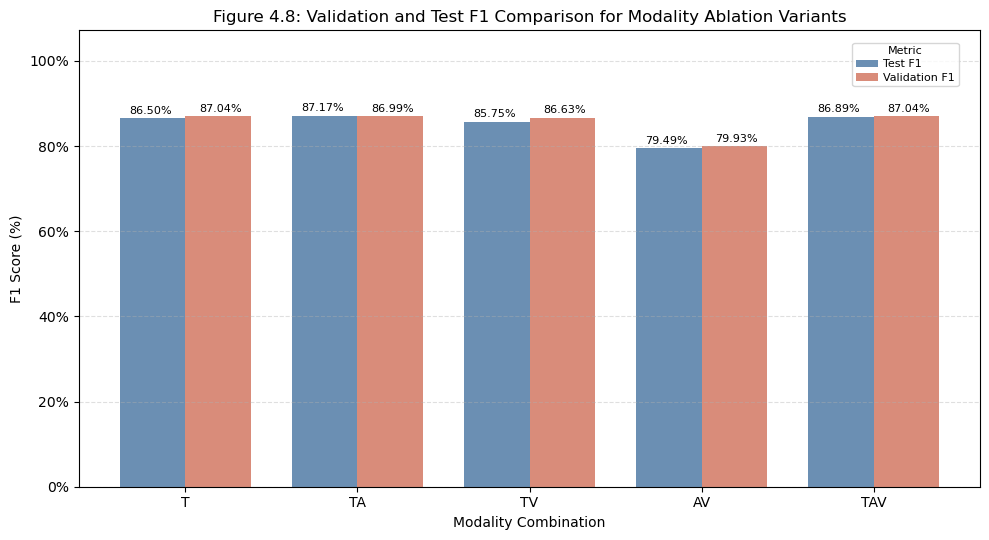

Saved:
 - Table_4_4_Ablation_2class.csv
 - Figure_4_7_Ablation.png
 - Figure_4_8_Ablation_Val_vs_Test_F1.png

Final Table 4.4 columns:
['Variant', 'Modalities Used', 'Parameters', 'Val F1', 'Val Macro-F1', 'Test F1', 'Test Macro-F1']


In [55]:

# -----------------------------
# File path
# -----------------------------
ablation_file = "hybrid_ablation_summary_2class.csv"

if not os.path.exists(ablation_file):
    raise FileNotFoundError(
        f"Cannot find {ablation_file}. Run the ablation experiment first."
    )

# -----------------------------
# Colors (consistent style)
# -----------------------------
t_color  = "#A6B6C6"
ta_color = "#6B8FB3"
tv_color = "#8FAE8E"
av_color = "#D98C7A"
tav_color = "#93A97A"

test_color = "#6B8FB3"
val_color = "#D98C7A"

bar_colors = [t_color, ta_color, tv_color, av_color, tav_color]

# -----------------------------
# Load data
# -----------------------------
df_ab = pd.read_csv(ablation_file)

if "Unnamed: 0" in df_ab.columns and "mode" not in df_ab.columns:
    df_ab = df_ab.rename(columns={"Unnamed: 0": "mode"})

if "mode" not in df_ab.columns:
    raise KeyError(f"'mode' column not found in {ablation_file}")

# -----------------------------
# Select main modality variants
# -----------------------------
main_modes = [
    "Hybrid-T",
    "Hybrid-TA",
    "Hybrid-TV",
    "Hybrid-AV",
    "Hybrid-TAV-Full",
]

df_main = df_ab[df_ab["mode"].isin(main_modes)].copy()

mode_order = {m: i for i, m in enumerate(main_modes)}
df_main["order"] = df_main["mode"].map(mode_order)
df_main = df_main.sort_values("order").reset_index(drop=True)

# -----------------------------
# Table 4.4
# -----------------------------
modality_map = {
    "Hybrid-T": "Text",
    "Hybrid-TA": "Text + Audio",
    "Hybrid-TV": "Text + Vision",
    "Hybrid-AV": "Audio + Vision",
    "Hybrid-TAV-Full": "Text + Audio + Vision",
}

table_4_4 = pd.DataFrame({
    "Variant": df_main["mode"],
    "Modalities Used": df_main["mode"].map(modality_map),
    "Parameters": df_main["params"],
    "Val F1": df_main["val_f1"],
    "Val Macro-F1": df_main["val_macro_f1"],
    "Test F1": df_main["test_f1"],
    "Test Macro-F1": df_main["test_macro_f1"],
})

numeric_cols = [
    "Val F1",
    "Val Macro-F1",
    "Test F1",
    "Test Macro-F1",
]

table_display = table_4_4.copy()

for col in numeric_cols:
    table_display[col] = (
        table_display[col] * 100
    ).round(2).map(lambda x: f"{x:.2f}%")

table_display["Parameters"] = table_display["Parameters"].astype(int)

styles = pd.DataFrame(
    "",
    index=table_display.index,
    columns=table_display.columns
)

for col in numeric_cols:
    best = table_4_4[col].max()
    for i in table_4_4.index[table_4_4[col] == best]:
        styles.loc[i, col] = "font-weight: bold;"

print("Table 4.4: Ablation Results for Modality Contribution (2-Class)")

display(
    table_display.style
    .hide(axis="index")
    .set_caption("Table 4.4: Ablation Results for Modality Contribution (2-Class)")
    .set_properties(subset=["Variant", "Modalities Used"], **{
        "text-align": "center",
        "white-space": "nowrap"
    })
    .set_properties(
        subset=[c for c in table_display.columns if c not in ["Variant", "Modalities Used"]],
        **{
            "text-align": "center",
            "white-space": "nowrap"
        }
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("margin-bottom", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
                ("border-bottom", "1.5px solid black"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "8px")
            ]
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "0 auto"),
                ("font-size", "14px")
            ]
        }
    ])
    .apply(lambda _: styles, axis=None)
)

table_display.to_csv("Table_4_4_Ablation_2class.csv", index=False)

# -----------------------------
# Figure 4.7
# Test Macro-F1
# -----------------------------
labels = ["T", "TA", "TV", "AV", "TAV"]
macro_f1_vals = df_main["test_macro_f1"].values

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    labels,
    macro_f1_vals,
    color=bar_colors
)

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.008,
        f"{h * 100:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_ylabel("Test Macro-F1 (%)")
ax.set_xlabel("Modality Combination")
ax.set_title("Figure 4.7: Modality Ablation Results (2-Class)")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylim(0, max(macro_f1_vals) + 0.12)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("Figure_4_7_Ablation.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Figure 4.8
# Validation and Test F1
# -----------------------------
plot_f1 = df_main[["mode", "val_f1", "test_f1"]].copy()

plot_f1["Short"] = plot_f1["mode"].map({
    "Hybrid-T": "T",
    "Hybrid-TA": "TA",
    "Hybrid-TV": "TV",
    "Hybrid-AV": "AV",
    "Hybrid-TAV-Full": "TAV",
})

fig, ax = plt.subplots(figsize=(10, 5.5))

x = np.arange(len(plot_f1))
width = 0.38

bars1 = ax.bar(
    x - width / 2,
    plot_f1["test_f1"],
    width,
    label="Test F1",
    color=test_color
)

bars2 = ax.bar(
    x + width / 2,
    plot_f1["val_f1"],
    width,
    label="Validation F1",
    color=val_color
)

top_lim = max(plot_f1[["val_f1", "test_f1"]].max()) + 0.20

ax.set_title("Figure 4.8: Validation and Test F1 Comparison for Modality Ablation Variants")
ax.set_xlabel("Modality Combination")
ax.set_ylabel("F1 Score (%)")
ax.set_xticks(x)
ax.set_xticklabels(plot_f1["Short"], rotation=0)
ax.set_ylim(0, top_lim)
ax.grid(axis="y", linestyle="--", alpha=0.4)

ax.legend(
    title="Metric",
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    fontsize=8,
    title_fontsize=8,
    frameon=True,
    borderpad=0.3,
    labelspacing=0.3,
    handletextpad=0.5,
    borderaxespad=0.3,
)

ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))

for bar in bars1:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2 - 0.015,
        h + 0.006,
        f"{h * 100:.2f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

for bar in bars2:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2 + 0.015,
        h + 0.006,
        f"{h * 100:.2f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.savefig("Figure_4_8_Ablation_Val_vs_Test_F1.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:")
print(" - Table_4_4_Ablation_2class.csv")
print(" - Figure_4_7_Ablation.png")
print(" - Figure_4_8_Ablation_Val_vs_Test_F1.png")

# -----------------------------
# Check final table columns
# -----------------------------
print("\nFinal Table 4.4 columns:")
print(table_display.columns.tolist())

### 10.5 Tuned Hybrid-TAV Variant

This cell runs the tuned Hybrid-TAV ablation variant, displays its summary results, and compares it with selected reference variants from the earlier ablation study. It helps assess whether the tuned full hybrid model improves over simpler modality combinations.

In [57]:


# Temporarily switch global num_classes to the ablation scheme
_original_num_classes_tmp = num_classes
num_classes = ab_num_classes

tuned_summary = fit_one_ablation(
    model_name="Hybrid-TAV-Tuned",
    build_fn=build_hybrid_tav_tuned,
    seed=RUN_SEED,
)

# Restore original num_classes
num_classes = _original_num_classes_tmp

df_tuned_summary = pd.DataFrame([tuned_summary])
display(df_tuned_summary)

if "df_ablation_summary" in globals():
    compare_cols = [
        "mode",
        "params",
        "best_epoch",
        "val_macro_f1",
        "test_macro_f1",
        "test_bal_acc",
        "mean_epoch_time_sec",
    ]

    reference_modes = ["Hybrid-T", "Hybrid-TA", "Hybrid-TAV-Full"]

    compare_df = pd.concat(
        [
            df_ablation_summary[df_ablation_summary["mode"].isin(reference_modes)][compare_cols],
            df_tuned_summary[compare_cols],
        ],
        ignore_index=True,
    ).sort_values("test_macro_f1", ascending=False)

    print(f"=== Reference Comparison ({ABLATION_LABEL_SCHEME}-class) ===")
    print("Hybrid-T vs Hybrid-TA vs Hybrid-TAV-Full vs Hybrid-TAV-Tuned")
    display(compare_df)


=== Hybrid-TAV-Tuned (2-class) ===
Params: 1,892,967
[Hybrid-TAV-Tuned] Ep 01 | TR acc 0.760 f1 0.846 | VA acc 0.755 f1 0.823 macroF1 0.712 | TE acc 0.781 f1 0.839 macroF1 0.749
[Hybrid-TAV-Tuned] Ep 02 | TR acc 0.805 f1 0.868 | VA acc 0.793 f1 0.860 macroF1 0.733 | TE acc 0.802 f1 0.863 macroF1 0.755
[Hybrid-TAV-Tuned] Ep 03 | TR acc 0.818 f1 0.877 | VA acc 0.799 f1 0.864 macroF1 0.739 | TE acc 0.802 f1 0.863 macroF1 0.751
[Hybrid-TAV-Tuned] Ep 04 | TR acc 0.826 f1 0.882 | VA acc 0.803 f1 0.867 macroF1 0.743 | TE acc 0.801 f1 0.862 macroF1 0.751
[Hybrid-TAV-Tuned] Ep 05 | TR acc 0.834 f1 0.887 | VA acc 0.802 f1 0.867 macroF1 0.740 | TE acc 0.808 f1 0.868 macroF1 0.757
[Hybrid-TAV-Tuned] Ep 06 | TR acc 0.842 f1 0.892 | VA acc 0.789 f1 0.853 macroF1 0.739 | TE acc 0.796 f1 0.856 macroF1 0.754
[Hybrid-TAV-Tuned] Ep 07 | TR acc 0.850 f1 0.897 | VA acc 0.810 f1 0.877 macroF1 0.728 | TE acc 0.811 f1 0.876 macroF1 0.741
[Hybrid-TAV-Tuned] Ep 08 | TR acc 0.861 f1 0.904 | VA acc 0.804 f1 0.87

,mode,params,best_epoch,val_acc,val_precision,val_recall,val_f1,val_macro_f1,val_bal_acc,test_acc,test_precision,test_recall,test_f1,test_macro_f1,test_bal_acc,mean_epoch_time_sec
0,Hybrid-TAV-Tuned,1892967,4,0.802568,0.854093,0.879765,0.866739,0.742967,0.736912,0.80056,0.846379,0.878714,0.862243,0.750544,0.743818,229.16624


=== Reference Comparison (2-class) ===
Hybrid-T vs Hybrid-TA vs Hybrid-TAV-Full vs Hybrid-TAV-Tuned


,mode,params,best_epoch,val_macro_f1,test_macro_f1,test_bal_acc,mean_epoch_time_sec
1,Hybrid-TA,1741250,4,0.745608,0.762138,0.751868,171.799130
2,Hybrid-TAV-Full,2076866,5,0.747705,0.753192,0.741405,209.584744
3,Hybrid-TAV-Tuned,1892967,4,0.742967,0.750544,0.743818,229.166240
0,Hybrid-T,27714,9,0.734979,0.739356,0.725532,8.004654


### 11. RQ5: Complexity vs Performance (Table 4.5 and Figures 4.8–4.10)

This cell analyses how model complexity relates to predictive performance across the main multimodal transformer architectures. It compares parameter count, training time, and test performance, and creates simple tables and plots to support the discussion of RQ5.

Table 4.5: Complexity and Performance Comparison in the 7-Class Setting


Model,Parameters,Test Accuracy,Test F1,Test Macro-F1
LSTM,94151,46.24%,39.79%,21.43%
Text Transformer,65671,49.02%,46.09%,28.69%
Early Fusion,736135,50.59%,49.27%,34.79%
Late Fusion,2085898,49.80%,48.95%,36.30%
Hybrid Fusion,2077831,48.83%,48.06%,34.28%


Saved:
 - Table_4_5_Complexity_Performance.csv
 - Table_4_5_Complexity_Performance.xlsx


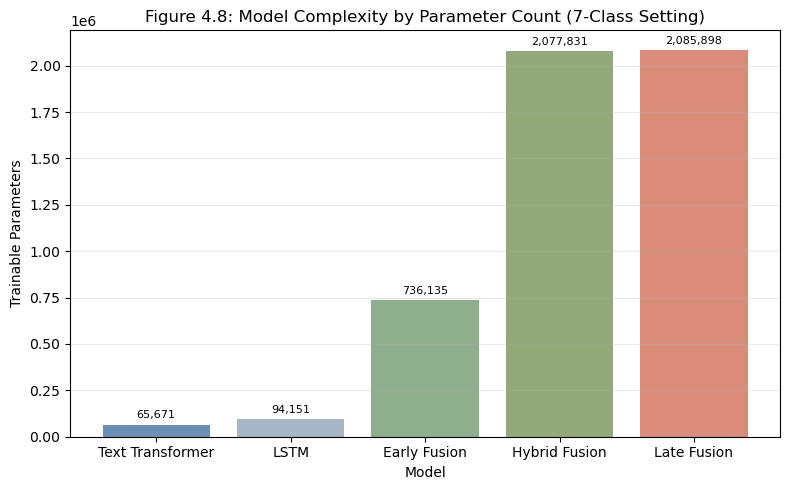

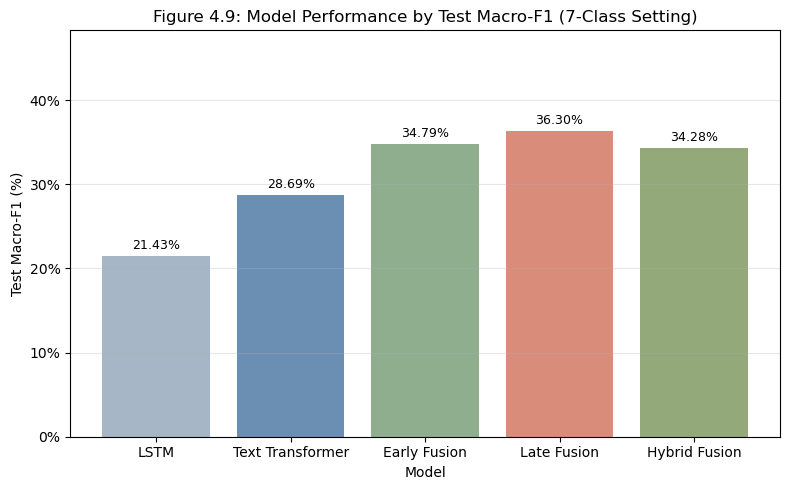

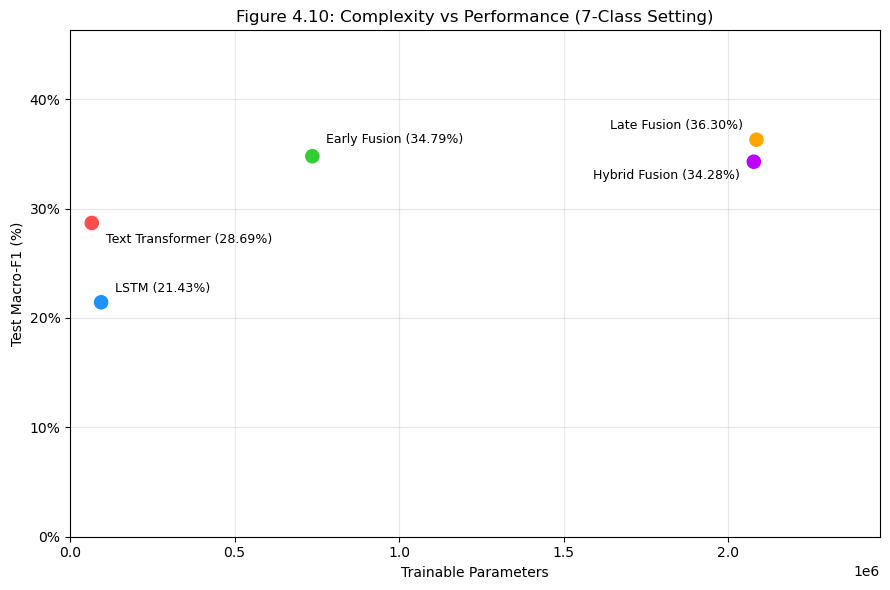

Saved:
 - plots/Figure_4_8_Params_7class.png
 - plots/Figure_4_9_MacroF1_7class.png
 - plots/Figure_4_10_Params_vs_MacroF1_7class.png

Final Table 4.5 columns:
['Model', 'Parameters', 'Test Accuracy', 'Test F1', 'Test Macro-F1']


In [59]:


LABEL_SCHEME = 7  # change if needed
os.makedirs("plots", exist_ok=True)

# -----------------------------
# Load saved RQ5 results
# -----------------------------
csv_path = f"results_rq5_complexity_performance_{LABEL_SCHEME}class.csv"

if not os.path.exists(csv_path):
    raise FileNotFoundError(
        f"Cannot find {csv_path}. "
        "Please run the original RQ5 cell once, or make sure the CSV is in the current folder."
    )

df_rq5 = pd.read_csv(csv_path)

# -----------------------------
# Cleaner names
# -----------------------------
display_name_map = {
    "text_lstm": "LSTM",
    "text_transformer": "Text Transformer",
    "early": "Early Fusion",
    "late": "Late Fusion",
    "hybrid": "Hybrid Fusion",
}

df_rq5["Model"] = df_rq5["mode"].map(display_name_map).fillna(df_rq5["mode"])

# -----------------------------
# Sort for table display
# -----------------------------
mode_order = ["text_lstm", "text_transformer", "early", "late", "hybrid"]

df_rq5["mode"] = pd.Categorical(
    df_rq5["mode"],
    categories=mode_order,
    ordered=True
)

df_rq5 = df_rq5.sort_values("mode").reset_index(drop=True)

# ============================================================
# Table 4.5
# ============================================================
table_4_5 = pd.DataFrame({
    "Model": df_rq5["Model"],
    "Parameters": df_rq5["params"],
    "Test Accuracy": df_rq5["test_acc"],
    "Test F1": df_rq5["test_f1"],
    "Test Macro-F1": df_rq5["test_macro_f1"],
})

if "mean_epoch_time_sec" in df_rq5.columns:
    table_4_5["Mean Epoch Time (s)"] = df_rq5["mean_epoch_time_sec"]

# Keep numeric copy for highlighting
table_4_5_numeric = table_4_5.copy()

# Display copy
table_4_5_display = table_4_5.copy()

# Format percentage columns
percent_cols = [
    "Test Accuracy",
    "Test F1",
    "Test Macro-F1",
]

for col in percent_cols:
    if col in table_4_5_display.columns:
        table_4_5_display[col] = (
            table_4_5_display[col] * 100
        ).round(2).map(lambda x: f"{x:.2f}%")

if "Mean Epoch Time (s)" in table_4_5_display.columns:
    table_4_5_display["Mean Epoch Time (s)"] = (
        table_4_5_display["Mean Epoch Time (s)"].round(4)
    )

# Highlight best values
styles = pd.DataFrame(
    "",
    index=table_4_5_display.index,
    columns=table_4_5_display.columns
)

highlight_cols = [
    "Test Accuracy",
    "Test F1",
    "Test Macro-F1",
]

for col in highlight_cols:
    if col in table_4_5_numeric.columns:
        max_val = table_4_5_numeric[col].max()
        winners = table_4_5_numeric[col] == max_val

        for row_idx in table_4_5_numeric.index[winners]:
            styles.loc[row_idx, col] = "font-weight: bold;"

# Highlight minimum parameters and minimum time
if "Parameters" in table_4_5_numeric.columns:
    min_val = table_4_5_numeric["Parameters"].min()
    winners = table_4_5_numeric["Parameters"] == min_val

    for row_idx in table_4_5_numeric.index[winners]:
        styles.loc[row_idx, "Parameters"] = "font-weight: bold;"

if "Mean Epoch Time (s)" in table_4_5_numeric.columns:
    min_val = table_4_5_numeric["Mean Epoch Time (s)"].min()
    winners = table_4_5_numeric["Mean Epoch Time (s)"] == min_val

    for row_idx in table_4_5_numeric.index[winners]:
        styles.loc[row_idx, "Mean Epoch Time (s)"] = "font-weight: bold;"

print(f"Table 4.5: Complexity and Performance Comparison in the {LABEL_SCHEME}-Class Setting")

styled_table_4_5 = (
    table_4_5_display.style
    .hide(axis="index")
    .set_caption(
        f"Table 4.5: Complexity and Performance Comparison in the {LABEL_SCHEME}-Class Setting"
    )
    .set_properties(subset=["Model"], **{
        "text-align": "center",
        "white-space": "nowrap"
    })
    .set_properties(
        subset=[c for c in table_4_5_display.columns if c != "Model"],
        **{
            "text-align": "center",
            "white-space": "nowrap"
        }
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("margin-bottom", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
                ("border-bottom", "1.5px solid black"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "8px")
            ]
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "0 auto"),
                ("font-size", "14px")
            ]
        }
    ])
    .apply(lambda _: styles, axis=None)
)

display(styled_table_4_5)

table_4_5_display.to_csv("Table_4_5_Complexity_Performance.csv", index=False)
table_4_5_display.to_excel("Table_4_5_Complexity_Performance.xlsx", index=False)

print("Saved:")
print(" - Table_4_5_Complexity_Performance.csv")
print(" - Table_4_5_Complexity_Performance.xlsx")

# -----------------------------
# Colors for bar charts
# -----------------------------
color_map = {
    "LSTM": "#A6B6C6",
    "Text Transformer": "#6B8FB3",
    "Early Fusion": "#8FAE8E",
    "Late Fusion": "#D98C7A",
    "Hybrid Fusion": "#93A97A",
}

bar_colors = [color_map.get(m, "#6B8FB3") for m in df_rq5["Model"]]

# -----------------------------
# Helper function
# -----------------------------
def add_bar_labels(ax, bars, labels, y_offset_frac=0.01, fontsize=9):
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min

    for bar, label in zip(bars, labels):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + y_range * y_offset_frac,
            label,
            ha="center",
            va="bottom",
            fontsize=fontsize,
        )

# ============================================================
# Figure 4.8: Parameter count
# ============================================================
df_rq5_eff = df_rq5.sort_values(
    ["params", "test_macro_f1"],
    ascending=[True, False]
).copy()

fig, ax = plt.subplots(figsize=(8, 5))

x_labels_params = df_rq5_eff["Model"].tolist()

bars = ax.bar(
    x_labels_params,
    df_rq5_eff["params"],
    color=[color_map.get(m, "#6B8FB3") for m in x_labels_params]
)

ax.set_title(
    f"Figure 4.8: Model Complexity by Parameter Count ({LABEL_SCHEME}-Class Setting)"
)
ax.set_xlabel("Model")
ax.set_ylabel("Trainable Parameters")
ax.grid(axis="y", alpha=0.3)

param_labels = [f"{int(v):,}" for v in df_rq5_eff["params"]]

add_bar_labels(
    ax,
    bars,
    param_labels,
    y_offset_frac=0.01,
    fontsize=8
)

plt.tight_layout()
plt.savefig(
    f"plots/Figure_4_8_Params_{LABEL_SCHEME}class.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# Figure 4.9: Test Macro-F1
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

x_labels_perf = df_rq5["Model"].tolist()

bars = ax.bar(
    x_labels_perf,
    df_rq5["test_macro_f1"],
    color=bar_colors
)

ax.set_title(
    f"Figure 4.9: Model Performance by Test Macro-F1 ({LABEL_SCHEME}-Class Setting)"
)
ax.set_xlabel("Model")
ax.set_ylabel("Test Macro-F1 (%)")
ax.set_ylim(0, max(df_rq5["test_macro_f1"]) + 0.12)
ax.grid(axis="y", alpha=0.3)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))

macro_labels = [f"{v * 100:.2f}%" for v in df_rq5["test_macro_f1"]]

add_bar_labels(
    ax,
    bars,
    macro_labels,
    y_offset_frac=0.01,
    fontsize=9
)

plt.tight_layout()
plt.savefig(
    f"plots/Figure_4_9_MacroF1_{LABEL_SCHEME}class.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# Figure 4.10: Parameters vs Test Macro-F1
# ============================================================
fig, ax = plt.subplots(figsize=(9, 6))

# Bright different colors for points
point_color_map = {
    "LSTM": "#1E90FF",              # bright blue
    "Text Transformer": "#FF4D4D", # bright red
    "Early Fusion": "#32CD32",     # bright green
    "Late Fusion": "#FFA500",      # bright orange
    "Hybrid Fusion": "#C000FF",    # bright purple
}

point_colors = [point_color_map.get(m, "#1E90FF") for m in df_rq5["Model"]]

ax.scatter(
    df_rq5["params"],
    df_rq5["test_macro_f1"],
    c=point_colors,
    s=90
)

# Expand right margin a bit
x_max = df_rq5["params"].max()
ax.set_xlim(0, x_max * 1.18)
ax.set_ylim(0, max(df_rq5["test_macro_f1"]) + 0.10)

for _, row in df_rq5.iterrows():
    model = row["Model"]
    x = row["params"]
    y = row["test_macro_f1"]

    label = f"{model} ({y * 100:.2f}%)"

    if model == "LSTM":
        dx, dy, ha = 10, 10, "left"
    elif model == "Text Transformer":
        dx, dy, ha = 10, -12, "left"
    elif model == "Early Fusion":
        dx, dy, ha = 10, 12, "left"
    elif model == "Late Fusion":
        dx, dy, ha = -10, 10, "right"
    elif model == "Hybrid Fusion":
        dx, dy, ha = -10, -10, "right"
    else:
        dx, dy, ha = 10, 10, "left"

    ax.annotate(
        label,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=9,
        ha=ha,
        va="center"
    )

ax.set_title(
    f"Figure 4.10: Complexity vs Performance ({LABEL_SCHEME}-Class Setting)"
)
ax.set_xlabel("Trainable Parameters")
ax.set_ylabel("Test Macro-F1 (%)")
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))

plt.tight_layout()
plt.savefig(
    f"plots/Figure_4_10_Params_vs_MacroF1_{LABEL_SCHEME}class.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Saved:")
print(f" - plots/Figure_4_8_Params_{LABEL_SCHEME}class.png")
print(f" - plots/Figure_4_9_MacroF1_{LABEL_SCHEME}class.png")
print(f" - plots/Figure_4_10_Params_vs_MacroF1_{LABEL_SCHEME}class.png")

# -----------------------------
# Check final table columns
# -----------------------------
print("\nFinal Table 4.5 columns:")
print(table_4_5_display.columns.tolist())